# Notebook 08 — Flood Susceptibility Model

## Objective

Notebook 08 marks the transition from predictor preparation and statistical
diagnostics to supervised flood-susceptibility modelling.

The validated year-specific predictor datasets generated in Notebook 06 and
analysed in Notebook 07 will be used as the foundation for constructing and
evaluating the flood-susceptibility models for 2003, 2014, and 2025.

The major objectives of this notebook are:

1. Load and verify the final predictor datasets.
2. Prepare the flood-related target/reference data.
3. Construct the modelling datasets.
4. Define the predictor and target variables.
5. Establish an appropriate training and validation strategy.
6. Train the selected machine-learning / GeoAI models.
7. Evaluate and compare model performance.
8. Analyse predictor importance and model behaviour.
9. Generate flood-susceptibility predictions for 2003, 2014, and 2025.
10. Convert predictions into spatial susceptibility rasters.
11. Perform final model and raster quality assurance.
12. Inventory all Notebook 08 outputs.

Special attention will be given to spatial data leakage, categorical treatment
of LULC, temporal consistency, class balance, and reproducibility.

No modelling decision will be made solely from a single performance metric.
Model selection will be based on the complete validation evidence and the
research objectives.

Original predictor rasters and previously validated predictor tables will not
be modified during this notebook.

## 8.1 — Load and Verify Final Predictor Datasets

### Objective

The first step of the flood-susceptibility modelling workflow is to load the
final year-specific predictor tables generated and validated in Notebook 06.

The three modelling datasets correspond to:

- 2003
- 2014
- 2025

Each dataset contains the spatial identifiers, continuous environmental
predictors, rainfall, and categorical LULC information required for the
subsequent modelling workflow.

### Expected predictor structure

Each year-specific table is expected to contain:

- `year`
- `row`
- `col`
- `x_utm`
- `y_utm`
- `Elevation`
- `Slope`
- `Flow_Accumulation`
- `River_Distance`
- `Drainage_Density`
- `Clay`
- `Sand`
- `Rainfall`
- `LULC`

The predictor datasets were already subjected to structural and spatial QA
in Notebook 06. This step independently verifies that the expected files can
be loaded correctly before modelling begins.

### Verification performed

For each year, the following will be checked:

- File existence
- Number of observations
- Expected column structure
- Year identifier
- Missing values
- Infinite values
- Duplicate spatial cells
- Coordinate availability
- LULC class validity
- Numeric predictor availability

No predictor values will be modified, imputed, resampled, or transformed in
this step.

### Expected observation counts

| Year | Expected observations |
|------|-----------------------:|
| 2003 | 47,523 |
| 2014 | 46,391 |
| 2025 | 43,076 |

Successful completion of this step confirms that the final predictor
datasets are available as modelling inputs.

In [4]:
# ============================================================
# Step 08.1 — Load and Verify Final Predictor Datasets
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent


# ============================================================
# PATHS
# ============================================================

PREDICTOR_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "predictors_table"
)


PREDICTOR_FILES = {
    2003: PREDICTOR_TABLE_DIR / "predictors_2003_250m.csv",
    2025: PREDICTOR_TABLE_DIR / "predictors_2025_250m.csv",
}


EXPECTED_ROWS = {
    2003: 47523,
    2025: 43076,
}


EXPECTED_COLUMNS = [
    "year",
    "row",
    "col",
    "x_utm",
    "y_utm",
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC",
]


CONTINUOUS_PREDICTORS = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
]


VALID_LULC_CLASSES = {
    1, 2, 3, 4, 5
}


# ============================================================
# LOAD DATASETS
# ============================================================

predictor_tables = {}


for year, file_path in PREDICTOR_FILES.items():

    print("\n" + "-" * 75)
    print(f"LOADING PREDICTOR TABLE — {year}")
    print("-" * 75)

    if not file_path.exists():
        raise FileNotFoundError(
            f"Predictor table not found for {year}:\n"
            f"{file_path}"
        )

    df = pd.read_csv(file_path)

    predictor_tables[year] = df

    print(
        f"File       : {file_path.name}"
    )

    print(
        f"Rows       : {len(df):,}"
    )

    print(
        f"Columns    : {len(df.columns)}"
    )


# ============================================================
# STRUCTURAL VERIFICATION
# ============================================================

print("\n" + "=" * 75)
print("STRUCTURAL VERIFICATION")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"YEAR — {year}")
    print("-" * 75)

    # --------------------------------------------------------
    # Row count
    # --------------------------------------------------------

    expected_rows = EXPECTED_ROWS[year]

    assert len(df) == expected_rows, (
        f"{year}: expected {expected_rows:,} rows, "
        f"found {len(df):,}"
    )

    print(
        f"Rows              : "
        f"{len(df):,} "
        f"(expected {expected_rows:,}) ✓"
    )


    # --------------------------------------------------------
    # Column structure
    # --------------------------------------------------------

    actual_columns = list(df.columns)

    assert actual_columns == EXPECTED_COLUMNS, (
        f"{year}: unexpected column structure.\n"
        f"Expected: {EXPECTED_COLUMNS}\n"
        f"Found: {actual_columns}"
    )

    print(
        "Column structure   : ✓"
    )


    # --------------------------------------------------------
    # Year identifier
    # --------------------------------------------------------

    unique_years = df["year"].unique()

    assert len(unique_years) == 1
    assert int(unique_years[0]) == year

    print(
        f"Year identifier     : "
        f"{year} ✓"
    )


    # --------------------------------------------------------
    # Missing values
    # --------------------------------------------------------

    missing_count = int(
        df[EXPECTED_COLUMNS]
        .isna()
        .sum()
        .sum()
    )

    assert missing_count == 0, (
        f"{year}: {missing_count} missing values detected."
    )

    print(
        f"Missing values      : "
        f"{missing_count} ✓"
    )


    # --------------------------------------------------------
    # Infinite values
    # --------------------------------------------------------

    infinite_count = int(
        np.isinf(
            df[CONTINUOUS_PREDICTORS]
            .to_numpy(dtype=float)
        ).sum()
    )

    assert infinite_count == 0, (
        f"{year}: {infinite_count} infinite values detected."
    )

    print(
        f"Infinite values     : "
        f"{infinite_count} ✓"
    )


    # --------------------------------------------------------
    # Duplicate spatial cells
    # --------------------------------------------------------

    duplicate_cells = int(
        df.duplicated(
            subset=["row", "col"]
        ).sum()
    )

    assert duplicate_cells == 0, (
        f"{year}: duplicate spatial cells detected."
    )

    print(
        f"Duplicate cells     : "
        f"{duplicate_cells} ✓"
    )


    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    assert np.isfinite(
        df["x_utm"].to_numpy()
    ).all()

    assert np.isfinite(
        df["y_utm"].to_numpy()
    ).all()

    print(
        "Coordinates         : ✓"
    )


    # --------------------------------------------------------
    # LULC validity
    # --------------------------------------------------------

    lulc_classes = set(
        df["LULC"].astype(int).unique()
    )

    assert lulc_classes.issubset(
        VALID_LULC_CLASSES
    ), (
        f"{year}: invalid LULC classes detected: "
        f"{sorted(lulc_classes)}"
    )

    print(
        f"LULC classes        : "
        f"{sorted(lulc_classes)} ✓"
    )


    # --------------------------------------------------------
    # Continuous predictor availability
    # --------------------------------------------------------

    for predictor in CONTINUOUS_PREDICTORS:

        assert pd.api.types.is_numeric_dtype(
            df[predictor]
        ), (
            f"{year}: {predictor} is not numeric."
        )

    print(
        "Continuous predictors: ✓"
    )


# ============================================================
# DISPLAY DATA TYPES
# ============================================================

print("\n" + "=" * 75)
print("PREDICTOR DATA TYPES")
print("=" * 75)


for year, df in predictor_tables.items():

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        df.dtypes.to_string()
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.1 — FINAL STATUS")
print("=" * 75)

print(
    "✓ 2003 predictor table loaded and verified"
)

print(
    "✓ 2025 predictor table loaded and verified"
)

print(
    "✓ Expected column structure confirmed"
)

print(
    "✓ Expected row counts confirmed"
)

print(
    "✓ Year identifiers confirmed"
)

print(
    "✓ No missing values detected"
)

print(
    "✓ No infinite values detected"
)

print(
    "✓ No duplicate spatial cells detected"
)

print(
    "✓ UTM coordinates are valid"
)

print(
    "✓ LULC classes are valid"
)

print(
    "✓ Continuous predictors are numeric"
)

print(
    "✓ Source predictor tables were not modified"
)

print("=" * 75)
print("✓ STEP 08.1 COMPLETED")
print("=" * 75)


---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2003
---------------------------------------------------------------------------
File       : predictors_2003_250m.csv
Rows       : 47,523
Columns    : 14

---------------------------------------------------------------------------
LOADING PREDICTOR TABLE — 2025
---------------------------------------------------------------------------
File       : predictors_2025_250m.csv
Rows       : 43,076
Columns    : 14

STRUCTURAL VERIFICATION

---------------------------------------------------------------------------
YEAR — 2003
---------------------------------------------------------------------------
Rows              : 47,523 (expected 47,523) ✓
Column structure   : ✓
Year identifier     : 2003 ✓
Missing values      : 0 ✓
Infinite values     : 0 ✓
Duplicate cells     : 0 ✓
Coordinates         : ✓
LULC classes        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] ✓
Con

# 08.2 — Flood Target / Reference Data Preparation

## Objective

This step prepares the flood reference data required for supervised
flood-susceptibility modelling.

The predictor datasets from Notebook 06 describe the environmental conditions
of each 250 m modelling cell. A supervised machine-learning model additionally
requires a target variable indicating whether a modelling cell represents a
flooded or non-flooded condition.

The flood reference data are therefore spatially associated with the common
250 m modelling grid and converted into a binary modelling target.

### Target definition

The target variable is defined as:

- `1` — Flood
- `0` — Non-flood

The target is kept separate from the environmental predictors. It is not
treated as an environmental predictor and is not used in the predictor
correlation or VIF analyses performed in Notebook 07.

### Operations performed

1. Load the flood reference dataset.
2. Verify its spatial reference and geometry.
3. Verify that the reference data spatially correspond to the study area.
4. Associate flood-reference information with the 250 m modelling cells.
5. Construct the binary flood target.
6. Examine flood and non-flood class counts.
7. Check for duplicate modelling cells.
8. Check for missing or invalid target values.
9. Preserve the spatial row/column identifiers required for later raster
   reconstruction.
10. Save the resulting flood-target table for subsequent modelling steps.

### Important methodological rule

No environmental predictor values are modified during this step.

No missing target values are imputed automatically.

The target construction procedure is explicitly recorded so that the
supervised-learning dataset can be reproduced and described in the research
paper.

The final output of this step will provide the flood/non-flood target that
will later be joined with the validated predictor datasets.


NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2003
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003
TIFF files: 1
  ✓ DFO_2279_From_20030715_to_20030901.tif

---------------------------------------------------------------------------
FLOOD REFERENCE FILES — 2025
---------------------------------------------------------------------------
Directory : d:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025
TIFF files: 4
  ✓ AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  ✓ AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  ✓ AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  ✓ AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif

INITIAL FLOOD-REFERENCE IN

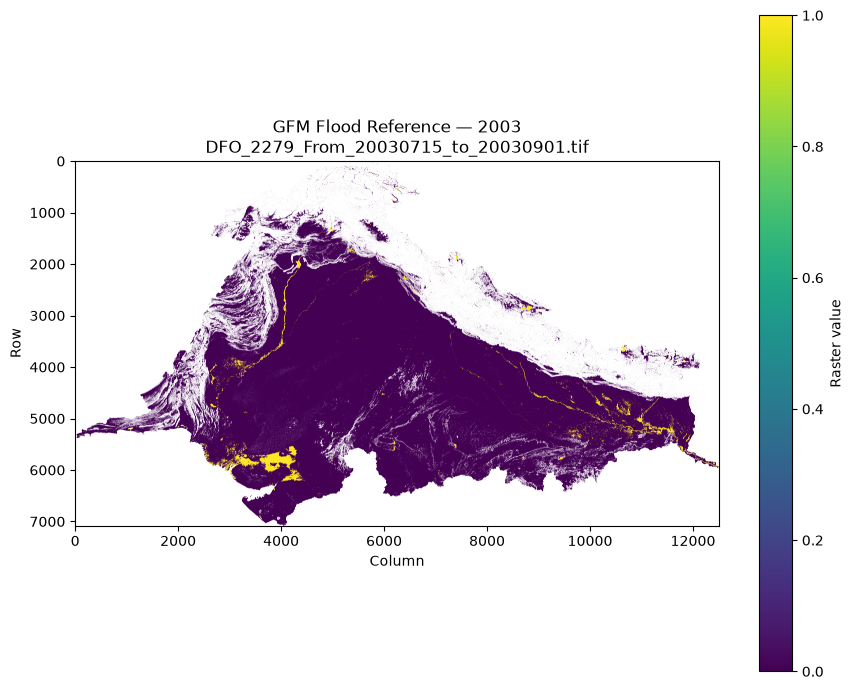

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2003_DFO_2279_From_20030715_to_20030901.png


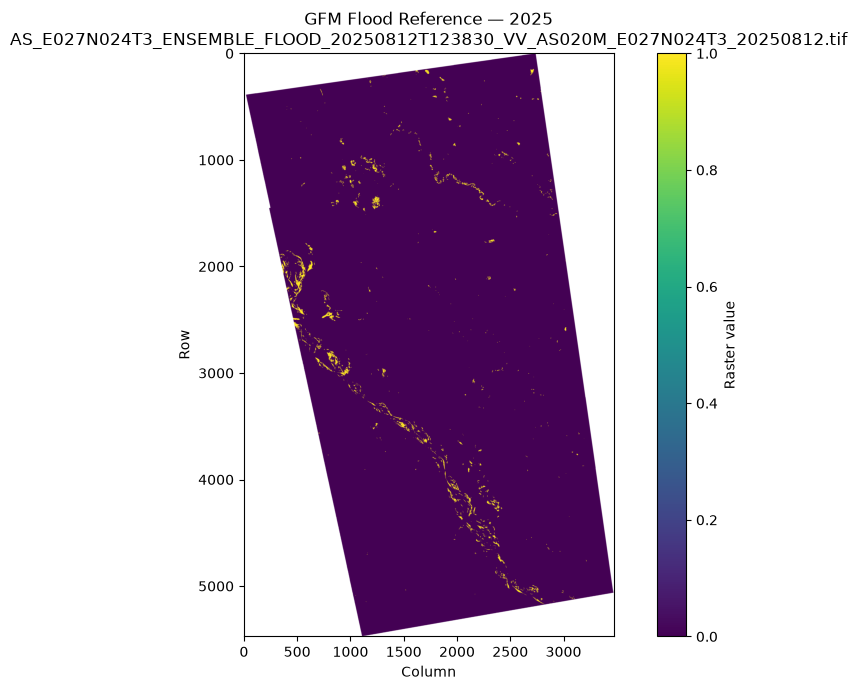

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.png


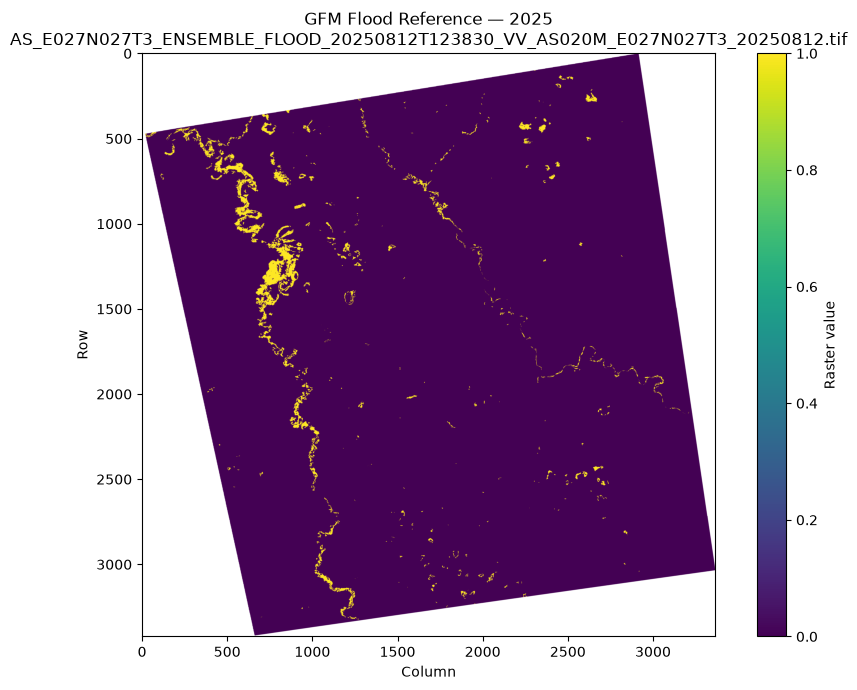

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.png


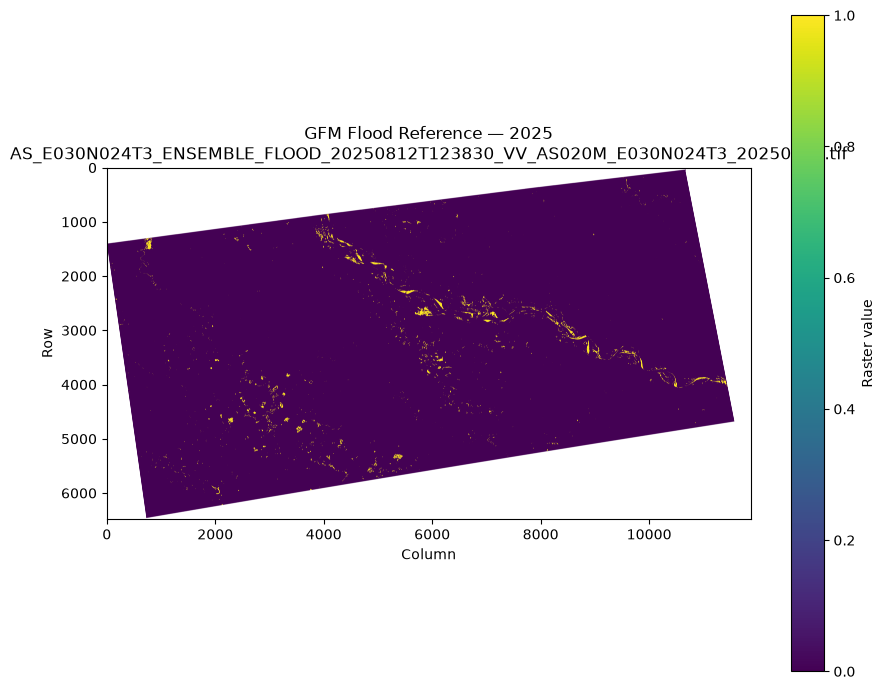

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.png


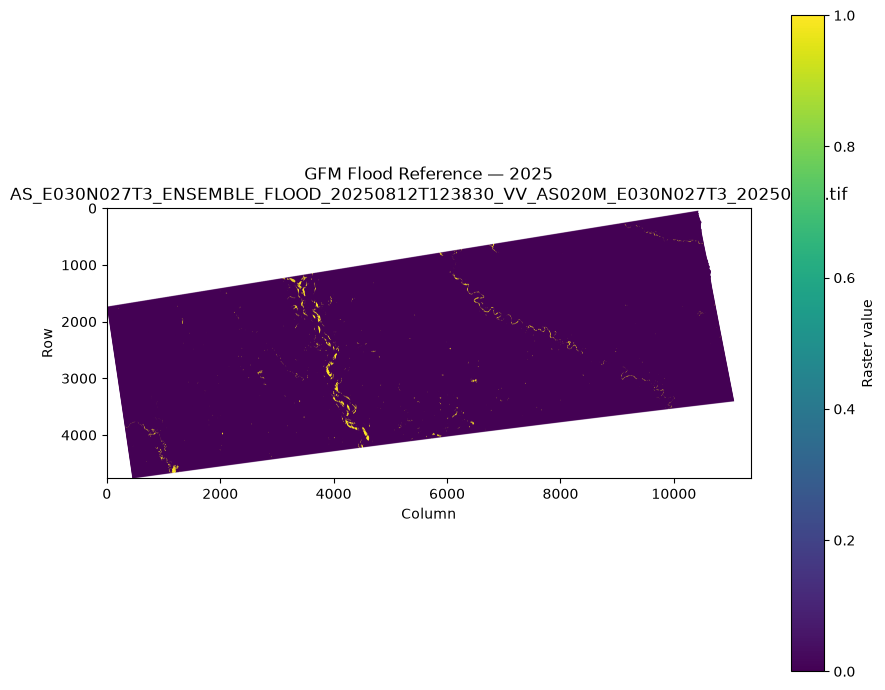

✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\flood_reference_2025_AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.png

STEP 08.2 — FINAL STATUS
✓ Flood-reference directories located
✓ Flood-reference TIFF files discovered
✓ Raster metadata inspected
✓ CRS inspected
✓ Raster dimensions inspected
✓ Spatial resolution inspected
✓ NoData values inspected
✓ Valid and NoData cells counted
✓ Unique raster values inspected
✓ Initial raster visualisations generated
✓ Metadata table saved
✓ Unique-value table saved
✓ Raw flood-reference rasters were NOT modified
✓ No reprojection performed
✓ No resampling performed
✓ No clipping performed
✓ STEP 08.2 COMPLETED


In [5]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.2 — Flood Reference Data Loading & Initial Inspection
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt


# ============================================================
# 1. PROJECT PATHS
# ============================================================

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------
# If PROJECT_ROOT was already defined in previous notebooks,
# this will reuse it.
# Otherwise, set it manually to your project folder.
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path(PROJECT_ROOT)


# ------------------------------------------------------------
# Raw flood-reference directories
# ------------------------------------------------------------

FLOOD_REFERENCE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)


YEAR_DIRECTORIES = {
    2003: FLOOD_REFERENCE_ROOT / "2003",
    2025: FLOOD_REFERENCE_ROOT / "2025",
}


# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_08"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FLOOD-REFERENCE FILE DISCOVERY
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE DATA LOADING")
print("=" * 75)


flood_files = {}


for year, year_dir in YEAR_DIRECTORIES.items():

    print("\n" + "-" * 75)
    print(f"FLOOD REFERENCE FILES — {year}")
    print("-" * 75)

    if not year_dir.exists():
        raise FileNotFoundError(
            f"Flood-reference directory not found:\n{year_dir}"
        )

    tif_files = sorted(
        list(year_dir.glob("*.tif"))
        + list(year_dir.glob("*.tiff"))
    )

    if len(tif_files) == 0:
        raise FileNotFoundError(
            f"No TIFF files found in:\n{year_dir}"
        )

    flood_files[year] = tif_files

    print(f"Directory : {year_dir}")
    print(f"TIFF files: {len(tif_files)}")

    for tif in tif_files:
        print(f"  ✓ {tif.name}")


# ============================================================
# 3. INITIAL RASTER METADATA INSPECTION
# ============================================================

metadata_records = []


for year, tif_files in flood_files.items():

    print("\n" + "=" * 75)
    print(f"INITIAL FLOOD-REFERENCE INSPECTION — {year}")
    print("=" * 75)

    for tif_path in tif_files:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Basic raster metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            count = src.count

            crs = src.crs

            resolution_x = src.res[0]
            resolution_y = src.res[1]

            transform = src.transform
            bounds = src.bounds

            dtype = src.dtypes[0]

            nodata = src.nodata

            driver = src.driver

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            valid_cells = int(
                valid_mask.sum()
            )

            total_cells = int(
                data.size
            )

            nodata_cells = (
                total_cells
                - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values = np.unique(
                    valid_values
                )

                unique_display = (
                    unique_values[:50]
                )

                minimum = float(
                    np.min(valid_values)
                )

                maximum = float(
                    np.max(valid_values)
                )

            else:

                unique_values = np.array([])

                unique_display = []

                minimum = np.nan
                maximum = np.nan

            # ------------------------------------------------
            # Print metadata
            # ------------------------------------------------

            print(f"Driver          : {driver}")
            print(f"CRS             : {crs}")
            print(
                f"Dimensions      : "
                f"{height} × {width}"
            )

            print(
                f"Resolution      : "
                f"{resolution_x} × "
                f"{resolution_y}"
            )

            print(f"Bands           : {count}")

            print(f"Data type       : {dtype}")

            print(f"NoData          : {nodata}")

            print(
                f"Valid cells     : "
                f"{valid_cells:,} / "
                f"{total_cells:,}"
            )

            print(
                f"NoData cells    : "
                f"{nodata_cells:,}"
            )

            print(
                f"Minimum         : "
                f"{minimum}"
            )

            print(
                f"Maximum         : "
                f"{maximum}"
            )

            print(
                "Unique values   : "
                f"{unique_display}"
            )

            print(f"Bounds          : {bounds}")

            print(f"Transform       : {transform}")

            # ------------------------------------------------
            # Record metadata
            # ------------------------------------------------

            metadata_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    count,

                "crs":
                    str(crs),

                "resolution_x":
                    resolution_x,

                "resolution_y":
                    resolution_y,

                "dtype":
                    dtype,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "minimum":
                    minimum,

                "maximum":
                    maximum,

                "unique_value_count":
                    len(unique_values),

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top
            })


# ============================================================
# 4. METADATA SUMMARY TABLE
# ============================================================

metadata_df = pd.DataFrame(
    metadata_records
)


metadata_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_metadata.csv"
)


metadata_df.to_csv(
    metadata_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD-REFERENCE METADATA SUMMARY")
print("=" * 75)

print(
    metadata_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Metadata table saved:\n"
    f"{metadata_output}"
)


# ============================================================
# 5. UNIQUE-VALUE INSPECTION
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VALUE INSPECTION")
print("=" * 75)


value_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            unique_values, counts = np.unique(
                valid_values,
                return_counts=True
            )

            print("\n" + "-" * 75)
            print(f"{year} — {tif_path.name}")
            print("-" * 75)

            for value, count in zip(
                unique_values,
                counts
            ):

                percentage = (
                    count
                    / len(valid_values)
                    * 100
                )

                print(
                    f"Value {value}"
                    f" : {count:,} cells"
                    f" | {percentage:.4f}%"
                )

                value_records.append({

                    "year": year,

                    "file_name":
                        tif_path.name,

                    "value":
                        float(value),

                    "cell_count":
                        int(count),

                    "percentage":
                        float(percentage)
                })


value_df = pd.DataFrame(
    value_records
)


value_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_unique_values.csv"
)


value_df.to_csv(
    value_output,
    index=False
)


print(
    f"\n✓ Unique-value table saved:\n"
    f"{value_output}"
)


# ============================================================
# 6. QUICK VISUAL INSPECTION
# ============================================================
#
# This is ONLY a visual inspection.
#
# No raster is modified.
# No reprojection is performed.
# No resampling is performed.
# No clipping is performed.
#
# For multiple 2025 tiles, each tile is plotted separately.
# ============================================================

print("\n" + "=" * 75)
print("FLOOD-REFERENCE VISUAL INSPECTION")
print("=" * 75)


figure_records = []


for year, tif_files in flood_files.items():

    for tif_path in tif_files:

        with rasterio.open(tif_path) as src:

            data = src.read(1)

            nodata = src.nodata

            if nodata is not None:

                display_data = np.ma.masked_equal(
                    data,
                    nodata
                )

            else:

                display_data = np.ma.masked_invalid(
                    data
                )

            fig, ax = plt.subplots(
                figsize=(9, 7)
            )

            image = ax.imshow(
                display_data
            )

            ax.set_title(
                f"GFM Flood Reference — {year}\n"
                f"{tif_path.name}"
            )

            ax.set_xlabel(
                "Column"
            )

            ax.set_ylabel(
                "Row"
            )

            fig.colorbar(
                image,
                ax=ax,
                label="Raster value"
            )

            plt.tight_layout()

            figure_name = (
                f"flood_reference_"
                f"{year}_"
                f"{tif_path.stem}.png"
            )

            figure_path = (
                FIGURE_DIR
                / figure_name
            )

            fig.savefig(
                figure_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()

            plt.close(fig)

            figure_records.append({

                "year": year,

                "file_name":
                    tif_path.name,

                "figure":
                    str(figure_path)
            })

            print(
                f"✓ Figure saved:\n"
                f"{figure_path}"
            )


# ============================================================
# 7. FINAL STEP 08.2 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.2 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Flood-reference directories located"
)

print(
    "✓ Flood-reference TIFF files discovered"
)

print(
    "✓ Raster metadata inspected"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Raster dimensions inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid and NoData cells counted"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Initial raster visualisations generated"
)

print(
    "✓ Metadata table saved"
)

print(
    "✓ Unique-value table saved"
)

print(
    "✓ Raw flood-reference rasters were NOT modified"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print("=" * 75)
print("✓ STEP 08.2 COMPLETED")
print("=" * 75)

# Step 08.3 — Flood Reference Raster Quality Assurance

## Objective

This step performs quality assurance on the raw flood-reference rasters for
2003, 2014, and 2025 before any spatial transformation or integration with
the predictor datasets.

The purpose is to verify that the downloaded flood-reference datasets have
valid and interpretable raster structures and that the 2025 multi-tile GFM
products are internally consistent.

## Quality Checks

The following properties are assessed:

- Coordinate reference system (CRS)
- Raster dimensions
- Spatial resolution
- Number of bands
- Data type
- NoData definition
- Valid-cell counts
- Raster spatial bounds
- Unique raster values
- Flood/non-flood value structure
- Within-year consistency of 2025 GFM tiles

## Important methodological rule

The raw flood-reference rasters are treated as source/reference data.

Therefore:

- No raster values are modified.
- No missing values are imputed.
- No clipping is performed.
- No reprojection is performed.
- No resampling is performed.
- No mosaicking is performed.
- No flood class is manually recoded at this stage.

Any required spatial harmonisation will be performed in a subsequent step.

## Expected Outcome

The step should establish whether each flood-reference raster is suitable
for subsequent spatial harmonisation and conversion into the flood target
variable required for machine-learning modelling.

**Step 08.3 does not train any machine-learning model.**

In [6]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.3 — Flood Reference Raster Quality Assurance
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY FLOOD FILES FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE RASTER QA")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.3."
    )


# ============================================================
# 2. EXPECTED FLOOD-REFERENCE YEARS
# ============================================================

EXPECTED_YEARS = [2003, 2025]

for year in EXPECTED_YEARS:

    if year not in flood_files:
        raise ValueError(
            f"Flood-reference files for {year} were not loaded."
        )

    if len(flood_files[year]) == 0:
        raise ValueError(
            f"No flood-reference TIFFs found for {year}."
        )


print("\n✓ Flood-reference years detected:")
print("  2003")
print("  2025")


# ============================================================
# 3. RASTER-LEVEL QA
# ============================================================

qa_records = []


for year in EXPECTED_YEARS:

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            # ------------------------------------------------
            # Metadata
            # ------------------------------------------------

            width = src.width
            height = src.height
            band_count = src.count

            crs = src.crs
            dtype = src.dtypes[0]
            nodata = src.nodata

            res_x = src.res[0]
            res_y = src.res[1]

            bounds = src.bounds
            transform = src.transform

            # ------------------------------------------------
            # Read first band
            # ------------------------------------------------

            data = src.read(1)

            # ------------------------------------------------
            # Valid-data mask
            # ------------------------------------------------

            if nodata is None:

                valid_mask = np.isfinite(data)

            else:

                valid_mask = (
                    np.isfinite(data)
                    & (data != nodata)
                )

            valid_values = data[valid_mask]

            total_cells = data.size
            valid_cells = int(valid_mask.sum())
            nodata_cells = (
                total_cells - valid_cells
            )

            # ------------------------------------------------
            # Unique values
            # ------------------------------------------------

            if valid_cells > 0:

                unique_values, counts = np.unique(
                    valid_values,
                    return_counts=True
                )

            else:

                unique_values = np.array([])
                counts = np.array([])

            # ------------------------------------------------
            # Flood value detection
            #
            # We DO NOT recode anything.
            # We only report whether value 1 exists.
            # ------------------------------------------------

            contains_zero = (
                0 in unique_values
            )

            contains_one = (
                1 in unique_values
            )

            contains_other_values = any(
                value not in [0, 1]
                for value in unique_values
            )

            # ------------------------------------------------
            # Flood-cell count if binary 0/1
            # ------------------------------------------------

            if contains_one:

                flood_cells = int(
                    np.sum(valid_values == 1)
                )

            else:

                flood_cells = 0

            if valid_cells > 0:

                flood_percentage = (
                    flood_cells
                    / valid_cells
                    * 100
                )

            else:

                flood_percentage = np.nan

            # ------------------------------------------------
            # QA flags
            # ------------------------------------------------

            dimensions_valid = (
                width > 0
                and height > 0
            )

            band_valid = (
                band_count == 1
            )

            resolution_valid = (
                res_x > 0
                and res_y > 0
            )

            valid_data_exists = (
                valid_cells > 0
            )

            binary_values = (
                valid_cells > 0
                and all(
                    value in [0, 1]
                    for value in unique_values
                )
            )

            # ------------------------------------------------
            # Print results
            # ------------------------------------------------

            print(
                f"CRS              : {crs}"
            )

            print(
                f"Dimensions        : "
                f"{height} × {width}"
            )

            print(
                f"Bands             : {band_count}"
            )

            print(
                f"Data type         : {dtype}"
            )

            print(
                f"Resolution        : "
                f"{res_x} × {res_y}"
            )

            print(
                f"NoData            : {nodata}"
            )

            print(
                f"Total cells       : "
                f"{total_cells:,}"
            )

            print(
                f"Valid cells       : "
                f"{valid_cells:,}"
            )

            print(
                f"NoData cells      : "
                f"{nodata_cells:,}"
            )

            print(
                f"Unique values     : "
                f"{unique_values}"
            )

            print(
                f"Contains 0        : "
                f"{contains_zero}"
            )

            print(
                f"Contains 1        : "
                f"{contains_one}"
            )

            print(
                f"Contains other    : "
                f"{contains_other_values}"
            )

            print(
                f"Binary 0/1        : "
                f"{binary_values}"
            )

            print(
                f"Flood cells (1)   : "
                f"{flood_cells:,}"
            )

            print(
                f"Flood share       : "
                f"{flood_percentage:.4f}%"
            )

            print(
                f"Bounds            : "
                f"{bounds}"
            )

            # ------------------------------------------------
            # Store QA record
            # ------------------------------------------------

            qa_records.append({

                "year":
                    year,

                "file_name":
                    tif_path.name,

                "width":
                    width,

                "height":
                    height,

                "bands":
                    band_count,

                "crs":
                    str(crs),

                "dtype":
                    dtype,

                "resolution_x":
                    res_x,

                "resolution_y":
                    res_y,

                "nodata":
                    nodata,

                "total_cells":
                    total_cells,

                "valid_cells":
                    valid_cells,

                "nodata_cells":
                    nodata_cells,

                "unique_value_count":
                    len(unique_values),

                "unique_values":
                    ",".join(
                        str(v)
                        for v in unique_values
                    ),

                "contains_zero":
                    contains_zero,

                "contains_one":
                    contains_one,

                "contains_other_values":
                    contains_other_values,

                "binary_0_1":
                    binary_values,

                "flood_cells_value_1":
                    flood_cells,

                "flood_percentage":
                    flood_percentage,

                "bounds_left":
                    bounds.left,

                "bounds_bottom":
                    bounds.bottom,

                "bounds_right":
                    bounds.right,

                "bounds_top":
                    bounds.top,

                "dimensions_valid":
                    dimensions_valid,

                "single_band":
                    band_valid,

                "resolution_valid":
                    resolution_valid,

                "valid_data_exists":
                    valid_data_exists
            })


# ============================================================
# 4. QA TABLE
# ============================================================

qa_df = pd.DataFrame(
    qa_records
)


qa_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_raster_QA.csv"
)


qa_df.to_csv(
    qa_output,
    index=False
)


print("\n" + "=" * 75)
print("FLOOD REFERENCE RASTER QA SUMMARY")
print("=" * 75)

print(
    qa_df[
        [
            "year",
            "file_name",
            "crs",
            "width",
            "height",
            "bands",
            "resolution_x",
            "resolution_y",
            "dtype",
            "nodata",
            "unique_values",
            "binary_0_1",
            "flood_cells_value_1",
            "flood_percentage"
        ]
    ].to_string(index=False)
)

print(
    f"\n✓ QA table saved:\n"
    f"{qa_output}"
)


# ============================================================
# 5. WITHIN-YEAR CONSISTENCY CHECK — 2025
# ============================================================
#
# 2025 contains multiple GFM tiles.
#
# We check whether all tiles share:
# - CRS
# - resolution
# - band count
# - data type
#
# We do NOT require identical dimensions or bounds because
# different tiles naturally cover different spatial areas.
# ============================================================

print("\n" + "=" * 75)
print("2025 GFM TILE CONSISTENCY CHECK")
print("=" * 75)


gfm_2025 = qa_df[
    qa_df["year"] == 2025
].copy()


if len(gfm_2025) == 0:

    raise ValueError(
        "No 2025 flood-reference tiles found."
    )


crs_consistent = (
    gfm_2025["crs"].nunique() == 1
)

resolution_x_consistent = (
    gfm_2025["resolution_x"].nunique() == 1
)

resolution_y_consistent = (
    gfm_2025["resolution_y"].nunique() == 1
)

band_consistent = (
    gfm_2025["bands"].nunique() == 1
)

dtype_consistent = (
    gfm_2025["dtype"].nunique() == 1
)


print(
    f"CRS consistency        : "
    f"{crs_consistent}"
)

print(
    f"X-resolution consistency: "
    f"{resolution_x_consistent}"
)

print(
    f"Y-resolution consistency: "
    f"{resolution_y_consistent}"
)

print(
    f"Band-count consistency  : "
    f"{band_consistent}"
)

print(
    f"Data-type consistency   : "
    f"{dtype_consistent}"
)


gfm_consistent = all([
    crs_consistent,
    resolution_x_consistent,
    resolution_y_consistent,
    band_consistent,
    dtype_consistent
])


if gfm_consistent:

    print(
        "\n✓ 2025 GFM tiles are internally "
        "consistent in raster structure."
    )

else:

    print(
        "\n⚠ 2025 GFM tiles require further "
        "investigation before mosaicking."
    )


# ============================================================
# 6. VALUE-STRUCTURE QA
# ============================================================

print("\n" + "=" * 75)
print("FLOOD VALUE STRUCTURE QA")
print("=" * 75)


all_binary = qa_df["binary_0_1"].all()


print(
    f"All rasters binary 0/1 : "
    f"{all_binary}"
)


if all_binary:

    print(
        "✓ All valid raster values are "
        "restricted to 0 and 1."
    )

else:

    print(
        "⚠ One or more rasters contain "
        "values other than 0 and 1."
    )

    print(
        "Do NOT recode them yet."
    )


# ============================================================
# 7. FINAL QA STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.3 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Raw flood-reference rasters inspected"
)

print(
    "✓ Raster dimensions verified"
)

print(
    "✓ Band counts verified"
)

print(
    "✓ CRS inspected"
)

print(
    "✓ Spatial resolution inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Spatial bounds inspected"
)

print(
    "✓ Unique raster values inspected"
)

print(
    "✓ Flood-value presence assessed"
)

print(
    "✓ Flood-cell counts calculated"
)

print(
    "✓ Flood percentage calculated"
)

print(
    "✓ 2025 GFM tile consistency assessed"
)

print(
    "✓ QA results saved as CSV"
)

print(
    "✓ No raster was modified"
)

print(
    "✓ No values were recoded"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print("✓ STEP 08.3 COMPLETED")
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE RASTER QA

✓ Flood-reference years detected:
  2003
  2025

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
CRS              : EPSG:4326
Dimensions        : 7080 × 12506
Bands             : 5
Data type         : float32
Resolution        : 0.002245788210298804 × 0.002245788210298804
NoData            : None
Total cells       : 88,542,480
Valid cells       : 29,640,663
NoData cells      : 58,901,817
Unique values     : [0. 1.]
Contains 0        : True
Contains 1        : True
Contains other    : False
Binary 0/1        : True
Flood cells (1)   : 764,407
Flood share       : 2.5789%
Bounds            : BoundingBox(left=61.664852678384555, bottom=21.19799491701041, right=89.7506800363814, top=37.09817544592594)

YEAR — 2025

---------------------------------------------------------------------------

# Step 08.4 — Flood Reference Band Identification & Semantic QA

## Objective

The flood-reference datasets obtained from different sources may contain
different numbers of raster bands and different data structures.

The 2003 and 2014 flood-reference rasters contain multiple bands, whereas
the 2025 GFM products contain a single band.

Before constructing the flood target variable, this step identifies and
documents the semantic meaning and numerical structure of each raster band.

## Checks Performed

For every flood-reference TIFF:

- Number of bands
- Band descriptions
- Band metadata/tags
- Data type
- NoData value
- Minimum and maximum values
- Unique values
- Valid-cell count
- Binary/non-binary structure

## Important methodological rule

No assumption is made that Band 1 represents flood extent.

The flood-reference band will only be selected after its metadata and
numerical structure have been inspected.

No raster values are modified in this step.

No reprojection, resampling, clipping, mosaicking, or recoding is performed.

## Expected Outcome

The step will establish:

1. The meaning of each available raster band.
2. Which band should be used as the flood-reference variable for 2003.
3. Which band should be used for 2014.
4. The structure of the single-band 2025 GFM products.

This information is required before spatial harmonisation and construction
of the machine-learning target variable.

In [7]:
# ============================================================
# NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL
# Step 08.4 — Flood Reference Band Identification & Semantic QA
# ============================================================

import numpy as np
import pandas as pd
import rasterio


# ============================================================
# 1. VERIFY INPUTS FROM STEP 08.2
# ============================================================

print("\n" + "=" * 75)
print("NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION")
print("=" * 75)

if "flood_files" not in globals():
    raise RuntimeError(
        "flood_files was not found. "
        "Run Step 08.2 before Step 08.4."
    )


# ============================================================
# 2. BAND-LEVEL INSPECTION
# ============================================================

band_records = []


for year in sorted(flood_files.keys()):

    print("\n" + "=" * 75)
    print(f"YEAR — {year}")
    print("=" * 75)

    for tif_path in flood_files[year]:

        print("\n" + "-" * 75)
        print(f"FILE — {tif_path.name}")
        print("-" * 75)

        with rasterio.open(tif_path) as src:

            print(f"Number of bands : {src.count}")
            print(f"CRS             : {src.crs}")
            print(f"Data types      : {src.dtypes}")
            print(f"NoData          : {src.nodatavals}")

            # ------------------------------------------------
            # Dataset-level tags
            # ------------------------------------------------

            dataset_tags = src.tags()

            if dataset_tags:

                print("\nDataset tags:")

                for key, value in dataset_tags.items():

                    print(
                        f"  {key}: {value}"
                    )

            else:

                print(
                    "\nDataset tags: None"
                )

            # ------------------------------------------------
            # Inspect every band
            # ------------------------------------------------

            for band_number in range(
                1,
                src.count + 1
            ):

                print("\n" + "-" * 60)
                print(
                    f"BAND {band_number}"
                )
                print("-" * 60)

                # --------------------------------------------
                # Band description
                # --------------------------------------------

                description = (
                    src.descriptions[
                        band_number - 1
                    ]
                )

                print(
                    f"Description : "
                    f"{description}"
                )

                # --------------------------------------------
                # Band-specific tags
                # --------------------------------------------

                band_tags = src.tags(
                    band_number
                )

                if band_tags:

                    print("Band tags:")

                    for key, value in band_tags.items():

                        print(
                            f"  {key}: {value}"
                        )

                else:

                    print(
                        "Band tags: None"
                    )

                # --------------------------------------------
                # Read band
                # --------------------------------------------

                data = src.read(
                    band_number
                )

                nodata = src.nodatavals[
                    band_number - 1
                ]

                # --------------------------------------------
                # Valid mask
                # --------------------------------------------

                if nodata is None:

                    valid_mask = (
                        np.isfinite(data)
                    )

                else:

                    valid_mask = (
                        np.isfinite(data)
                        & (data != nodata)
                    )

                valid_values = data[
                    valid_mask
                ]

                valid_cells = int(
                    valid_mask.sum()
                )

                total_cells = int(
                    data.size
                )

                # --------------------------------------------
                # Statistics
                # --------------------------------------------

                if valid_cells > 0:

                    minimum = float(
                        np.min(valid_values)
                    )

                    maximum = float(
                        np.max(valid_values)
                    )

                    mean = float(
                        np.mean(valid_values)
                    )

                    unique_values = np.unique(
                        valid_values
                    )

                else:

                    minimum = np.nan
                    maximum = np.nan
                    mean = np.nan

                    unique_values = np.array([])

                # --------------------------------------------
                # Determine whether binary
                # --------------------------------------------

                is_binary_01 = (
                    valid_cells > 0
                    and np.all(
                        np.isin(
                            unique_values,
                            [0, 1]
                        )
                    )
                )

                # --------------------------------------------
                # Count 0 and 1
                # --------------------------------------------

                zero_count = int(
                    np.sum(
                        valid_values == 0
                    )
                )

                one_count = int(
                    np.sum(
                        valid_values == 1
                    )
                )

                # --------------------------------------------
                # Print statistics
                # --------------------------------------------

                print(
                    f"Data type   : "
                    f"{src.dtypes[band_number - 1]}"
                )

                print(
                    f"NoData      : "
                    f"{nodata}"
                )

                print(
                    f"Total cells : "
                    f"{total_cells:,}"
                )

                print(
                    f"Valid cells : "
                    f"{valid_cells:,}"
                )

                print(
                    f"Minimum     : "
                    f"{minimum}"
                )

                print(
                    f"Maximum     : "
                    f"{maximum}"
                )

                print(
                    f"Mean        : "
                    f"{mean}"
                )

                print(
                    f"Unique count: "
                    f"{len(unique_values)}"
                )

                print(
                    f"Unique values: "
                    f"{unique_values[:50]}"
                )

                print(
                    f"Zero cells  : "
                    f"{zero_count:,}"
                )

                print(
                    f"One cells   : "
                    f"{one_count:,}"
                )

                print(
                    f"Binary 0/1  : "
                    f"{is_binary_01}"
                )

                # --------------------------------------------
                # Store record
                # --------------------------------------------

                band_records.append({

                    "year":
                        year,

                    "file_name":
                        tif_path.name,

                    "band":
                        band_number,

                    "description":
                        description,

                    "dtype":
                        src.dtypes[
                            band_number - 1
                        ],

                    "nodata":
                        nodata,

                    "total_cells":
                        total_cells,

                    "valid_cells":
                        valid_cells,

                    "minimum":
                        minimum,

                    "maximum":
                        maximum,

                    "mean":
                        mean,

                    "unique_value_count":
                        len(unique_values),

                    "unique_values":
                        ",".join(
                            str(v)
                            for v in unique_values[:100]
                        ),

                    "zero_cells":
                        zero_count,

                    "one_cells":
                        one_count,

                    "binary_0_1":
                        is_binary_01
                })


# ============================================================
# 3. SAVE BAND INVENTORY
# ============================================================

band_df = pd.DataFrame(
    band_records
)


band_output = (
    TABLE_DIR
    / "notebook_08_flood_reference_band_inventory.csv"
)


band_df.to_csv(
    band_output,
    index=False
)


print("\n" + "=" * 75)
print("BAND INVENTORY")
print("=" * 75)

print(
    band_df.to_string(
        index=False
    )
)

print(
    f"\n✓ Band inventory saved:\n"
    f"{band_output}"
)


# ============================================================
# 4. SUMMARY BY YEAR
# ============================================================

print("\n" + "=" * 75)
print("BAND STRUCTURE SUMMARY")
print("=" * 75)


for year in sorted(
    band_df["year"].unique()
):

    year_df = band_df[
        band_df["year"] == year
    ]

    print("\n" + "-" * 75)
    print(f"{year}")
    print("-" * 75)

    print(
        f"Files : "
        f"{year_df['file_name'].nunique()}"
    )

    print(
        f"Bands : "
        f"{year_df['band'].nunique()}"
    )

    print(
        year_df[
            [
                "file_name",
                "band",
                "description",
                "dtype",
                "minimum",
                "maximum",
                "unique_value_count",
                "binary_0_1"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 5. CHECK FOR BAND DESCRIPTIONS
# ============================================================

print("\n" + "=" * 75)
print("BAND DESCRIPTION CHECK")
print("=" * 75)


missing_descriptions = band_df[
    band_df["description"].isna()
    | (
        band_df["description"]
        .astype(str)
        .str.strip()
        .isin(
            ["", "None"]
        )
    )
]


if len(missing_descriptions) == 0:

    print(
        "✓ All bands have descriptions."
    )

else:

    print(
        f"⚠ {len(missing_descriptions)} "
        "bands have no explicit description."
    )

    print(
        missing_descriptions[
            [
                "year",
                "file_name",
                "band"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 6. BINARY BAND SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("BINARY BAND SUMMARY")
print("=" * 75)


binary_df = band_df[
    band_df["binary_0_1"] == True
].copy()


if len(binary_df) > 0:

    print(
        binary_df[
            [
                "year",
                "file_name",
                "band",
                "description",
                "zero_cells",
                "one_cells"
            ]
        ].to_string(
            index=False
        )
    )

else:

    print(
        "No binary 0/1 bands detected."
    )


# ============================================================
# 7. IMPORTANT: DO NOT SELECT FLOOD BAND AUTOMATICALLY
# ============================================================

print("\n" + "=" * 75)
print("FLOOD BAND SELECTION")
print("=" * 75)

print(
    "⚠ Flood-reference bands have NOT been selected automatically."
)

print(
    "⚠ Band 1 is NOT assumed to be the flood mask."
)

print(
    "The band meaning must be confirmed from the "
    "source-product metadata/documentation before "
    "constructing the flood target."
)


# ============================================================
# 8. FINAL STEP 08.4 STATUS
# ============================================================

print("\n" + "=" * 75)
print("STEP 08.4 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Every flood-reference band inspected"
)

print(
    "✓ Band descriptions inspected"
)

print(
    "✓ Dataset-level metadata inspected"
)

print(
    "✓ Band-level metadata inspected"
)

print(
    "✓ Data types inspected"
)

print(
    "✓ NoData values inspected"
)

print(
    "✓ Valid-cell counts calculated"
)

print(
    "✓ Minimum and maximum values calculated"
)

print(
    "✓ Unique values inspected"
)

print(
    "✓ Binary 0/1 structure assessed"
)

print(
    "✓ Band inventory saved"
)

print(
    "✓ No raster values modified"
)

print(
    "✓ No band was automatically selected"
)

print(
    "✓ No reprojection performed"
)

print(
    "✓ No resampling performed"
)

print(
    "✓ No clipping performed"
)

print(
    "✓ No mosaicking performed"
)

print("=" * 75)
print(
    "✓ STEP 08.4 COMPLETED — "
    "BAND INVENTORY READY FOR INTERPRETATION"
)
print("=" * 75)


NOTEBOOK 08 — FLOOD REFERENCE BAND IDENTIFICATION

YEAR — 2003

---------------------------------------------------------------------------
FILE — DFO_2279_From_20030715_to_20030901.tif
---------------------------------------------------------------------------
Number of bands : 5
CRS             : EPSG:4326
Data types      : ('float32', 'float32', 'float32', 'float32', 'float32')
NoData          : (None, None, None, None, None)

Dataset tags:
  AREA_OR_POINT: Area

------------------------------------------------------------
BAND 1
------------------------------------------------------------
Description : flooded
Band tags: None
Data type   : float32
NoData      : None
Total cells : 88,542,480
Valid cells : 29,640,663
Minimum     : 0.0
Maximum     : 1.0
Mean        : 0.025789132341742516
Unique count: 2
Unique values: [0. 1.]
Zero cells  : 28,876,256
One cells   : 764,407
Binary 0/1  : True

------------------------------------------------------------
BAND 2
-------------------------

## Step 08.5 — Flood Reference Spatial Harmonisation

The observed flood-reference datasets for 2003 and 2025 originate from different raster products and therefore differ in coordinate reference system, spatial resolution, extent, and grid alignment. To make them compatible with the predictor datasets, both flood references are transformed to a common modelling grid.

The target grid uses EPSG:32644 and a 250 m × 250 m spatial resolution, consistent with the harmonised predictor datasets. The common grid is constructed from the full study-area extent using an outward rounding rule so that the complete study area is covered.

Flood labels are aggregated using a maximum-value rule rather than continuous interpolation. Thus, a target cell is labelled as flooded when at least one valid source flood pixel within that cell is classified as flooded. Source NoData is kept separate from confirmed non-flood observations.

The resulting 2003 and 2025 flood-reference rasters therefore have identical CRS, resolution, extent, dimensions, and pixel alignment while retaining the binary flood/non-flood structure.

In [8]:
# ============================================================
# 08.5 — FLOOD REFERENCE SPATIAL HARMONISATION
# PATH SETUP
# ============================================================

from pathlib import Path


# ------------------------------------------------------------
# Detect project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR


# ------------------------------------------------------------
# Input / output paths
# ------------------------------------------------------------

FLOOD_REFERENCE_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "flood_reference"
)

FLOOD_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_08"
    / "flood_reference"
)

FLOOD_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


TABLE_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "notebook_08"
)

TABLE_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 75)
print("PROJECT PATH CHECK")
print("=" * 75)

print("Current directory      :", CURRENT_DIR)
print("Detected project root  :", PROJECT_ROOT)
print("Flood-reference input  :", FLOOD_REFERENCE_ROOT)
print("Flood-reference output :", FLOOD_OUTPUT_ROOT)
print("Table output            :", TABLE_OUTPUT_ROOT)

PROJECT PATH CHECK
Current directory      : D:\Projects\GeoAI-Flood-Susceptibility\notebooks
Detected project root  : D:\Projects\GeoAI-Flood-Susceptibility
Flood-reference input  : D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference
Flood-reference output : D:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_08\flood_reference
Table output            : D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\notebook_08


## 2014 Flood Reference Assessment and Exclusion

An intermediate 2014 flood-reference dataset was investigated to support the temporal analysis. Available DFO and India Flood Inventory (IFI) records were evaluated, followed by Landsat 8-based pre-flood and flood-period spectral change analysis. However, the evaluated sources did not provide sufficiently reliable spatial evidence to construct a defensible 2014 flood-reference mask. The Landsat-derived candidate inundation areas showed substantial fragmentation, weak spatial association with the Gomti River corridor, and sensitivity near cloud/shadow boundaries. Therefore, 2014 was excluded from supervised flood-susceptibility model training. The 2014 investigation outputs are retained as documentation of the data-screening process.

In [9]:
# ============================================================
# FINAL MODELING YEARS
# ============================================================

MODELING_YEARS = [2003, 2025]

print(
    "Flood-reference modeling years:",
    MODELING_YEARS
)

Flood-reference modeling years: [2003, 2025]


In [10]:
# ============================================================
# FLOOD-REFERENCE INPUT FILES
# ============================================================

flood_reference_files = {

    2003: [
        FLOOD_REFERENCE_ROOT
        / "2003"
        / "DFO_2279_From_20030715_to_20030901.tif"
    ],

    2025: [
        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif",

        FLOOD_REFERENCE_ROOT
        / "2025"
        / "AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif"
    ]
}


print("=" * 75)
print("INPUT FLOOD-REFERENCE FILE CHECK")
print("=" * 75)

for year, files in flood_reference_files.items():

    print(f"\nYEAR — {year}")

    for path in files:

        print(path)

        if path.exists():
            print("  ✓ File exists")
        else:
            print("  ✗ FILE NOT FOUND")

INPUT FLOOD-REFERENCE FILE CHECK

YEAR — 2003
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003\DFO_2279_From_20030715_to_20030901.tif
  ✓ File exists

YEAR — 2025
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  ✓ File exists
D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2025\AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif
  ✓ File exists


In [11]:
# ============================================================
# COMMON 250 m MODELLING GRID
# ============================================================
from rasterio.transform import from_origin
import geopandas as gpd 
TARGET_CRS = "EPSG:32644"
TARGET_RESOLUTION = 250.0


# ------------------------------------------------------------
# Reproject study area to target CRS
# ------------------------------------------------------------
study_area = PROJECT_ROOT/ "data" / "processed"/ "notebook_01"/ "Lucknow_Search_Area_20km.gpkg"
study_area = gpd.read_file(study_area)
study_area_utm = study_area.set_crs(TARGET_CRS)


# ------------------------------------------------------------
# Full study-area bounds
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = (
    study_area_utm.total_bounds
)


# ------------------------------------------------------------
# Outward rounding
#
# floor() expands the grid outward on the left/bottom.
# ceil() expands the grid outward on the right/top.
# ------------------------------------------------------------

grid_xmin = (
    np.floor(xmin / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_ymin = (
    np.floor(ymin / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_xmax = (
    np.ceil(xmax / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)

grid_ymax = (
    np.ceil(ymax / TARGET_RESOLUTION)
    * TARGET_RESOLUTION
)


# ------------------------------------------------------------
# Dimensions
# ------------------------------------------------------------

grid_width = int(
    round(
        (grid_xmax - grid_xmin)
        / TARGET_RESOLUTION
    )
)

grid_height = int(
    round(
        (grid_ymax - grid_ymin)
        / TARGET_RESOLUTION
    )
)


# ------------------------------------------------------------
# Transform
# ------------------------------------------------------------

grid_transform = from_origin(
    grid_xmin,
    grid_ymax,
    TARGET_RESOLUTION,
    TARGET_RESOLUTION
)


print("=" * 75)
print("COMMON MODELLING GRID")
print("=" * 75)

print(f"CRS              : {TARGET_CRS}")
print(
    f"Resolution       : "
    f"{TARGET_RESOLUTION:.2f} × "
    f"{TARGET_RESOLUTION:.2f} m"
)

print(f"Width            : {grid_width}")
print(f"Height           : {grid_height}")
print(
    f"Total cells      : "
    f"{grid_width * grid_height:,}"
)

print(f"Left             : {grid_xmin:.2f}")
print(f"Bottom           : {grid_ymin:.2f}")
print(f"Right            : {grid_xmax:.2f}")
print(f"Top              : {grid_ymax:.2f}")

print("\nStudy-area bounds:")
print(
    f"Left             : {xmin:.2f}"
)
print(
    f"Bottom           : {ymin:.2f}"
)
print(
    f"Right            : {xmax:.2f}"
)
print(
    f"Top              : {ymax:.2f}"
)

COMMON MODELLING GRID
CRS              : EPSG:32644
Resolution       : 250.00 × 250.00 m
Width            : 252
Height           : 244
Total cells      : 61,488
Left             : 463250.00
Bottom           : 2938000.00
Right            : 526250.00
Top              : 2999000.00

Study-area bounds:
Left             : 463358.58
Bottom           : 2938218.33
Right            : 526062.36
Top              : 2998994.25


In [12]:
# ============================================================
# VERIFY STUDY-AREA COVERAGE
# ============================================================

grid_right_covers_study = (
    grid_xmax >= xmax
)

grid_left_covers_study = (
    grid_xmin <= xmin
)

grid_top_covers_study = (
    grid_ymax >= ymax
)

grid_bottom_covers_study = (
    grid_ymin <= ymin
)


print("=" * 75)
print("COMMON GRID COVERAGE CHECK")
print("=" * 75)

print(
    "Left coverage   :",
    grid_left_covers_study
)

print(
    "Right coverage  :",
    grid_right_covers_study
)

print(
    "Bottom coverage :",
    grid_bottom_covers_study
)

print(
    "Top coverage    :",
    grid_top_covers_study
)


assert grid_left_covers_study
assert grid_right_covers_study
assert grid_bottom_covers_study
assert grid_top_covers_study

print(
    "\n✓ Common grid fully covers "
    "the study-area extent."
)

COMMON GRID COVERAGE CHECK
Left coverage   : True
Right coverage  : True
Bottom coverage : True
Top coverage    : True

✓ Common grid fully covers the study-area extent.


In [13]:
# ============================================================
# STUDY-AREA MASK ON COMMON GRID
# ============================================================
from rasterio.features import rasterize
study_area_mask = rasterize(
    [
        (geom, 1)
        for geom in study_area_utm.geometry
    ],
    out_shape=(
        grid_height,
        grid_width
    ),
    transform=grid_transform,
    fill=0,
    dtype="uint8",
    all_touched=False
)


print("=" * 75)
print("STUDY-AREA MASK")
print("=" * 75)

print(
    "Grid cells inside study area:",
    np.count_nonzero(study_area_mask)
)

print(
    "Grid cells outside study area:",
    np.count_nonzero(
        study_area_mask == 0
    )
)

STUDY-AREA MASK
Grid cells inside study area: 47730
Grid cells outside study area: 13758


In [14]:
# ============================================================
# FUNCTION — HARMONISE A SINGLE BINARY FLOOD RASTER
# ============================================================

def harmonize_binary_flood_raster(
    source_path,
    target_crs,
    target_transform,
    target_shape
):
    """
    Reproject a binary flood raster to the common grid.

    Flood presence is preserved using maximum aggregation.
    Source NoData is kept separate from confirmed non-flood.
    """

    with rasterio.open(source_path) as src:

        source = src.read(1).astype(np.float32)

        source_crs = src.crs
        source_transform = src.transform
        source_nodata = src.nodata

        # ----------------------------------------------------
        # Source valid mask
        # ----------------------------------------------------

        if source_nodata is not None:

            source_valid = (
                source != source_nodata
            )

        else:

            source_valid = (
                np.isfinite(source)
            )

        # ----------------------------------------------------
        # Binary flood mask
        # ----------------------------------------------------

        source_flood = np.zeros(
            source.shape,
            dtype=np.uint8
        )

        source_flood[
            source_valid
            & (source > 0)
        ] = 1

        # ----------------------------------------------------
        # Reproject flood presence
        #
        # Maximum preserves flood presence.
        # ----------------------------------------------------

        flood_target = np.zeros(
            target_shape,
            dtype=np.uint8
        )

        reproject(
            source=source_flood,
            destination=flood_target,
            src_transform=source_transform,
            src_crs=source_crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.max,
            src_nodata=0,
            dst_nodata=0
        )

        # ----------------------------------------------------
        # Reproject source validity separately
        # ----------------------------------------------------

        valid_target = np.zeros(
            target_shape,
            dtype=np.uint8
        )

        reproject(
            source=source_valid.astype(np.uint8),
            destination=valid_target,
            src_transform=source_transform,
            src_crs=source_crs,
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.max,
            src_nodata=0,
            dst_nodata=0
        )

        valid_target = (
            valid_target > 0
        )

        # ----------------------------------------------------
        # Construct final target
        #
        # 0 = confirmed valid non-flood
        # 1 = flood
        # 255 = NoData
        # ----------------------------------------------------

        target = np.full(
            target_shape,
            255,
            dtype=np.uint8
        )

        target[
            valid_target
        ] = flood_target[
            valid_target
        ]

        return (
            target,
            source_valid,
            source_flood
        )

## Step 08.5.8 — 2003 DFO Source-Band Inspection

Before spatial harmonisation, the 2003 DFO flood-reference raster is inspected to identify the appropriate flood-information band and distinguish flood, non-flood, and NoData values. This prevents an incorrect band or invalid source values from being propagated into the common 250 m modelling grid.

No source raster is modified during this inspection.

In [15]:
# ============================================================
# 08.5.8 — 2003 DFO SOURCE-BAND INSPECTION
# ============================================================

dfo_2003_path = flood_reference_files[2003][0]

print("=" * 75)
print("2003 DFO SOURCE-BAND INSPECTION")
print("=" * 75)

with rasterio.open(dfo_2003_path) as src:

    print(f"File       : {src.name}")
    print(f"CRS        : {src.crs}")
    print(f"Dimensions : {src.width} × {src.height}")
    print(f"Count      : {src.count}")
    print(f"Data types : {src.dtypes}")
    print(f"NoData     : {src.nodata}")
    print(f"Transform  : {src.transform}")

    print("\nBand descriptions:")
    
    for band_number in range(1, src.count + 1):

        description = src.descriptions[band_number - 1]

        print(
            f"  Band {band_number}: "
            f"{description}"
        )

2003 DFO SOURCE-BAND INSPECTION
File       : D:\Projects\GeoAI-Flood-Susceptibility\data\raw\flood_reference\2003\DFO_2279_From_20030715_to_20030901.tif
CRS        : EPSG:4326
Dimensions : 12506 × 7080
Count      : 5
Data types : ('float32', 'float32', 'float32', 'float32', 'float32')
NoData     : None
Transform  : | 0.00, 0.00, 61.66|
| 0.00,-0.00, 37.10|
| 0.00, 0.00, 1.00|

Band descriptions:
  Band 1: flooded
  Band 2: duration
  Band 3: clear_views
  Band 4: clear_perc
  Band 5: jrc_perm_water


In [16]:
# ============================================================
# 08.5.9 — DFO UNIQUE-VALUE INSPECTION
# ============================================================

print("=" * 75)
print("2003 DFO UNIQUE VALUES BY BAND")
print("=" * 75)

dfo_band_records = []

with rasterio.open(dfo_2003_path) as src:

    nodata = src.nodata

    for band_number in range(1, src.count + 1):

        data = src.read(band_number)

        if nodata is not None:
            valid_data = data[data != nodata]
        else:
            valid_data = data[np.isfinite(data)]

        unique_values = np.unique(valid_data)

        print("\n" + "-" * 75)
        print(f"BAND {band_number}")
        print("-" * 75)

        print(
            "Number of valid cells:",
            valid_data.size
        )

        print(
            "Number of unique values:",
            unique_values.size
        )

        print(
            "Minimum:",
            np.min(valid_data)
        )

        print(
            "Maximum:",
            np.max(valid_data)
        )

        if unique_values.size <= 20:

            print(
                "Unique values:",
                unique_values
            )

        else:

            print(
                "First 20 unique values:",
                unique_values[:20]
            )

        dfo_band_records.append({
            "band": band_number,
            "valid_cells": valid_data.size,
            "unique_value_count": unique_values.size,
            "minimum": np.min(valid_data),
            "maximum": np.max(valid_data)
        })


dfo_band_summary = pd.DataFrame(
    dfo_band_records
)

display(dfo_band_summary)

2003 DFO UNIQUE VALUES BY BAND

---------------------------------------------------------------------------
BAND 1
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 2
Minimum: 0.0
Maximum: 1.0
Unique values: [0. 1.]

---------------------------------------------------------------------------
BAND 2
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 53
Minimum: 0.0
Maximum: 52.0
First 20 unique values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]

---------------------------------------------------------------------------
BAND 3
---------------------------------------------------------------------------
Number of valid cells: 29640663
Number of unique values: 26
Minimum: 81.0
Maximum: 106.0
First 20 unique values: [ 81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.
  9

,band,valid_cells,unique_value_count,minimum,maximum
0,1,29640663,2,0.000000,1.0
1,2,29640663,53,0.000000,52.0
2,3,29640663,26,81.000000,106.0
3,4,29640663,181,0.783019,1.0
4,5,41481939,2,0.000000,1.0


## Step 08.5.10 — 2003 DFO Flood-Band Spatial Inspection

Band 1 (`flooded`) is the selected 2003 DFO flood-reference band because it contains binary flood information with values 0 and 1.

This step verifies the spatial distribution of the flood and non-flood pixels before harmonisation to the common 250 m modelling grid. The source raster is not modified.

In [17]:
# ============================================================
# 08.5.10 — 2003 DFO FLOOD-BAND SPATIAL INSPECTION
# ============================================================

with rasterio.open(dfo_2003_path) as src:
    flooded = src.read(1)

    print("=" * 75)
    print("2003 DFO FLOOD BAND INSPECTION")
    print("=" * 75)

    print(f"Band used        : Band 1")
    print(f"Description      : {src.descriptions[0]}")
    print(f"CRS              : {src.crs}")
    print(f"Dimensions       : {src.width} × {src.height}")
    print(f"Resolution       : {src.res}")
    print(f"Bounds           : {src.bounds}")

    # Because the source has no declared NoData value,
    # use finite values as the validity criterion.
    valid_mask = np.isfinite(flooded)

    flood_mask = valid_mask & (flooded == 1)
    nonflood_mask = valid_mask & (flooded == 0)

    print("\nSource pixel counts")
    print("-" * 75)
    print(f"Valid cells       : {valid_mask.sum():,}")
    print(f"Flood cells       : {flood_mask.sum():,}")
    print(f"Non-flood cells   : {nonflood_mask.sum():,}")
    print(f"Invalid cells     : {(~valid_mask).sum():,}")

    print("\nFlood proportion among valid cells")
    print("-" * 75)
    print(f"{100 * flood_mask.sum() / valid_mask.sum():.4f}%")

2003 DFO FLOOD BAND INSPECTION
Band used        : Band 1
Description      : flooded
CRS              : EPSG:4326
Dimensions       : 12506 × 7080
Resolution       : (0.002245788210298804, 0.002245788210298804)
Bounds           : BoundingBox(left=61.664852678384555, bottom=21.19799491701041, right=89.7506800363814, top=37.09817544592594)

Source pixel counts
---------------------------------------------------------------------------
Valid cells       : 29,640,663
Flood cells       : 764,407
Non-flood cells   : 28,876,256
Invalid cells     : 58,901,817

Flood proportion among valid cells
---------------------------------------------------------------------------
2.5789%


## Step 08.5.11 — 2003 DFO Flood and Validity Masks

The verified `flooded` band is converted into two explicit source masks: a flood mask and a valid-data mask. Flood pixels are defined as valid Band 1 cells with value 1, while valid non-flood pixels have value 0.

Separating flood status from source validity is necessary because the DFO raster has no declared NoData value but contains non-finite cells. These masks will be used during spatial harmonisation to prevent invalid source areas from being interpreted as non-flood or flood observations.

In [18]:
# ============================================================
# 08.5.11 — 2003 DFO FLOOD + VALIDITY MASKS
# ============================================================

with rasterio.open(dfo_2003_path) as src:
    dfo_2003_band1 = src.read(1).astype("float32")

    source_transform = src.transform
    source_crs = src.crs
    source_shape = dfo_2003_band1.shape

# ------------------------------------------------------------
# Explicit source validity and flood masks
# ------------------------------------------------------------

dfo_2003_valid = np.isfinite(dfo_2003_band1)
dfo_2003_flood = dfo_2003_valid & (dfo_2003_band1 == 1)
dfo_2003_nonflood = dfo_2003_valid & (dfo_2003_band1 == 0)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print("=" * 75)
print("2003 DFO SOURCE MASK CHECK")
print("=" * 75)

print(f"Source shape          : {source_shape}")
print(f"Valid cells           : {dfo_2003_valid.sum():,}")
print(f"Flood cells           : {dfo_2003_flood.sum():,}")
print(f"Non-flood cells       : {dfo_2003_nonflood.sum():,}")
print(f"Invalid cells         : {(~dfo_2003_valid).sum():,}")

print("\nConsistency checks")
print("-" * 75)

print(
    "Flood + non-flood = valid:",
    np.array_equal(
        dfo_2003_flood | dfo_2003_nonflood,
        dfo_2003_valid
    )
)

print(
    "Flood ∩ non-flood = empty:",
    not np.any(dfo_2003_flood & dfo_2003_nonflood)
)

print(
    "Unexpected valid values:",
    np.sum(
        dfo_2003_valid &
        ~((dfo_2003_band1 == 0) | (dfo_2003_band1 == 1))
    )
)

2003 DFO SOURCE MASK CHECK
Source shape          : (7080, 12506)
Valid cells           : 29,640,663
Flood cells           : 764,407
Non-flood cells       : 28,876,256
Invalid cells         : 58,901,817

Consistency checks
---------------------------------------------------------------------------
Flood + non-flood = valid: True
Flood ∩ non-flood = empty: True
Unexpected valid values: 0


## Step 08.5.12 — 2003 DFO Flood Reference Harmonisation

The verified 2003 DFO flood mask is harmonised to the common 250 m modelling grid.

Because the DFO source resolution is finer than the target grid, aggregation is performed using two separate source masks:

1. a valid-data mask, indicating whether a target cell contains any valid DFO observation;
2. a flood mask, indicating whether a target cell contains any observed flood pixel.

A target cell is labelled as flooded when at least one valid source pixel within it is classified as flood. A target cell with valid DFO observations but no flood observations is labelled non-flood. Cells without any valid DFO observation remain NoData.

This prevents source NoData/invalid areas from being incorrectly interpreted as non-flood or flood.

In [19]:
# ============================================================
# 08.5.12 — 2003 DFO → COMMON 250 m GRID
# ============================================================

from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin

# ------------------------------------------------------------
# Explicit definition of the corrected common modelling grid
# ------------------------------------------------------------

target_crs = "EPSG:32644"

target_resolution = 250.0

target_width = 252
target_height = 244

target_left = 463250.0
target_bottom = 2938000.0
target_right = 526250.0
target_top = 2999000.0

target_transform = from_origin(
    target_left,
    target_top,
    target_resolution,
    target_resolution
)

print("=" * 75)
print("COMMON 250 m TARGET GRID")
print("=" * 75)

print(f"CRS              : {target_crs}")
print(f"Resolution       : {target_resolution} × {target_resolution} m")
print(f"Dimensions       : {target_width} × {target_height}")
print(f"Total cells      : {target_width * target_height:,}")
print(f"Left             : {target_left}")
print(f"Bottom           : {target_bottom}")
print(f"Right            : {target_right}")
print(f"Top              : {target_top}")

# ------------------------------------------------------------
# Create destination arrays
# ------------------------------------------------------------

valid_fraction = np.zeros(
    (target_height, target_width),
    dtype="float32"
)

flood_fraction = np.zeros(
    (target_height, target_width),
    dtype="float32"
)

# ------------------------------------------------------------
# Reproject and aggregate source masks
# ------------------------------------------------------------

with rasterio.open(dfo_2003_path) as src:

    # Source validity:
    # 1 = valid DFO observation
    # 0 = invalid/non-finite
    source_valid = dfo_2003_valid.astype("uint8")

    # Source flood:
    # 1 = flood
    # 0 = non-flood OR invalid
    source_flood = dfo_2003_flood.astype("uint8")

    # --------------------------------------------------------
    # Aggregate VALID mask
    # --------------------------------------------------------

    reproject(
        source=source_valid,
        destination=valid_fraction,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.average
    )

    # --------------------------------------------------------
    # Aggregate FLOOD mask
    # --------------------------------------------------------

    reproject(
        source=source_flood,
        destination=flood_fraction,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.average
    )

# ------------------------------------------------------------
# Convert aggregated fractions into categorical labels
#
# -1 = NoData
#  0 = Non-flood
#  1 = Flood
# ------------------------------------------------------------

dfo_2003_harmonized = np.full(
    (target_height, target_width),
    -1,
    dtype="int8"
)

target_has_valid = valid_fraction > 0
target_has_flood = flood_fraction > 0

# Valid target cells containing at least one flood source pixel
dfo_2003_harmonized[
    target_has_valid & target_has_flood
] = 1

# Valid target cells containing no flood source pixels
dfo_2003_harmonized[
    target_has_valid & ~target_has_flood
] = 0

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("HARMONISED 2003 FLOOD REFERENCE")
print("=" * 75)

flood_count = np.sum(dfo_2003_harmonized == 1)
nonflood_count = np.sum(dfo_2003_harmonized == 0)
nodata_count = np.sum(dfo_2003_harmonized == -1)

print(f"Flood cells     : {flood_count:,}")
print(f"Non-flood cells : {nonflood_count:,}")
print(f"NoData cells    : {nodata_count:,}")
print(f"Total cells     : {dfo_2003_harmonized.size:,}")

valid_target_count = flood_count + nonflood_count

if valid_target_count > 0:
    flood_percentage = (
        100 * flood_count / valid_target_count
    )

    print(
        f"\nFlood proportion among valid target cells: "
        f"{flood_percentage:.4f}%"
    )

COMMON 250 m TARGET GRID
CRS              : EPSG:32644
Resolution       : 250.0 × 250.0 m
Dimensions       : 252 × 244
Total cells      : 61,488
Left             : 463250.0
Bottom           : 2938000.0
Right            : 526250.0
Top              : 2999000.0

HARMONISED 2003 FLOOD REFERENCE
Flood cells     : 184
Non-flood cells : 61,304
NoData cells    : 0
Total cells     : 61,488

Flood proportion among valid target cells: 0.2992%


## Step 08.5.13 — Apply Study-Area Mask to 2003 Flood Reference

The harmonised 2003 DFO flood reference is restricted to the final Lucknow + 20 km study area.

Cells whose pixel centres fall inside the study-area geometry retain their harmonised flood/non-flood labels. Cells outside the study area are assigned NoData.

This ensures that flood labels outside the defined modelling region cannot enter the supervised learning dataset.

In [20]:
# ============================================================
# 08.5.13 — APPLY STUDY-AREA MASK
# ============================================================

print("=" * 75)
print("APPLYING STUDY-AREA MASK — 2003")
print("=" * 75)

target_crs = "EPSG:32644"

# Reproject study area to target grid CRS if necessary
study_area_target = study_area.set_crs(target_crs)

# ------------------------------------------------------------
# Create pixel-centre coordinates for the common grid
# ------------------------------------------------------------

rows, cols = np.indices(
    (target_height, target_width)
)

xs, ys = rasterio.transform.xy(
    target_transform,
    rows,
    cols,
    offset="center"
)

xs = np.asarray(xs)
ys = np.asarray(ys)

# ------------------------------------------------------------
# Convert pixel centres into GeoDataFrame
# ------------------------------------------------------------

pixel_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(
        xs.ravel(),
        ys.ravel()
    ),
    crs=target_crs
)

# ------------------------------------------------------------
# Determine which pixel centres fall inside the study area
# ------------------------------------------------------------

study_area_union = study_area_target.geometry.union_all()

study_mask = (
    pixel_points.geometry.within(study_area_union)
    .to_numpy()
    .reshape(target_height, target_width)
)

# ------------------------------------------------------------
# Apply mask
#
# -1 = NoData / outside study area
#  0 = Non-flood
#  1 = Flood
# ------------------------------------------------------------

dfo_2003_study_area = np.full(
    (target_height, target_width),
    -1,
    dtype="int8"
)

dfo_2003_study_area[
    study_mask
] = dfo_2003_harmonized[
    study_mask
]

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

flood_count = np.sum(dfo_2003_study_area == 1)
nonflood_count = np.sum(dfo_2003_study_area == 0)
nodata_count = np.sum(dfo_2003_study_area == -1)
inside_count = flood_count + nonflood_count

print("\n" + "=" * 75)
print("2003 STUDY-AREA FLOOD REFERENCE")
print("=" * 75)

print(f"Flood cells inside study area     : {flood_count:,}")
print(f"Non-flood cells inside study area : {nonflood_count:,}")
print(f"NoData / outside study area       : {nodata_count:,}")
print(f"Total grid cells                  : {dfo_2003_study_area.size:,}")

print("\nStudy-area coverage")
print("-" * 75)

print(
    f"Cells inside study area           : "
    f"{inside_count:,}"
)

print(
    f"Cells outside study area          : "
    f"{nodata_count:,}"
)

print(
    f"Study-area cell proportion        : "
    f"{100 * inside_count / dfo_2003_study_area.size:.2f}%"
)

print("\nFlood statistics inside study area")
print("-" * 75)

if inside_count > 0:

    flood_percentage = (
        100 * flood_count / inside_count
    )

    flood_area_km2 = flood_count * 250 * 250 / 1_000_000

    print(
        f"Flood proportion                 : "
        f"{flood_percentage:.4f}%"
    )

    print(
        f"Flood area                       : "
        f"{flood_area_km2:.4f} km²"
    )

APPLYING STUDY-AREA MASK — 2003

2003 STUDY-AREA FLOOD REFERENCE
Flood cells inside study area     : 100
Non-flood cells inside study area : 47,630
NoData / outside study area       : 13,758
Total grid cells                  : 61,488

Study-area coverage
---------------------------------------------------------------------------
Cells inside study area           : 47,730
Cells outside study area          : 13,758
Study-area cell proportion        : 77.62%

Flood statistics inside study area
---------------------------------------------------------------------------
Flood proportion                 : 0.2095%
Flood area                       : 6.2500 km²


## 08.5.14 — Prepare 2025 GFM Flood Reference

The 2025 flood reference is derived from the Global Flood Monitoring (GFM)
product for 12 August 2025.

Four GFM flood tiles cover the study area. Each tile contains a single
binary flood layer in which:

- `0` = non-flood
- `1` = flood
- `255` = NoData

The four source tiles are first combined into a common source mosaic.
The mosaic is then harmonised to the established 250 m modelling grid
in EPSG:32644.

Flood presence and source-data validity are handled separately so that
areas without valid source observations are not incorrectly converted
to non-flood.

The resulting 2025 flood-reference raster will subsequently be aligned
with the predictor datasets for supervised flood-susceptibility modelling.

No machine-learning model is trained in this section.

In [21]:
# ============================================================
# Step 08.5.14.1 — 2025 GFM Flood Reference Files
# ============================================================

import numpy as np
import rasterio
from rasterio.merge import merge

gfm_2025_paths = [
    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif",

    PROJECT_ROOT / "data" / "raw" / "flood_reference" / "2025"
    / "AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif"
]

print("=" * 75)
print("2025 GFM FLOOD REFERENCE — INPUT FILE CHECK")
print("=" * 75)

for path in gfm_2025_paths:
    print(f"{path.name}")
    print(f"  Exists : {path.exists()}")

    if not path.exists():
        raise FileNotFoundError(
            f"2025 GFM file not found:\n{path}"
        )

print("\n✓ All four 2025 GFM tiles are available.")

2025 GFM FLOOD REFERENCE — INPUT FILE CHECK
AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
  Exists : True
AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
  Exists : True
AS_E030N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N024T3_20250812.tif
  Exists : True
AS_E030N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E030N027T3_20250812.tif
  Exists : True

✓ All four 2025 GFM tiles are available.


In [22]:
# ============================================================
# Step 08.5.14.2 — Inspect 2025 GFM Source Tiles
# ============================================================

print("=" * 75)
print("2025 GFM SOURCE TILE INSPECTION")
print("=" * 75)

for i, path in enumerate(gfm_2025_paths, start=1):

    with rasterio.open(path) as src:

        data = src.read(1)

        valid = data != src.nodata if src.nodata is not None else np.isfinite(data)

        valid_values = data[valid]

        print(f"\n{'-' * 75}")
        print(f"TILE {i}")
        print(f"{'-' * 75}")

        print(f"File name       : {path.name}")
        print(f"CRS             : {src.crs}")
        print(f"Dimensions      : {src.width} × {src.height}")
        print(
            f"Resolution      : "
            f"{src.res[0]:.9f} × {src.res[1]:.9f}"
        )
        print(f"Bands           : {src.count}")
        print(f"Data type       : {src.dtypes[0]}")
        print(f"NoData          : {src.nodata}")
        print(f"Bounds          : {src.bounds}")

        if valid_values.size > 0:
            print(f"Valid minimum   : {valid_values.min()}")
            print(f"Valid maximum   : {valid_values.max()}")
            print(
                f"Unique values   : "
                f"{np.unique(valid_values)}"
            )
        else:
            print("Valid values    : None")

        if src.count != 1:
            raise ValueError(
                f"{path.name} does not contain exactly one band."
            )

        if src.crs is None:
            raise ValueError(
                f"{path.name} has no CRS."
            )

        unique_values = np.unique(valid_values)

        if not np.all(np.isin(unique_values, [0, 1])):
            raise ValueError(
                f"{path.name} contains values other than 0 and 1: "
                f"{unique_values}"
            )

print("\n✓ All four GFM tiles passed the source-value checks.")

2025 GFM SOURCE TILE INSPECTION

---------------------------------------------------------------------------
TILE 1
---------------------------------------------------------------------------
File name       : AS_E027N024T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N024T3_20250812.tif
CRS             : EPSG:4326
Dimensions      : 3470 × 5474
Resolution      : 0.000187367 × 0.000187367
Bands           : 1
Data type       : uint8
NoData          : 255.0
Bounds          : BoundingBox(left=80.1969890482101, bottom=26.020655, right=80.847154220803, top=27.046301454000005)
Valid minimum   : 0
Valid maximum   : 1
Unique values   : [0 1]

---------------------------------------------------------------------------
TILE 2
---------------------------------------------------------------------------
File name       : AS_E027N027T3_ENSEMBLE_FLOOD_20250812T123830_VV_AS020M_E027N027T3_20250812.tif
CRS             : EPSG:4326
Dimensions      : 3367 × 3424
Resolution      : 0.000188345 × 0.000188361


### 08.5.14.3 — Mosaic the 2025 GFM Tiles

The four GFM tiles are combined into a single source mosaic before
resampling to the common modelling grid.

Because the tiles represent the same flood product and acquisition
date, they are treated as spatially adjacent source observations.

The mosaic is constructed using the union of the tile footprints.
No raw source file is modified.

For overlapping valid observations, flood presence is preserved using
a maximum rule:

`1` = flood if any valid overlapping observation indicates flood.

The corresponding validity mosaic records whether at least one valid
source observation exists at the location.

In [23]:
# ============================================================
# Step 08.5.14.3 — Mosaic 2025 GFM Tiles
# ============================================================

print("=" * 75)
print("2025 GFM SOURCE MOSAIC")
print("=" * 75)

src_handles = [
    rasterio.open(path)
    for path in gfm_2025_paths
]

try:
    # --------------------------------------------------------
    # Read all source tiles as masked arrays.
    # Masked values represent NoData.
    # --------------------------------------------------------
    mosaic_masked, mosaic_transform = merge(
        src_handles,
        indexes=1,
        method="max",
        masked=True
    )

    # --------------------------------------------------------
    # Extract the single mosaic band.
    # --------------------------------------------------------
    gfm_mosaic_masked = mosaic_masked[0]

    # --------------------------------------------------------
    # Source validity:
    # True where at least one valid source observation exists.
    # --------------------------------------------------------
    gfm_mosaic_valid = ~np.ma.getmaskarray(
        gfm_mosaic_masked
    )

    # --------------------------------------------------------
    # Flood mask:
    # True only where valid source data indicate flood.
    # --------------------------------------------------------
    gfm_mosaic_flood = (
        gfm_mosaic_valid
        & (gfm_mosaic_masked.data == 1)
    )

    # --------------------------------------------------------
    # Convert to ordinary arrays.
    # --------------------------------------------------------
    gfm_mosaic_values = np.where(
        gfm_mosaic_valid,
        gfm_mosaic_masked.data,
        255
    ).astype(np.uint8)

finally:
    for src in src_handles:
        src.close()


mosaic_height, mosaic_width = gfm_mosaic_values.shape

mosaic_valid_count = int(
    gfm_mosaic_valid.sum()
)

mosaic_flood_count = int(
    gfm_mosaic_flood.sum()
)

mosaic_nonflood_count = int(
    (gfm_mosaic_valid & ~gfm_mosaic_flood).sum()
)

mosaic_nodata_count = int(
    (~gfm_mosaic_valid).sum()
)

print(f"Mosaic width       : {mosaic_width}")
print(f"Mosaic height      : {mosaic_height}")
print(f"Total cells        : {mosaic_width * mosaic_height:,}")
print(f"Valid cells        : {mosaic_valid_count:,}")
print(f"Flood cells        : {mosaic_flood_count:,}")
print(f"Non-flood cells    : {mosaic_nonflood_count:,}")
print(f"NoData cells       : {mosaic_nodata_count:,}")

if mosaic_valid_count > 0:
    print(
        f"Flood share       : "
        f"{100 * mosaic_flood_count / mosaic_valid_count:.4f}%"
    )

print("\n✓ 2025 GFM tiles successfully mosaicked.")

2025 GFM SOURCE MOSAIC
Mosaic width       : 15266
Mosaic height      : 10272
Total cells        : 156,812,352
Valid cells        : 110,239,982
Flood cells        : 979,472
Non-flood cells    : 109,260,510
NoData cells       : 46,572,370
Flood share       : 0.8885%

✓ 2025 GFM tiles successfully mosaicked.


### 08.5.14.4 — Harmonise 2025 GFM to the Common Modelling Grid

The mosaicked 2025 GFM flood reference is transformed to the established
250 m modelling grid.

Two quantities are reprojected separately:

1. source-data validity
2. flood presence

The validity mask determines whether a target cell has supporting source
observations.

The flood mask determines whether flood is present within those valid
source observations.

A target cell is classified as flood when the aggregated valid source
observations contain flood presence.

Target cells without valid source observations remain NoData and are not
treated as non-flood.

The output is a binary flood-reference raster:

- `1` = flood
- `0` = non-flood
- `255` = NoData

In [24]:
# ============================================================
# Step 08.5.14.4 — Harmonise 2025 GFM to Common Grid
# ============================================================

from rasterio.warp import reproject, Resampling

print("=" * 75)
print("HARMONISING 2025 GFM TO COMMON 250 m GRID")
print("=" * 75)

# ------------------------------------------------------------
# Source transform / CRS
# ------------------------------------------------------------

source_transform = mosaic_transform
source_crs = rasterio.open(gfm_2025_paths[0]).crs

# ------------------------------------------------------------
# Target arrays
# ------------------------------------------------------------

gfm_target_valid_fraction = np.zeros(
    (grid_height, grid_width),
    dtype=np.float32
)

gfm_target_flood_fraction = np.zeros(
    (grid_height, grid_width),
    dtype=np.float32
)

# ------------------------------------------------------------
# Source masks as float32
# ------------------------------------------------------------

source_valid_float = (
    gfm_mosaic_valid.astype(np.float32)
)

source_flood_float = (
    gfm_mosaic_flood.astype(np.float32)
)

# ------------------------------------------------------------
# Reproject source validity
# ------------------------------------------------------------

reproject(
    source=source_valid_float,
    destination=gfm_target_valid_fraction,
    src_transform=source_transform,
    src_crs=source_crs,
    dst_transform=grid_transform,
    dst_crs=TARGET_CRS,
    src_nodata=0.0,
    dst_nodata=0.0,
    resampling=Resampling.average
)

# ------------------------------------------------------------
# Reproject source flood presence
# ------------------------------------------------------------

reproject(
    source=source_flood_float,
    destination=gfm_target_flood_fraction,
    src_transform=source_transform,
    src_crs=source_crs,
    dst_transform=grid_transform,
    dst_crs=TARGET_CRS,
    src_nodata=0.0,
    dst_nodata=0.0,
    resampling=Resampling.average
)

# ------------------------------------------------------------
# Target validity
#
# Any positive valid fraction means that the target cell has
# at least some valid GFM source coverage.
# ------------------------------------------------------------

gfm_target_valid = (
    gfm_target_valid_fraction > 0
)

# ------------------------------------------------------------
# Target flood
#
# Any positive flood fraction indicates flood presence among
# valid source observations.
# ------------------------------------------------------------

gfm_target_flood = (
    gfm_target_valid
    & (gfm_target_flood_fraction > 0)
)

# ------------------------------------------------------------
# Target non-flood
# ------------------------------------------------------------

gfm_target_nonflood = (
    gfm_target_valid
    & ~gfm_target_flood
)

# ------------------------------------------------------------
# Final categorical raster
# ------------------------------------------------------------

gfm_2025_harmonised = np.full(
    (grid_height, grid_width),
    255,
    dtype=np.uint8
)

gfm_2025_harmonised[gfm_target_nonflood] = 0
gfm_2025_harmonised[gfm_target_flood] = 1

# ------------------------------------------------------------
# Counts
# ------------------------------------------------------------

valid_count = int(gfm_target_valid.sum())
flood_count = int(gfm_target_flood.sum())
nonflood_count = int(gfm_target_nonflood.sum())
nodata_count = int((~gfm_target_valid).sum())

print(f"Target CRS          : {TARGET_CRS}")
print(f"Target resolution   : {TARGET_RESOLUTION:.2f} m")
print(f"Target dimensions   : {grid_width} × {grid_height}")
print(
    f"Total target cells  : "
    f"{grid_width * grid_height:,}"
)
print(f"Valid target cells  : {valid_count:,}")
print(f"Flood cells         : {flood_count:,}")
print(f"Non-flood cells     : {nonflood_count:,}")
print(f"NoData cells        : {nodata_count:,}")

if valid_count > 0:
    print(
        f"Flood share        : "
        f"{100 * flood_count / valid_count:.4f}%"
    )

print(
    f"Unique output values: "
    f"{np.unique(gfm_2025_harmonised)}"
)

HARMONISING 2025 GFM TO COMMON 250 m GRID
Target CRS          : EPSG:32644
Target resolution   : 250.00 m
Target dimensions   : 252 × 244
Total target cells  : 61,488
Valid target cells  : 61,488
Flood cells         : 1,378
Non-flood cells     : 60,110
NoData cells        : 0
Flood share        : 2.2411%
Unique output values: [0 1]


### 08.5.14.5 — Apply the Study-Area Mask

The harmonised GFM raster covers the complete common modelling grid,
which includes cells outside the actual Lucknow 20 km study area.

The study-area mask is therefore applied using the same pixel-centre
criterion used for the other flood-reference datasets.

Cells inside the study area retain their flood-reference class.
Cells outside the study area are assigned NoData (`255`).

This ensures that outside-study-area cells cannot enter the supervised
modelling dataset.

In [25]:
# ============================================================
# Step 08.5.14.5 — Apply Study-Area Mask to 2025 GFM
# ============================================================

from shapely.geometry import Point

# ------------------------------------------------------------
# Reproject study area to target CRS
# ------------------------------------------------------------

study_area_utm = study_area.set_crs(TARGET_CRS)

# ------------------------------------------------------------
# Generate target-grid pixel centres
# ------------------------------------------------------------

rows, cols = np.indices(
    (grid_height, grid_width)
)

xs, ys = rasterio.transform.xy(
    grid_transform,
    rows,
    cols,
    offset="center"
)

xs = np.asarray(xs)
ys = np.asarray(ys)

# ------------------------------------------------------------
# Build pixel-centre points
# ------------------------------------------------------------

pixel_points = gpd.GeoSeries(
    [
        Point(x, y)
        for x, y in zip(
            xs.ravel(),
            ys.ravel()
        )
    ],
    crs=TARGET_CRS
)

# ------------------------------------------------------------
# Study-area inclusion
# ------------------------------------------------------------

study_area_target_mask = (
    pixel_points.within(
        study_area_utm.unary_union
    )
    .to_numpy()
    .reshape(
        grid_height,
        grid_width
    )
)

# ------------------------------------------------------------
# Apply mask
# ------------------------------------------------------------

gfm_2025_study_area = np.full(
    (grid_height, grid_width),
    255,
    dtype=np.uint8
)

inside_valid = (
    study_area_target_mask
    & gfm_target_valid
)

gfm_2025_study_area[inside_valid] = (
    gfm_2025_harmonised[inside_valid]
)

# ------------------------------------------------------------
# Final counts
# ------------------------------------------------------------

inside_count = int(
    study_area_target_mask.sum()
)

outside_count = int(
    (~study_area_target_mask).sum()
)

flood_count = int(
    np.sum(gfm_2025_study_area == 1)
)

nonflood_count = int(
    np.sum(gfm_2025_study_area == 0)
)

nodata_count = int(
    np.sum(gfm_2025_study_area == 255)
)

print("=" * 75)
print("2025 GFM — STUDY-AREA MASKED RESULT")
print("=" * 75)

print(f"Total grid cells   : {grid_width * grid_height:,}")
print(f"Inside study area  : {inside_count:,}")
print(f"Outside study area : {outside_count:,}")
print(f"Flood cells        : {flood_count:,}")
print(f"Non-flood cells    : {nonflood_count:,}")
print(f"NoData cells       : {nodata_count:,}")

inside_valid_count = flood_count + nonflood_count

if inside_valid_count > 0:
    print(
        f"Flood share        : "
        f"{100 * flood_count / inside_valid_count:.4f}%"
    )

print(
    f"Unique values      : "
    f"{np.unique(gfm_2025_study_area)}"
)

2025 GFM — STUDY-AREA MASKED RESULT
Total grid cells   : 61,488
Inside study area  : 47,730
Outside study area : 13,758
Flood cells        : 1,022
Non-flood cells    : 46,708
NoData cells       : 13,758
Flood share        : 2.1412%
Unique values      : [  0   1 255]


C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_13468\3926695121.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area_utm.unary_union


## 08.6 — Final Modelling Dataset Construction

The harmonised predictor datasets produced in Notebook 06 are combined
with the corresponding observed flood-reference labels prepared in this
notebook.

Two supervised modelling datasets are constructed:

- 2003: harmonised predictors + DFO 2003 flood reference
- 2025: harmonised predictors + GFM 12 August 2025 flood reference

The 2014 dataset is not used for supervised flood-susceptibility model
training because a sufficiently defensible spatial flood-reference
dataset was not established for that year. It will be retained for the
later temporal analysis.

Before joining the flood labels, the final predictor tables are checked
for consistency with the common 250 m modelling grid established above.

Spatial identifiers such as row, column, and coordinates are retained
for spatial reconstruction and mapping, but they are not treated as
environmental predictor variables.

In [26]:
# ============================================================
# Step 08.6.1 — Load Final Predictor Tables
# ============================================================

import pandas as pd
from pathlib import Path

print("=" * 75)
print("LOADING FINAL PREDICTOR TABLES")
print("=" * 75)

# ------------------------------------------------------------
# Notebook 06 harmonised predictor-table directory
# ------------------------------------------------------------

predictor_table_dir = (
    PROJECT_ROOT
    / "outputs" / "tables" / "predictors_table"
)

print(f"Predictor table directory:\n{predictor_table_dir}\n")

# ------------------------------------------------------------
# Expected final predictor-table paths
# ------------------------------------------------------------

predictor_paths = {
    2003: predictor_table_dir / "predictors_2003_250m.csv",
    2014: predictor_table_dir / "predictors_2014_250m.csv",
    2025: predictor_table_dir / "predictors_2025_250m.csv"
}

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

for year, path in predictor_paths.items():

    print(f"{year}: {path}")

    if not path.exists():
        raise FileNotFoundError(
            f"Predictor table for {year} not found:\n{path}"
        )

print("\n✓ All expected predictor tables were found.")

# ------------------------------------------------------------
# Load tables
# ------------------------------------------------------------

predictors_2003 = pd.read_csv(
    predictor_paths[2003]
)

predictors_2014 = pd.read_csv(
    predictor_paths[2014]
)

predictors_2025 = pd.read_csv(
    predictor_paths[2025]
)

print("\nLoaded table shapes:")
print(f"2003 : {predictors_2003.shape}")
print(f"2014 : {predictors_2014.shape}")
print(f"2025 : {predictors_2025.shape}")

LOADING FINAL PREDICTOR TABLES
Predictor table directory:
D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table

2003: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2003_250m.csv
2014: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2014_250m.csv
2025: D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\predictors_table\predictors_2025_250m.csv

✓ All expected predictor tables were found.

Loaded table shapes:
2003 : (47523, 14)
2014 : (46391, 14)
2025 : (43076, 14)


In [27]:
# ============================================================
# Step 08.6.2 — Inspect Predictor Columns
# ============================================================

print("=" * 75)
print("PREDICTOR TABLE COLUMNS")
print("=" * 75)

for year, df in {
    2003: predictors_2003,
    2014: predictors_2014,
    2025: predictors_2025
}.items():

    print(f"\n{year}")
    print("-" * 75)

    for i, column in enumerate(df.columns, start=1):
        print(f"{i:2d}. {column}")

PREDICTOR TABLE COLUMNS

2003
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC

2014
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC

2025
---------------------------------------------------------------------------
 1. year
 2. row
 3. col
 4. x_utm
 5. y_utm
 6. Elevation
 7. Slope
 8. Flow_Accumulation
 9. River_Distance
10. Drainage_Density
11. Clay
12. Sand
13. Rainfall
14. LULC


### 08.6.3 — Verify Predictor Grid Alignment

The predictor tables are checked against the common 250 m modelling grid
defined earlier in this notebook.

The verification confirms that:

- row and column indices are within the target grid;
- each row/column pair identifies a unique modelling cell;
- projected coordinates correspond to the expected 250 m grid;
- no predictor table contains cells outside the common modelling grid.

This check is performed before attaching the flood-reference labels so
that flood observations cannot be assigned to incorrect predictor cells.

In [28]:
# ============================================================
# Step 08.6.3 — Verify Predictor Grid Alignment
# ============================================================

print("=" * 75)
print("PREDICTOR GRID ALIGNMENT QA")
print("=" * 75)

predictor_tables = {
    2003: predictors_2003,
    2014: predictors_2014,
    2025: predictors_2025
}

for year, df in predictor_tables.items():

    print(f"\n{'-' * 75}")
    print(f"{year}")
    print(f"{'-' * 75}")

    # --------------------------------------------------------
    # Required spatial columns
    # --------------------------------------------------------

    required_spatial_columns = [
        "row",
        "col",
        "x_utm",
        "y_utm"
    ]

    missing_columns = [
        col
        for col in required_spatial_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{year}: missing spatial columns: {missing_columns}"
        )

    # --------------------------------------------------------
    # Row / column validity
    # --------------------------------------------------------

    row_valid = (
        df["row"].notna()
        & (df["row"] >= 0)
        & (df["row"] < grid_height)
    )

    col_valid = (
        df["col"].notna()
        & (df["col"] >= 0)
        & (df["col"] < grid_width)
    )

    print(f"Rows within grid     : {row_valid.all()}")
    print(f"Cols within grid     : {col_valid.all()}")

    if not row_valid.all():
        raise ValueError(
            f"{year}: row index outside target grid."
        )

    if not col_valid.all():
        raise ValueError(
            f"{year}: column index outside target grid."
        )

    # --------------------------------------------------------
    # Duplicate spatial cells
    # --------------------------------------------------------

    duplicate_count = int(
        df.duplicated(
            subset=["row", "col"]
        ).sum()
    )

    print(f"Duplicate row/col cells: {duplicate_count}")

    if duplicate_count != 0:
        raise ValueError(
            f"{year}: duplicate row/col cells detected."
        )

    # --------------------------------------------------------
    # Coordinate validity
    # --------------------------------------------------------

    coordinate_valid = (
        np.isfinite(df["x_utm"]).all()
        and np.isfinite(df["y_utm"]).all()
    )

    print(f"Coordinates finite   : {coordinate_valid}")

    if not coordinate_valid:
        raise ValueError(
            f"{year}: invalid x_utm/y_utm coordinates detected."
        )

    # --------------------------------------------------------
    # Expected coordinate from row/col
    # --------------------------------------------------------

    expected_x, expected_y = rasterio.transform.xy(
        grid_transform,
        df["row"].to_numpy(),
        df["col"].to_numpy(),
        offset="center"
    )

    expected_x = np.asarray(expected_x)
    expected_y = np.asarray(expected_y)

    x_match = np.allclose(
        df["x_utm"].to_numpy(),
        expected_x,
        atol=0.01
    )

    y_match = np.allclose(
        df["y_utm"].to_numpy(),
        expected_y,
        atol=0.01
    )

    print(f"X coordinates match  : {x_match}")
    print(f"Y coordinates match  : {y_match}")

    if not x_match or not y_match:
        raise ValueError(
            f"{year}: predictor coordinates do not match "
            f"the common modelling grid."
        )

print("\n" + "=" * 75)
print("✓ ALL PREDICTOR TABLES MATCH THE COMMON MODELLING GRID")
print("=" * 75)

PREDICTOR GRID ALIGNMENT QA

---------------------------------------------------------------------------
2003
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : True

---------------------------------------------------------------------------
2014
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : True

---------------------------------------------------------------------------
2025
---------------------------------------------------------------------------
Rows within grid     : True
Cols within grid     : True
Duplicate row/col cells: 0
Coordinates finite   : True
X coordinates match  : True
Y coordinates match  : Tr

### 08.6.4 — Attach the 2003 DFO Flood Reference

The 2003 predictor table is combined with the harmonised and
study-area-masked 2003 DFO flood reference.

Because the predictor table and flood-reference raster use the same
250 m modelling grid, each predictor cell can be matched directly using
its row and column indices.

The flood target is encoded as:

- `0` = non-flood
- `1` = flood

Cells outside the study area are not included in the modelling dataset.

The resulting table represents the supervised learning dataset for the
2003 flood-susceptibility model.

In [29]:
# ============================================================
# Step 08.6.4 — Attach 2003 DFO Flood Labels
# ============================================================

print("=" * 75)
print("ATTACHING 2003 DFO FLOOD LABELS")
print("=" * 75)

# ------------------------------------------------------------
# Make a copy so the original Notebook 06 table is preserved
# ------------------------------------------------------------

modelling_2003 = predictors_2003.copy()

# ------------------------------------------------------------
# Extract flood labels using the common grid row/col indices
# ------------------------------------------------------------

rows_2003 = modelling_2003["row"].to_numpy(dtype=int)
cols_2003 = modelling_2003["col"].to_numpy(dtype=int)

flood_labels_2003 = dfo_2003_study_area[
    rows_2003,
    cols_2003
]

# ------------------------------------------------------------
# Attach target variable
# ------------------------------------------------------------

modelling_2003["Flood"] = flood_labels_2003.astype(np.uint8)

# ------------------------------------------------------------
# Basic target QA
# ------------------------------------------------------------

print(f"Modelling rows       : {len(modelling_2003):,}")
print(
    f"Flood cells          : "
    f"{(modelling_2003['Flood'] == 1).sum():,}"
)
print(
    f"Non-flood cells      : "
    f"{(modelling_2003['Flood'] == 0).sum():,}"
)
print(
    f"Unique flood labels  : "
    f"{np.sort(modelling_2003['Flood'].unique())}"
)

# ------------------------------------------------------------
# Check for unexpected labels
# ------------------------------------------------------------

unexpected_labels = ~modelling_2003["Flood"].isin([0, 1])

if unexpected_labels.any():
    raise ValueError(
        "Unexpected flood labels detected in the 2003 modelling dataset."
    )

# ------------------------------------------------------------
# Verify row/column alignment
# ------------------------------------------------------------

if not np.array_equal(
    modelling_2003["row"].to_numpy(dtype=int),
    rows_2003
):
    raise ValueError(
        "Row indices changed unexpectedly."
    )

if not np.array_equal(
    modelling_2003["col"].to_numpy(dtype=int),
    cols_2003
):
    raise ValueError(
        "Column indices changed unexpectedly."
    )

print("\n✓ 2003 DFO flood labels attached successfully.")

ATTACHING 2003 DFO FLOOD LABELS
Modelling rows       : 47,523
Flood cells          : 99
Non-flood cells      : 47,424
Unique flood labels  : [0 1]

✓ 2003 DFO flood labels attached successfully.


In [30]:
# ============================================================================
# 08.6.5 — ATTACH 2025 GFM FLOOD LABELS
# ============================================================================

print("=" * 75)
print("ATTACHING 2025 GFM FLOOD LABELS")
print("=" * 75)

# Copy the 2025 predictor table
modelling_2025 = predictors_2025.copy()

# Extract row/column indices
rows_2025 = modelling_2025["row"].astype(int).to_numpy()
cols_2025 = modelling_2025["col"].astype(int).to_numpy()

# Attach flood labels from the harmonised 2025 GFM raster
flood_labels_2025 = gfm_2025_study_area[rows_2025, cols_2025]

# Add Flood column
modelling_2025["Flood"] = flood_labels_2025.astype(int)

# --------------------------------------------------------------------------
# QA
# --------------------------------------------------------------------------

print(f"Modelling rows       : {len(modelling_2025):,}")
print(f"Flood cells          : {(modelling_2025['Flood'] == 1).sum():,}")
print(f"Non-flood cells      : {(modelling_2025['Flood'] == 0).sum():,}")
print(f"Unique flood labels  : {sorted(modelling_2025['Flood'].unique())}")

assert set(modelling_2025["Flood"].unique()).issubset({0, 1})
assert len(modelling_2025) == len(predictors_2025)

print()
print("✓ 2025 GFM flood labels attached successfully.")

ATTACHING 2025 GFM FLOOD LABELS
Modelling rows       : 43,076
Flood cells          : 1,018
Non-flood cells      : 42,058
Unique flood labels  : [np.int64(0), np.int64(1)]

✓ 2025 GFM flood labels attached successfully.


In [31]:
# ============================================================================
# 08.6.6 — CLASS BALANCE QA
# ============================================================================

print("=" * 75)
print("FLOOD CLASS BALANCE")
print("=" * 75)

for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    total = len(df)
    flood = (df["Flood"] == 1).sum()
    non_flood = (df["Flood"] == 0).sum()

    flood_pct = flood / total * 100
    non_flood_pct = non_flood / total * 100

    print(f"\n{year}")
    print("-" * 40)
    print(f"Total cells       : {total:,}")
    print(f"Flood cells       : {flood:,}")
    print(f"Non-flood cells   : {non_flood:,}")
    print(f"Flood proportion  : {flood_pct:.4f}%")
    print(f"Non-flood proportion: {non_flood_pct:.4f}%")

print("\n✓ Class-balance QA completed.")

FLOOD CLASS BALANCE

2003
----------------------------------------
Total cells       : 47,523
Flood cells       : 99
Non-flood cells   : 47,424
Flood proportion  : 0.2083%
Non-flood proportion: 99.7917%

2025
----------------------------------------
Total cells       : 43,076
Flood cells       : 1,018
Non-flood cells   : 42,058
Flood proportion  : 2.3633%
Non-flood proportion: 97.6367%

✓ Class-balance QA completed.


In [32]:
# ============================================================================
# 08.6.7 — FINAL PREDICTOR-DATA QA
# ============================================================================

print("=" * 75)
print("FINAL MODELLING PREDICTOR QA")
print("=" * 75)

# Predictor variables used for supervised modelling
predictor_columns = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    print(f"\n{'YEAR ' + str(year)}")
    print("-" * 50)

    # 1. Check predictor columns exist
    missing_columns = [
        col for col in predictor_columns
        if col not in df.columns
    ]

    print(f"Missing predictor columns : {missing_columns}")

    # 2. Check numeric data
    non_numeric = [
        col for col in predictor_columns
        if not pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"Non-numeric predictors    : {non_numeric}")

    # 3. Check NaN values
    nan_counts = df[predictor_columns].isna().sum()
    total_nan = nan_counts.sum()

    print(f"Total NaN values          : {total_nan:,}")

    # 4. Check infinite values
    inf_counts = np.isinf(
        df[predictor_columns].to_numpy(dtype=float)
    ).sum(axis=0)

    total_inf = inf_counts.sum()

    print(f"Total infinite values     : {total_inf:,}")

    # 5. Check constant predictors
    constant_predictors = [
        col for col in predictor_columns
        if df[col].nunique(dropna=True) <= 1
    ]

    print(f"Constant predictors       : {constant_predictors}")

    # 6. Basic value ranges
    print("\nPredictor ranges:")

    for col in predictor_columns:
        print(
            f"  {col:22s} "
            f"min={df[col].min():.4f}   "
            f"max={df[col].max():.4f}"
        )

    # Assertions
    assert not missing_columns
    assert not non_numeric
    assert total_nan == 0
    assert total_inf == 0
    assert not constant_predictors

print("\n" + "=" * 75)
print("✓ FINAL PREDICTOR-DATA QA PASSED")
print("=" * 75)

FINAL MODELLING PREDICTOR QA

YEAR 2003
--------------------------------------------------
Missing predictor columns : []
Non-numeric predictors    : []
Total NaN values          : 0
Total infinite values     : 0
Constant predictors       : []

Predictor ranges:
  Elevation              min=101.2746   max=135.9356
  Slope                  min=0.0000   max=8.3203
  Flow_Accumulation      min=2.1022   max=582647.0600
  River_Distance         min=38.3393   max=5129.2850
  Drainage_Density       min=0.0000   max=2.1059
  Clay                   min=0.0000   max=33.8261
  Sand                   min=0.0000   max=42.5395
  Rainfall               min=155.2107   max=1003.2170
  LULC                   min=1.0000   max=5.0000

YEAR 2025
--------------------------------------------------
Missing predictor columns : []
Non-numeric predictors    : []
Total NaN values          : 0
Total infinite values     : 0
Constant predictors       : []

Predictor ranges:
  Elevation              min=101.2746   ma

In [33]:
# ============================================================================
# 08.6.8 — PREDICTOR SET DECISION
# ============================================================================

print("=" * 75)
print("FINAL PREDICTOR SET FOR SUPERVISED MODELLING")
print("=" * 75)

predictor_columns = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

print("\nPredictors retained:")
for i, col in enumerate(predictor_columns, start=1):
    print(f"{i:2d}. {col}")

print("\nClay–Sand redundancy:")
print("  Pearson correlation (Notebook 07): ~0.894")
print("  Clay VIF (Notebook 07)           : ~7.05")
print("  Sand VIF (Notebook 07)           : ~6.94")

print("\nDecision:")
print("  Both Clay and Sand are retained for the initial")
print("  Random Forest susceptibility models.")
print("  Redundancy will be documented as a limitation/sensitivity issue.")
print("  No predictor is removed at this stage.")

# Verify that both modelling datasets contain exactly these predictors
for year, df in [(2003, modelling_2003), (2025, modelling_2025)]:

    missing = [col for col in predictor_columns if col not in df.columns]

    assert len(missing) == 0, (
        f"{year}: missing predictors: {missing}"
    )

print("\n" + "=" * 75)
print("✓ PREDICTOR SET DECISION RECORDED")
print("=" * 75)

FINAL PREDICTOR SET FOR SUPERVISED MODELLING

Predictors retained:
 1. Elevation
 2. Slope
 3. Flow_Accumulation
 4. River_Distance
 5. Drainage_Density
 6. Clay
 7. Sand
 8. Rainfall
 9. LULC

Clay–Sand redundancy:
  Pearson correlation (Notebook 07): ~0.894
  Clay VIF (Notebook 07)           : ~7.05
  Sand VIF (Notebook 07)           : ~6.94

Decision:
  Both Clay and Sand are retained for the initial
  Random Forest susceptibility models.
  Redundancy will be documented as a limitation/sensitivity issue.
  No predictor is removed at this stage.

✓ PREDICTOR SET DECISION RECORDED


In [34]:
# ============================================================================
# 08.6.9 — FINAL MODELLING DATASET CONSTRUCTION & SAVE
# ============================================================================

print("=" * 75)
print("FINAL MODELLING DATASET CONSTRUCTION")
print("=" * 75)

# --------------------------------------------------------------------------
# Final column order
# --------------------------------------------------------------------------

final_columns = [
    "year",
    "row",
    "col",
    "x_utm",
    "y_utm",
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC",
    "Flood"
]

# --------------------------------------------------------------------------
# Create final modelling datasets
# --------------------------------------------------------------------------

modelling_2003_final = modelling_2003[final_columns].copy()
modelling_2025_final = modelling_2025[final_columns].copy()

# --------------------------------------------------------------------------
# Final QA
# --------------------------------------------------------------------------

for year, df in [
    (2003, modelling_2003_final),
    (2025, modelling_2025_final)
]:

    print(f"\nYEAR {year}")
    print("-" * 50)

    print(f"Rows       : {len(df):,}")
    print(f"Columns    : {len(df.columns)}")
    print(f"Flood      : {(df['Flood'] == 1).sum():,}")
    print(f"Non-flood  : {(df['Flood'] == 0).sum():,}")

    print("\nColumn order:")
    print(list(df.columns))

    assert list(df.columns) == final_columns
    assert df["Flood"].isin([0, 1]).all()

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

MODELLING_TABLE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "modelling_dataset"
)

MODELLING_TABLE_DIR.mkdir(parents=True, exist_ok=True)

path_2003 = MODELLING_TABLE_DIR / "modelling_2003_250m.csv"
path_2025 = MODELLING_TABLE_DIR / "modelling_2025_250m.csv"

modelling_2003_final.to_csv(path_2003, index=False)
modelling_2025_final.to_csv(path_2025, index=False)

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print(f"2003 → {path_2003}")
print(f"2025 → {path_2025}")

print("\n✓ FINAL MODELLING DATASETS CREATED SUCCESSFULLY.")

FINAL MODELLING DATASET CONSTRUCTION

YEAR 2003
--------------------------------------------------
Rows       : 47,523
Columns    : 15
Flood      : 99
Non-flood  : 47,424

Column order:
['year', 'row', 'col', 'x_utm', 'y_utm', 'Elevation', 'Slope', 'Flow_Accumulation', 'River_Distance', 'Drainage_Density', 'Clay', 'Sand', 'Rainfall', 'LULC', 'Flood']

YEAR 2025
--------------------------------------------------
Rows       : 43,076
Columns    : 15
Flood      : 1,018
Non-flood  : 42,058

Column order:
['year', 'row', 'col', 'x_utm', 'y_utm', 'Elevation', 'Slope', 'Flow_Accumulation', 'River_Distance', 'Drainage_Density', 'Clay', 'Sand', 'Rainfall', 'LULC', 'Flood']

FILES SAVED
2003 → D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\modelling_dataset\modelling_2003_250m.csv
2025 → D:\Projects\GeoAI-Flood-Susceptibility\outputs\tables\modelling_dataset\modelling_2025_250m.csv

✓ FINAL MODELLING DATASETS CREATED SUCCESSFULLY.


## 8.7.1 — Spatial Block-Size Diagnostic

Flood-susceptibility modelling uses spatially distributed environmental predictors. Because neighbouring spatial cells often have similar environmental characteristics, a conventional random train–test split may place highly similar neighbouring observations in both the training and testing datasets.

This can lead to **spatial leakage**, where the model is evaluated on locations that are spatially very close to locations already used for training. In such a situation, conventional performance metrics may overestimate the model's ability to generalise to spatially independent areas.

To reduce this risk, spatially separated validation is considered for the flood-susceptibility models.

Before selecting the final spatial validation scheme, the spatial distribution of the observed flood cells is examined using several candidate spatial block sizes:

- 2.5 km
- 5 km
- 10 km

A **spatial block** is a rectangular geographic unit used to group nearby modelling cells. All modelling cells falling within the same block receive the same spatial-block identifier.

The purpose of this diagnostic is not to train or validate a model. Instead, it determines how the observed flood cells are distributed among candidate spatial blocks.

For each candidate block size, the following are calculated:

- total number of spatial blocks,
- number of blocks containing observed flood cells,
- number of blocks containing only non-flood observations,
- and the maximum number of flood cells contained within a single block.

This diagnostic is particularly important for 2003 because the DFO flood reference contains a relatively small number of observed flood cells after harmonisation to the 250 m modelling grid.

The final spatial block size will therefore be selected only after examining the actual spatial distribution of the observed flood observations. No arbitrary block size is assumed in advance.

The diagnostic is performed separately for the two supervised modelling years:

- **2003 — DFO flood reference**
- **2025 — Global Flood Monitor (GFM) flood reference**

The 2014 dataset is not included because 2014 is not used as a supervised flood-modelling target.

### Methodological Principle

This step is a **diagnostic analysis only**. It does not modify the predictor tables, flood-reference labels, or modelling datasets, and it does not create the final training and testing partitions.

The results will be used in the subsequent step to determine an appropriate spatially independent train–test validation strategy.

In [35]:
# ============================================================================
# 08.7.1 — SPATIAL BLOCK-SIZE DIAGNOSTIC
# ============================================================================

print("=" * 75)
print("SPATIAL BLOCK-SIZE DIAGNOSTIC")
print("=" * 75)

# --------------------------------------------------------------------------
# Common modelling-grid origin
# --------------------------------------------------------------------------

GRID_LEFT = 463250.0
GRID_BOTTOM = 2938000.0

# Candidate spatial block sizes in metres
candidate_block_sizes = [
    2500,
    5000,
    10000
]

# --------------------------------------------------------------------------
# Diagnostic function
# --------------------------------------------------------------------------

def spatial_block_diagnostic(df, year, block_size):

    temp = df.copy()

    # Assign every modelling cell to a spatial block
    temp["block_x"] = np.floor(
        (temp["x_utm"] - GRID_LEFT) / block_size
    ).astype(int)

    temp["block_y"] = np.floor(
        (temp["y_utm"] - GRID_BOTTOM) / block_size
    ).astype(int)

    # Unique spatial-block identifier
    temp["block_id"] = (
        temp["block_x"].astype(str)
        + "_"
        + temp["block_y"].astype(str)
    )

    # Count cells and flood cells within each block
    block_summary = (
        temp.groupby("block_id")
        .agg(
            total_cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
        .reset_index()
    )

    total_blocks = len(block_summary)

    flood_blocks = (
        block_summary["flood_cells"] > 0
    ).sum()

    non_flood_only_blocks = (
        block_summary["flood_cells"] == 0
    ).sum()

    max_flood_cells = (
        block_summary["flood_cells"].max()
    )

    print(f"\nYEAR {year} — BLOCK SIZE {block_size / 1000:.1f} km")
    print("-" * 55)

    print(f"Total spatial blocks       : {total_blocks:,}")
    print(f"Blocks containing flood    : {flood_blocks:,}")
    print(f"Non-flood-only blocks      : {non_flood_only_blocks:,}")
    print(f"Maximum flood cells/block  : {max_flood_cells:,}")

    return block_summary


# --------------------------------------------------------------------------
# Run diagnostic for both modelling years
# --------------------------------------------------------------------------

block_diagnostics = {}

for year, df in [
    (2003, modelling_2003_final),
    (2025, modelling_2025_final)
]:

    block_diagnostics[year] = {}

    for block_size in candidate_block_sizes:

        summary = spatial_block_diagnostic(
            df=df,
            year=year,
            block_size=block_size
        )

        block_diagnostics[year][block_size] = summary


print("\n" + "=" * 75)
print("✓ SPATIAL BLOCK DIAGNOSTIC COMPLETED")
print("=" * 75)

SPATIAL BLOCK-SIZE DIAGNOSTIC

YEAR 2003 — BLOCK SIZE 2.5 km
-------------------------------------------------------
Total spatial blocks       : 519
Blocks containing flood    : 16
Non-flood-only blocks      : 503
Maximum flood cells/block  : 26

YEAR 2003 — BLOCK SIZE 5.0 km
-------------------------------------------------------
Total spatial blocks       : 142
Blocks containing flood    : 13
Non-flood-only blocks      : 129
Maximum flood cells/block  : 26

YEAR 2003 — BLOCK SIZE 10.0 km
-------------------------------------------------------
Total spatial blocks       : 41
Blocks containing flood    : 8
Non-flood-only blocks      : 33
Maximum flood cells/block  : 34

YEAR 2025 — BLOCK SIZE 2.5 km
-------------------------------------------------------
Total spatial blocks       : 509
Blocks containing flood    : 126
Non-flood-only blocks      : 383
Maximum flood cells/block  : 88

YEAR 2025 — BLOCK SIZE 5.0 km
-------------------------------------------------------
Total spatial bl

## 08.7.2 Spatial Block Distribution Map

The spatial block-size diagnostic in Section 08.7.1 identified 2.5 km and 5 km as the main candidate block sizes for spatial validation. However, the number of flood-containing blocks alone does not indicate whether these blocks are geographically well distributed across the study area.

This section therefore visualizes the spatial distribution of flood-containing blocks for the 2003 and 2025 flood reference datasets.

For each candidate block size, the spatial block grid is overlaid with the flood-reference cells and the Gomti River network. Blocks containing at least one flood-reference cell are highlighted separately from blocks containing no flood cells.

The purpose of this visualization is to assess:

1. whether flood-containing blocks are geographically concentrated or distributed across the study area;
2. whether the candidate block sizes provide sufficient spatial separation for an independent spatial train-test split;
3. whether the 2003 and 2025 flood-reference patterns differ substantially in their spatial distribution; and
4. whether a candidate block size can provide spatial separation while retaining enough flood-containing blocks for both training and testing.

The 2.5 km and 5 km block sizes are examined in greater detail because the 10 km block size produced a relatively small number of flood-containing spatial units, particularly for the 2003 reference data.

The maps generated here are diagnostic and are not used to evaluate model performance. The final spatial block size will be selected only after considering both the geographic distribution observed here and the feasibility of constructing a valid spatial train-test split in Section 08.7.3.

In [37]:
# ============================================================================
# 08.7.2 — SPATIAL BLOCK DISTRIBUTION MAP
# ============================================================================
# Cell 1 — Create block geometry and flood-block information
# ============================================================================
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

print("=" * 75)
print("CREATING SPATIAL BLOCK GEOMETRIES")
print("=" * 75)


def create_spatial_blocks(df, block_size):
    """
    Create spatial block geometries from the modelling grid.

    Parameters
    ----------
    df : pandas.DataFrame
        Modelling dataset containing x_utm, y_utm and Flood.
    block_size : int
        Spatial block size in metres.

    Returns
    -------
    geopandas.GeoDataFrame
        Spatial blocks with flood information.
    """

    temp = df.copy()

    # --------------------------------------------------------------
    # Assign each modelling cell to a spatial block
    # --------------------------------------------------------------

    temp["block_x"] = np.floor(
        (temp["x_utm"] - GRID_LEFT) / block_size
    ).astype(int)

    temp["block_y"] = np.floor(
        (temp["y_utm"] - GRID_BOTTOM) / block_size
    ).astype(int)

    # --------------------------------------------------------------
    # Create unique block identifier
    # --------------------------------------------------------------

    temp["block_id"] = (
        temp["block_x"].astype(str)
        + "_"
        + temp["block_y"].astype(str)
    )

    # --------------------------------------------------------------
    # Summarize flood cells within each block
    # --------------------------------------------------------------

    block_summary = (
        temp.groupby(
            ["block_id", "block_x", "block_y"],
            as_index=False
        )
        .agg(
            total_cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
    )

    # --------------------------------------------------------------
    # Create actual block polygons
    # --------------------------------------------------------------

    geometries = []

    for _, row in block_summary.iterrows():

        xmin = GRID_LEFT + row["block_x"] * block_size
        ymin = GRID_BOTTOM + row["block_y"] * block_size

        xmax = xmin + block_size
        ymax = ymin + block_size

        geometries.append(
            box(xmin, ymin, xmax, ymax)
        )

    # --------------------------------------------------------------
    # Convert to GeoDataFrame
    # --------------------------------------------------------------

    blocks_gdf = gpd.GeoDataFrame(
        block_summary,
        geometry=geometries,
        crs="EPSG:32644"
    )

    # --------------------------------------------------------------
    # Identify flood-containing blocks
    # --------------------------------------------------------------

    blocks_gdf["contains_flood"] = (
        blocks_gdf["flood_cells"] > 0
    )

    return blocks_gdf


# --------------------------------------------------------------------------
# Create candidate block layers
# --------------------------------------------------------------------------

spatial_blocks = {
    2003: {},
    2025: {}
}

for year, df in [
    (2003, modelling_2003_final),
    (2025, modelling_2025_final)
]:

    for block_size in [2500, 5000]:

        spatial_blocks[year][block_size] = create_spatial_blocks(
            df,
            block_size
        )

        print(
            f"{year} — {block_size / 1000:.1f} km: "
            f"{len(spatial_blocks[year][block_size]):,} blocks"
        )


print("\n✓ Spatial block geometries created")

CREATING SPATIAL BLOCK GEOMETRIES
2003 — 2.5 km: 519 blocks
2003 — 5.0 km: 142 blocks
2025 — 2.5 km: 509 blocks
2025 — 5.0 km: 141 blocks

✓ Spatial block geometries created


In [38]:
# ============================================================================
# Cell 2 — Verify block counts against 08.7.1
# ============================================================================

print("=" * 75)
print("VERIFYING SPATIAL BLOCK COUNTS")
print("=" * 75)

for year in [2003, 2025]:

    print(f"\nYEAR {year}")
    print("-" * 55)

    for block_size in [2500, 5000]:

        blocks_gdf = spatial_blocks[year][block_size]

        total_blocks = len(blocks_gdf)

        flood_blocks = blocks_gdf["contains_flood"].sum()

        non_flood_blocks = (
            (~blocks_gdf["contains_flood"]).sum()
        )

        print(
            f"{block_size / 1000:.1f} km → "
            f"Total: {total_blocks:,} | "
            f"Flood: {flood_blocks:,} | "
            f"Non-flood: {non_flood_blocks:,}"
        )

VERIFYING SPATIAL BLOCK COUNTS

YEAR 2003
-------------------------------------------------------
2.5 km → Total: 519 | Flood: 16 | Non-flood: 503
5.0 km → Total: 142 | Flood: 13 | Non-flood: 129

YEAR 2025
-------------------------------------------------------
2.5 km → Total: 509 | Flood: 126 | Non-flood: 383
5.0 km → Total: 141 | Flood: 66 | Non-flood: 75


In [39]:
# ============================================================================
# Cell 3 — Convert flood-reference cells to spatial points
# ============================================================================

def create_flood_points(df):
    """
    Convert flood-reference cells into point geometries.
    Only cells with Flood == 1 are retained.
    """

    flood_df = df[df["Flood"] == 1].copy()

    flood_gdf = gpd.GeoDataFrame(
        flood_df,
        geometry=gpd.points_from_xy(
            flood_df["x_utm"],
            flood_df["y_utm"]
        ),
        crs="EPSG:32644"
    )

    return flood_gdf


flood_points = {
    2003: create_flood_points(modelling_2003_final),
    2025: create_flood_points(modelling_2025_final)
}


for year in [2003, 2025]:

    print(
        f"{year}: "
        f"{len(flood_points[year]):,} flood-reference cells"
    )

2003: 99 flood-reference cells
2025: 1,018 flood-reference cells


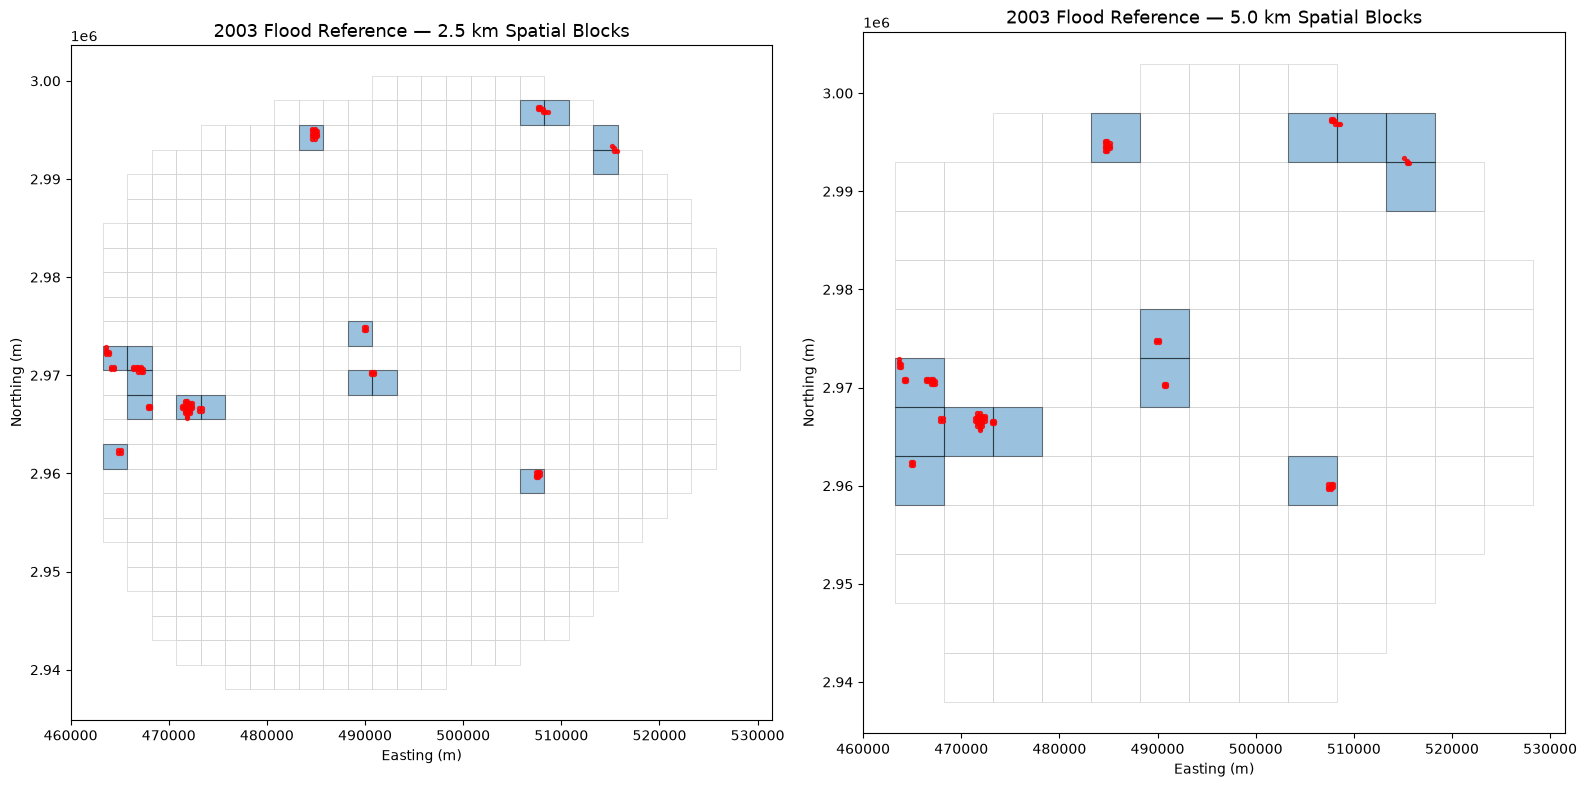

In [40]:
# ============================================================================
# Cell 4 — 2003 spatial block distribution
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

for ax, block_size in zip(
    axes,
    [2500, 5000]
):

    blocks_gdf = spatial_blocks[2003][block_size]

    # --------------------------------------------------------------
    # All spatial blocks
    # --------------------------------------------------------------

    blocks_gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.5
    )

    # --------------------------------------------------------------
    # Flood-containing blocks
    # --------------------------------------------------------------

    blocks_gdf[
        blocks_gdf["contains_flood"]
    ].plot(
        ax=ax,
        alpha=0.45,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------
    # Actual flood-reference cells
    # --------------------------------------------------------------

    flood_points[2003].plot(
        ax=ax,
        markersize=8,
        color="red",
        alpha=0.8
    )

    # --------------------------------------------------------------
    # Formatting
    # --------------------------------------------------------------

    ax.set_title(
        f"2003 Flood Reference — "
        f"{block_size / 1000:.1f} km Spatial Blocks",
        fontsize=13
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

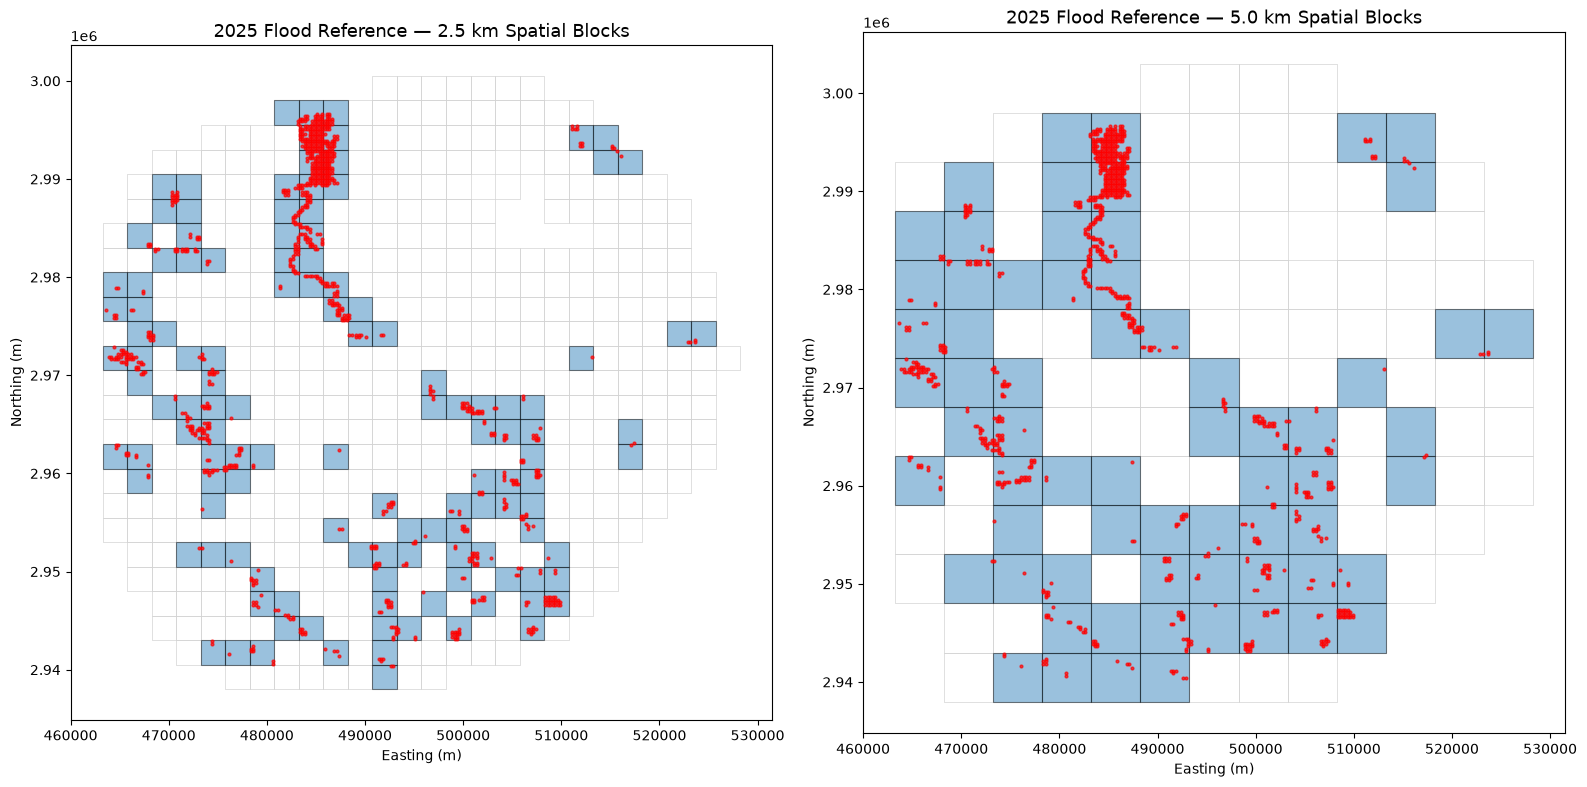

In [41]:
# ============================================================================
# Cell 5 — 2025 spatial block distribution
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

for ax, block_size in zip(
    axes,
    [2500, 5000]
):

    blocks_gdf = spatial_blocks[2025][block_size]

    # --------------------------------------------------------------
    # All spatial blocks
    # --------------------------------------------------------------

    blocks_gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.5
    )

    # --------------------------------------------------------------
    # Flood-containing blocks
    # --------------------------------------------------------------

    blocks_gdf[
        blocks_gdf["contains_flood"]
    ].plot(
        ax=ax,
        alpha=0.45,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------
    # Actual flood-reference cells
    # --------------------------------------------------------------

    flood_points[2025].plot(
        ax=ax,
        markersize=4,
        color="red",
        alpha=0.7
    )

    # --------------------------------------------------------------
    # Formatting
    # --------------------------------------------------------------

    ax.set_title(
        f"2025 Flood Reference — "
        f"{block_size / 1000:.1f} km Spatial Blocks",
        fontsize=13
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================================
# 08.7.2 — Check available spatial context layers
# ============================================================================

print("=" * 75)
print("AVAILABLE SPATIAL CONTEXT VARIABLES")
print("=" * 75)

for name in sorted([x for x in globals() if not x.startswith("_")]):

    obj = globals()[name]

    if isinstance(obj, gpd.GeoDataFrame):
        print(
            f"{name:<40} "
            f"GeoDataFrame | rows={len(obj):,} | CRS={obj.crs}"
        )

AVAILABLE SPATIAL CONTEXT VARIABLES
blocks_gdf                               GeoDataFrame | rows=141 | CRS=EPSG:32644
study_area                               GeoDataFrame | rows=1 | CRS=None
study_area_target                        GeoDataFrame | rows=1 | CRS=EPSG:32644
study_area_utm                           GeoDataFrame | rows=1 | CRS=EPSG:32644


In [44]:
# ============================================================================
# Cell 6 — Load spatial context layers
# ============================================================================

print("=" * 75)
print("LOADING SPATIAL CONTEXT LAYERS")
print("=" * 75)

# --------------------------------------------------------------------------
# Load verified Gomti River network
# --------------------------------------------------------------------------

RIVER_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Gomti_River_Network_Lucknow.gpkg"
)

river_08_7_2 = gpd.read_file(RIVER_FILE)

print("\nGomti River:")
print(f"  Features : {len(river_08_7_2):,}")
print(f"  CRS      : {river_08_7_2.crs}")

# --------------------------------------------------------------------------
# Prepare study-area boundary
# --------------------------------------------------------------------------

study_area_map = study_area_utm.copy()

# Ensure the study area uses the modelling CRS
if study_area_map.crs is None:
    study_area_map = study_area_map.set_crs("EPSG:32644")
elif study_area_map.crs.to_string() != "EPSG:32644":
    study_area_map = study_area_map.to_crs("EPSG:32644")

# --------------------------------------------------------------------------
# Ensure river uses the modelling CRS
# --------------------------------------------------------------------------

if river_08_7_2.crs.to_string() != "EPSG:32644":
    river_08_7_2 = river_08_7_2.to_crs("EPSG:32644")

print("\nStudy area:")
print(f"  Features : {len(study_area_map):,}")
print(f"  CRS      : {study_area_map.crs}")

print("\n✓ Spatial context layers ready")

LOADING SPATIAL CONTEXT LAYERS

Gomti River:
  Features : 160
  CRS      : EPSG:32644

Study area:
  Features : 1
  CRS      : EPSG:32644

✓ Spatial context layers ready


In [45]:
# ============================================================================
# Cell 7 — Verify river and study-area spatial overlap
# ============================================================================

river_union = river_08_7_2.geometry.union_all()
study_union = study_area_map.geometry.union_all()

river_intersects_study = river_union.intersects(study_union)

print("=" * 75)
print("SPATIAL OVERLAP CHECK")
print("=" * 75)

print(f"\nRiver intersects study area : {river_intersects_study}")

if river_intersects_study:
    print("✓ Gomti River overlaps the study area.")
else:
    print("⚠ WARNING: Gomti River does not intersect the study area.")

SPATIAL OVERLAP CHECK

River intersects study area : True
✓ Gomti River overlaps the study area.


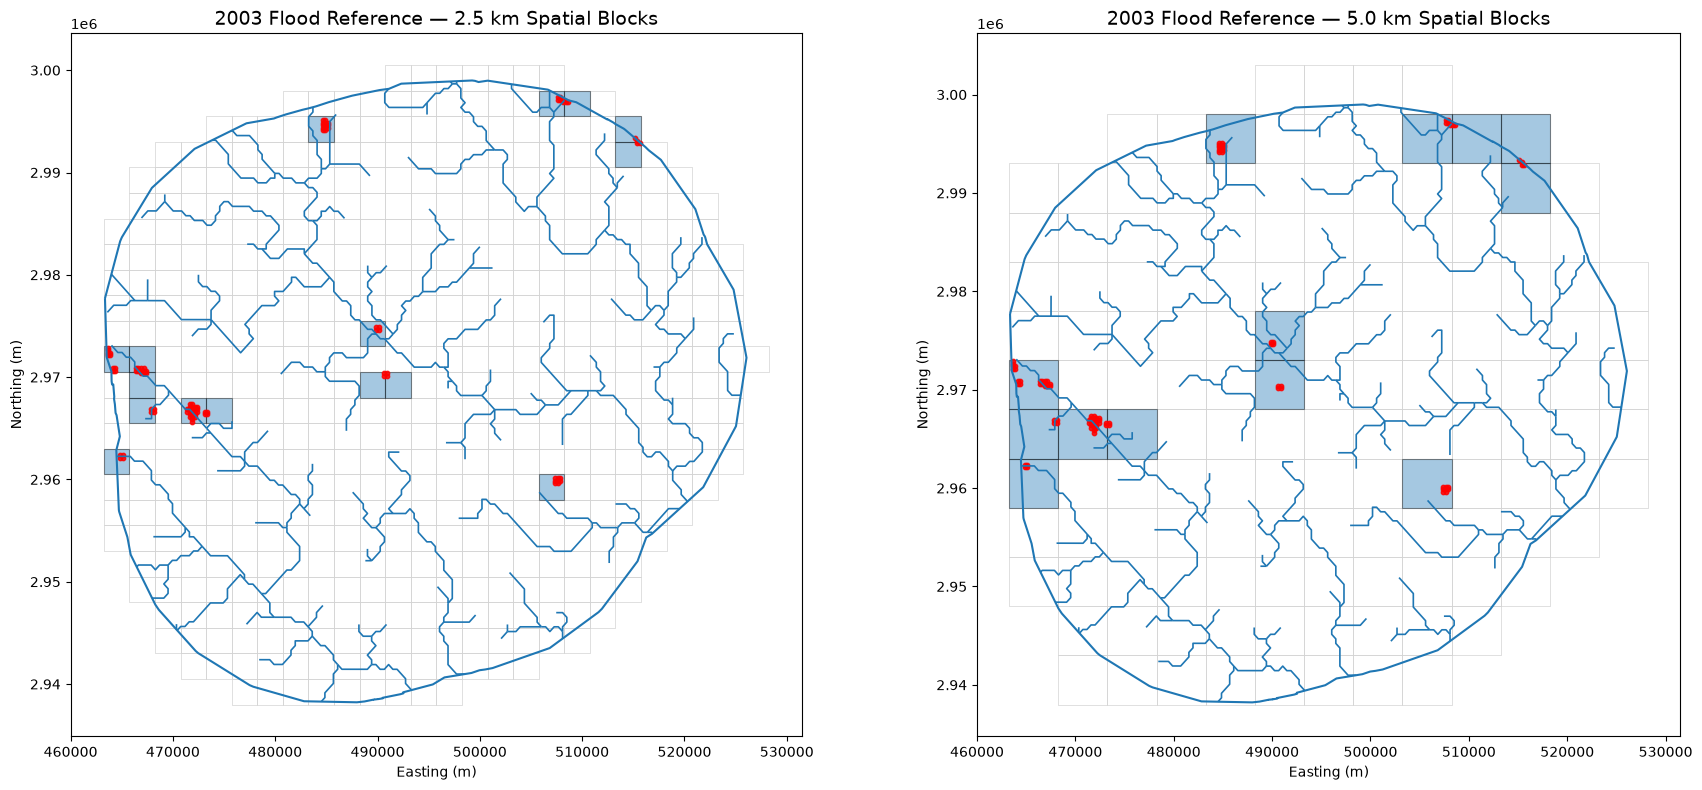

In [51]:
# ============================================================================
# Cell 8 — Final 2003 spatial distribution map
# ============================================================================
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures" / "notebook_08"
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

for ax, block_size in zip(
    axes,
    [2500, 5000]
):

    blocks_gdf = spatial_blocks[2003][block_size]

    # ----------------------------------------------------------------------
    # All spatial blocks
    # ----------------------------------------------------------------------

    blocks_gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.5
    )

    # ----------------------------------------------------------------------
    # Flood-containing blocks
    # ----------------------------------------------------------------------

    blocks_gdf[
        blocks_gdf["contains_flood"]
    ].plot(
        ax=ax,
        alpha=0.40,
        edgecolor="black",
        linewidth=0.8
    )

    # ----------------------------------------------------------------------
    # Study-area boundary
    # ----------------------------------------------------------------------

    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

    # ----------------------------------------------------------------------
    # Gomti River
    # ----------------------------------------------------------------------

    river_08_7_2.plot(
        ax=ax,
        linewidth=1.2
    )

    # ----------------------------------------------------------------------
    # Actual flood-reference cells
    # ----------------------------------------------------------------------

    flood_points[2003].plot(
        ax=ax,
        markersize=10,
        color="red",
        alpha=0.85
    )

    # ----------------------------------------------------------------------
    # Formatting
    # ----------------------------------------------------------------------

    ax.set_title(
        f"2003 Flood Reference — "
        f"{block_size / 1000:.1f} km Spatial Blocks",
        fontsize=14
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(FIGURE_DIR/ "2003_model")
plt.show()

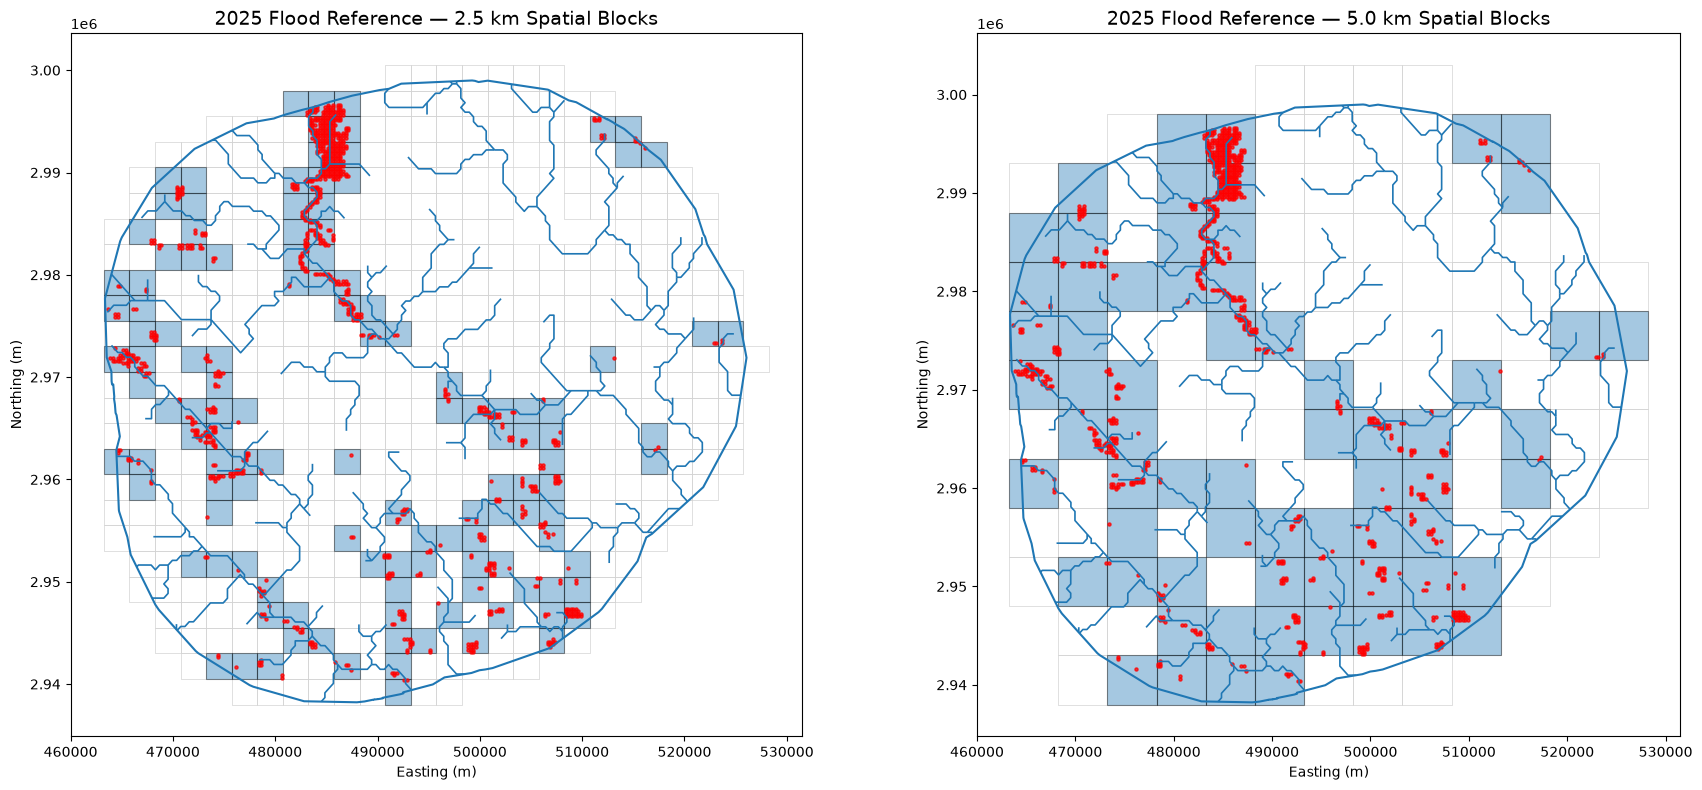

In [52]:
# ============================================================================
# Cell 9 — Final 2025 spatial distribution map
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

for ax, block_size in zip(
    axes,
    [2500, 5000]
):

    blocks_gdf = spatial_blocks[2025][block_size]

    # ----------------------------------------------------------------------
    # All spatial blocks
    # ----------------------------------------------------------------------

    blocks_gdf.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.5
    )

    # ----------------------------------------------------------------------
    # Flood-containing blocks
    # ----------------------------------------------------------------------

    blocks_gdf[
        blocks_gdf["contains_flood"]
    ].plot(
        ax=ax,
        alpha=0.40,
        edgecolor="black",
        linewidth=0.8
    )

    # ----------------------------------------------------------------------
    # Study-area boundary
    # ----------------------------------------------------------------------

    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

    # ----------------------------------------------------------------------
    # Gomti River
    # ----------------------------------------------------------------------

    river_08_7_2.plot(
        ax=ax,
        linewidth=1.2
    )

    # ----------------------------------------------------------------------
    # Actual flood-reference cells
    # ----------------------------------------------------------------------

    flood_points[2025].plot(
        ax=ax,
        markersize=5,
        color="red",
        alpha=0.75
    )

    # ----------------------------------------------------------------------
    # Formatting
    # ----------------------------------------------------------------------

    ax.set_title(
        f"2025 Flood Reference — "
        f"{block_size / 1000:.1f} km Spatial Blocks",
        fontsize=14
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(FIGURE_DIR/ "2025_model")
plt.show()

## 08.7.3 Spatial Train-Test Split Design

The spatial block distribution examined in Section 08.7.2 showed that the 5 km block size provides a practical compromise between spatial separation and the number of independent flood-containing spatial units.

A spatially independent train-test split is required because neighbouring modelling cells are spatially autocorrelated. A conventional random cell-level split could place highly similar neighbouring cells in both the training and testing datasets, resulting in spatial information leakage and overly optimistic model performance.

Therefore, the train-test split is performed at the spatial-block level rather than at the individual-cell level.

For the selected 5 km block framework:

- all modelling cells within the same spatial block are assigned to the same dataset;
- no spatial block is allowed to occur in both training and testing data;
- both training and testing sets must contain flood-reference observations;
- the number of positive spatial blocks is explicitly checked, particularly for 2003 where only 13 of the 142 blocks contain flood-reference cells; and
- the resulting cell-level train-test datasets are verified against their parent spatial blocks.

Because the 2003 flood reference contains substantially fewer positive spatial blocks than 2025, the 2003 dataset is treated as the limiting case when assessing whether the spatial split is feasible.

The split is therefore evaluated at two levels:

1. **Block-level validation** — ensuring that flood-containing spatial blocks are represented in both training and testing sets.
2. **Cell-level validation** — verifying the resulting numbers of flood and non-flood modelling cells and confirming that no spatial block is shared between the two datasets.

The spatial split is considered a validation-design diagnostic at this stage. No Random Forest or XGBoost model is trained until the spatial separation and class representation have been verified.

In [53]:
# ============================================================================
# 08.7.3 — SPATIAL TRAIN-TEST SPLIT DESIGN
# Cell 1 — Select the 5 km spatial-block framework
# ============================================================================

print("=" * 75)
print("08.7.3 — SPATIAL TRAIN-TEST SPLIT DESIGN")
print("=" * 75)

# --------------------------------------------------------------------------
# Final candidate block size entering the split-design stage
# --------------------------------------------------------------------------

VALIDATION_BLOCK_SIZE = 5000  # metres

print(
    f"\nCandidate validation block size: "
    f"{VALIDATION_BLOCK_SIZE / 1000:.1f} km"
)

print("\nThe 5 km block framework will now be evaluated")
print("for both modelling years.")

08.7.3 — SPATIAL TRAIN-TEST SPLIT DESIGN

Candidate validation block size: 5.0 km

The 5 km block framework will now be evaluated
for both modelling years.


In [54]:
# ============================================================================
# Cell 2 — Prepare block-level validation tables
# ============================================================================

validation_blocks = {}

for year in [2003, 2025]:

    blocks = spatial_blocks[year][VALIDATION_BLOCK_SIZE].copy()

    # Calculate block centroid coordinates
    centroids = blocks.geometry.centroid

    blocks["centroid_x"] = centroids.x
    blocks["centroid_y"] = centroids.y

    # Identify flood-containing blocks
    blocks["block_class"] = np.where(
        blocks["flood_cells"] > 0,
        "flood",
        "non_flood"
    )

    validation_blocks[year] = blocks

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(f"Total blocks          : {len(blocks):,}")
    print(
        f"Flood-containing      : "
        f"{(blocks['block_class'] == 'flood').sum():,}"
    )
    print(
        f"Non-flood-only        : "
        f"{(blocks['block_class'] == 'non_flood').sum():,}"
    )


YEAR 2003
-------------------------------------------------------
Total blocks          : 142
Flood-containing      : 13
Non-flood-only        : 129

YEAR 2025
-------------------------------------------------------
Total blocks          : 141
Flood-containing      : 66
Non-flood-only        : 75


In [55]:
# ============================================================================
# Cell 3 — Inspect flood-containing spatial blocks
# ============================================================================

for year in [2003, 2025]:

    positive_blocks = validation_blocks[year].query(
        "flood_cells > 0"
    ).copy()

    positive_blocks = positive_blocks.sort_values(
        "flood_cells",
        ascending=False
    )

    print("\n" + "=" * 75)
    print(f"YEAR {year} — FLOOD-CONTAINING 5 KM BLOCKS")
    print("=" * 75)

    print(
        positive_blocks[
            [
                "block_id",
                "block_x",
                "block_y",
                "flood_cells",
                "total_cells",
                "centroid_x",
                "centroid_y"
            ]
        ].to_string(index=False)
    )


YEAR 2003 — FLOOD-CONTAINING 5 KM BLOCKS
block_id  block_x  block_y  flood_cells  total_cells  centroid_x  centroid_y
     1_5        1        5           26          400    470750.0   2965500.0
     0_6        0        6           22          348    465750.0   2970500.0
    4_11        4       11           13          310    485750.0   2995500.0
     8_4        8        4            8          400    505750.0   2960500.0
    8_11        8       11            6          389    505750.0   2995500.0
     0_4        0        4            4          288    465750.0   2960500.0
     0_5        0        5            4          291    465750.0   2965500.0
     5_6        5        6            4          400    490750.0   2970500.0
     5_7        5        7            4          400    490750.0   2975500.0
   10_10       10       10            2          346    515750.0   2990500.0
   10_11       10       11            2           36    515750.0   2995500.0
     2_5        2        5        

In [56]:
# ============================================================================
# Cell 4 — Define spatial split targets
# ============================================================================

TEST_BLOCK_FRACTION = 0.30

split_targets = {}

for year in [2003, 2025]:

    blocks = validation_blocks[year]

    total_blocks = len(blocks)

    positive_blocks = (
        blocks["flood_cells"] > 0
    ).sum()

    target_test_blocks = round(
        total_blocks * TEST_BLOCK_FRACTION
    )

    target_test_positive_blocks = max(
        2,
        round(positive_blocks * TEST_BLOCK_FRACTION)
    )

    split_targets[year] = {
        "total_test_blocks": target_test_blocks,
        "test_positive_blocks": target_test_positive_blocks
    }

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(
        f"Target test blocks          : "
        f"{target_test_blocks}"
    )

    print(
        f"Target test flood blocks    : "
        f"{target_test_positive_blocks}"
    )


YEAR 2003
-------------------------------------------------------
Target test blocks          : 43
Target test flood blocks    : 4

YEAR 2025
-------------------------------------------------------
Target test blocks          : 42
Target test flood blocks    : 20


In [57]:
# ============================================================================
# Cell 5 — Divide the 5 km block grid into spatial regions
# ============================================================================

print("=" * 75)
print("CREATING SPATIAL REGIONS FOR TRAIN-TEST DESIGN")
print("=" * 75)


def assign_spatial_regions(blocks):
    """
    Divide spatial blocks into four geographic regions using
    the median block-centroid coordinates.

    The assignment uses only spatial coordinates and does not
    use flood labels.
    """

    blocks = blocks.copy()

    # Median coordinates of all blocks
    median_x = blocks["centroid_x"].median()
    median_y = blocks["centroid_y"].median()

    # --------------------------------------------------------------
    # Assign geographic quadrant
    # --------------------------------------------------------------

    blocks["spatial_region"] = np.select(
        [
            (blocks["centroid_x"] <= median_x) &
            (blocks["centroid_y"] >= median_y),

            (blocks["centroid_x"] > median_x) &
            (blocks["centroid_y"] >= median_y),

            (blocks["centroid_x"] <= median_x) &
            (blocks["centroid_y"] < median_y),

            (blocks["centroid_x"] > median_x) &
            (blocks["centroid_y"] < median_y)
        ],
        [
            "NW",
            "NE",
            "SW",
            "SE"
        ],
        default="Unknown"
    )

    return blocks


for year in [2003, 2025]:

    validation_blocks[year] = assign_spatial_regions(
        validation_blocks[year]
    )

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(
        validation_blocks[year]
        ["spatial_region"]
        .value_counts()
        .sort_index()
    )

CREATING SPATIAL REGIONS FOR TRAIN-TEST DESIGN

YEAR 2003
-------------------------------------------------------
spatial_region
NE    34
NW    42
SE    26
SW    40
Name: count, dtype: int64

YEAR 2025
-------------------------------------------------------
spatial_region
NE    33
NW    42
SE    26
SW    40
Name: count, dtype: int64


In [58]:
# ============================================================================
# Cell 6 — Evaluate flood distribution across spatial regions
# ============================================================================

print("=" * 75)
print("FLOOD-BLOCK DISTRIBUTION ACROSS SPATIAL REGIONS")
print("=" * 75)


for year in [2003, 2025]:

    blocks = validation_blocks[year]

    regional_summary = (
        blocks
        .groupby("spatial_region")
        .agg(
            total_blocks=("block_id", "count"),
            flood_blocks=("contains_flood", "sum"),
            flood_cells=("flood_cells", "sum"),
            total_cells=("total_cells", "sum")
        )
        .reset_index()
    )

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(
        regional_summary.to_string(index=False)
    )

FLOOD-BLOCK DISTRIBUTION ACROSS SPATIAL REGIONS

YEAR 2003
---------------------------------------------------------------------------
spatial_region  total_blocks  flood_blocks  flood_cells  total_cells
            NE            34             4           12        10962
            NW            42             4           43        14541
            SE            26             1            8         7904
            SW            40             4           36        14116

YEAR 2025
---------------------------------------------------------------------------
spatial_region  total_blocks  flood_blocks  flood_cells  total_cells
            NE            33             6           19         7034
            NW            42            22          599        14099
            SE            26            14          193         7767
            SW            40            24          207        14176


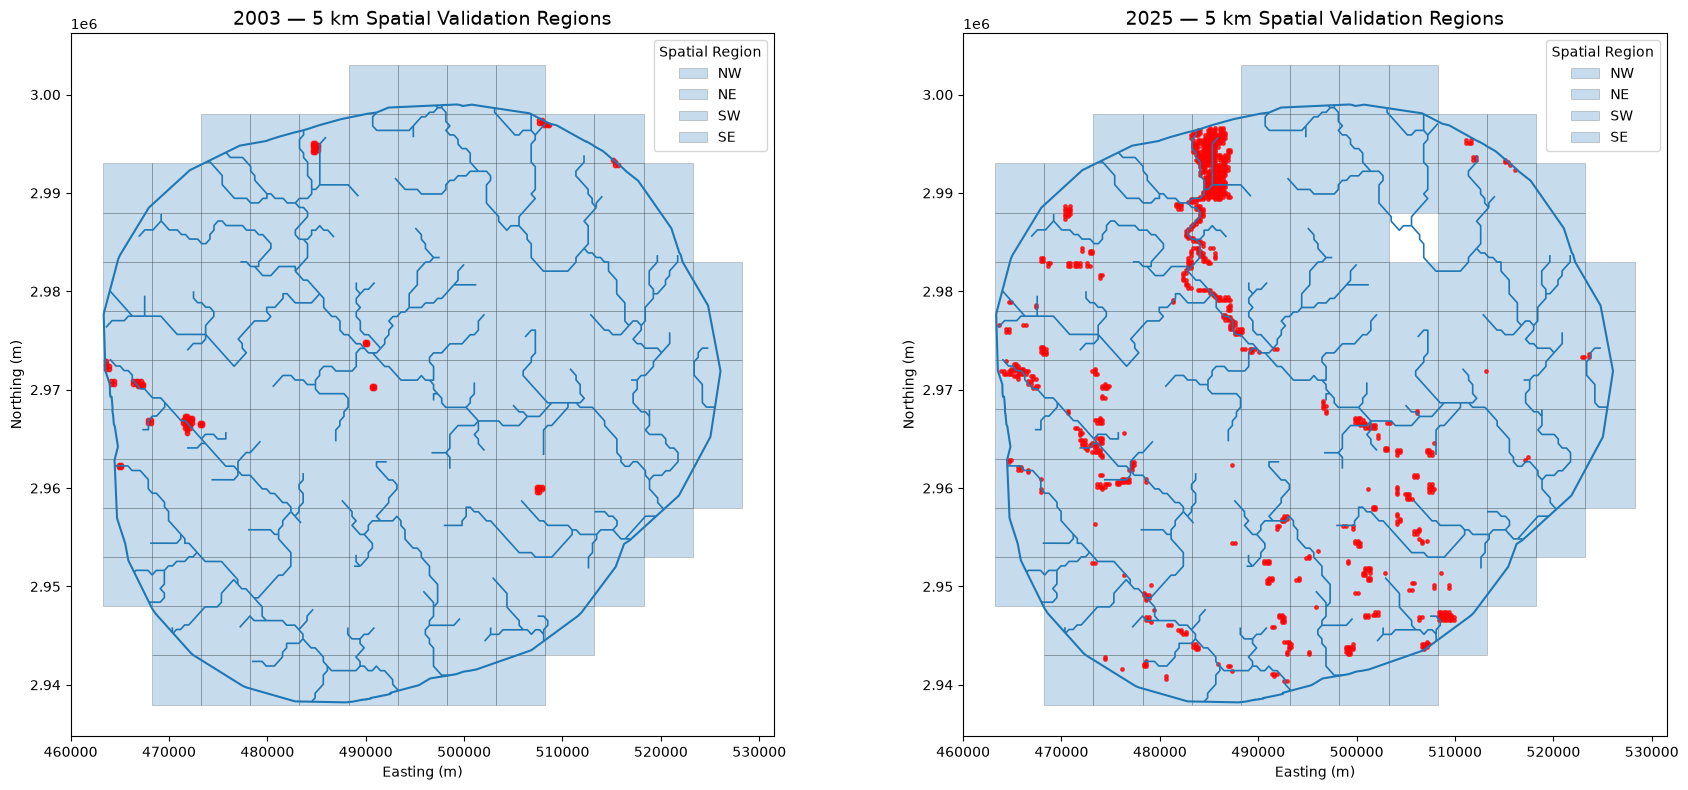

In [59]:
# ============================================================================
# Cell 7 — Visualize spatial regions
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

for ax, year in zip(
    axes,
    [2003, 2025]
):

    blocks = validation_blocks[year]

    # Plot all blocks grouped by spatial region
    for region in ["NW", "NE", "SW", "SE"]:

        region_blocks = blocks[
            blocks["spatial_region"] == region
        ]

        region_blocks.plot(
            ax=ax,
            alpha=0.25,
            edgecolor="black",
            linewidth=0.5,
            label=region
        )

    # Flood-reference cells
    flood_points[year].plot(
        ax=ax,
        markersize=6 if year == 2025 else 10,
        color="red",
        alpha=0.75
    )

    # Study-area boundary
    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

    # Gomti River
    river_08_7_2.plot(
        ax=ax,
        linewidth=1.2
    )

    ax.set_title(
        f"{year} — 5 km Spatial Validation Regions",
        fontsize=14
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

    ax.legend(title="Spatial Region")

plt.tight_layout()
plt.show()

In [60]:
# ============================================================================
# Cell 8 — Select spatial holdout region
# ============================================================================

# --------------------------------------------------------------------------
# Primary spatial holdout
# --------------------------------------------------------------------------

TEST_REGION = "NW"

print("=" * 75)
print("SPATIAL HOLDOUT REGION SELECTION")
print("=" * 75)

print(f"\nSelected test region: {TEST_REGION}")

print(
    "\nSelection basis:"
    "\n- Geographically contiguous region"
    "\n- Approximately 30% of total 5 km blocks"
    "\n- Multiple positive spatial blocks in 2003"
    "\n- Adequate positive spatial representation in 2025"
    "\n- Avoids the single-positive-block limitation of the SE region"
)

SPATIAL HOLDOUT REGION SELECTION

Selected test region: NW

Selection basis:
- Geographically contiguous region
- Approximately 30% of total 5 km blocks
- Multiple positive spatial blocks in 2003
- Adequate positive spatial representation in 2025
- Avoids the single-positive-block limitation of the SE region


In [61]:
# ============================================================================
# Cell 9 — Assign spatial blocks to training and testing
# ============================================================================

spatial_splits = {}

for year in [2003, 2025]:

    blocks = validation_blocks[year].copy()

    # --------------------------------------------------------------
    # Assign dataset based entirely on spatial region
    # --------------------------------------------------------------

    blocks["dataset"] = np.where(
        blocks["spatial_region"] == TEST_REGION,
        "test",
        "train"
    )

    spatial_splits[year] = blocks

    print("\n" + "=" * 75)
    print(f"YEAR {year} — BLOCK-LEVEL SPLIT")
    print("=" * 75)

    print(
        blocks["dataset"].value_counts()
    )


YEAR 2003 — BLOCK-LEVEL SPLIT
dataset
train    100
test      42
Name: count, dtype: int64

YEAR 2025 — BLOCK-LEVEL SPLIT
dataset
train    99
test     42
Name: count, dtype: int64


In [62]:
# ============================================================================
# Cell 10 — Verify flood representation in train and test
# ============================================================================

print("=" * 75)
print("VERIFYING FLOOD REPRESENTATION")
print("=" * 75)


for year in [2003, 2025]:

    blocks = spatial_splits[year]

    summary = (
        blocks
        .groupby("dataset")
        .agg(
            total_blocks=("block_id", "count"),
            flood_blocks=("contains_flood", "sum"),
            flood_cells=("flood_cells", "sum"),
            total_cells=("total_cells", "sum")
        )
        .reset_index()
    )

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(
        summary.to_string(index=False)
    )

VERIFYING FLOOD REPRESENTATION

YEAR 2003
---------------------------------------------------------------------------
dataset  total_blocks  flood_blocks  flood_cells  total_cells
   test            42             4           43        14541
  train           100             9           56        32982

YEAR 2025
---------------------------------------------------------------------------
dataset  total_blocks  flood_blocks  flood_cells  total_cells
   test            42            22          599        14099
  train            99            44          419        28977


In [63]:
# ============================================================================
# Cell 11 — Verify zero block overlap between train and test
# ============================================================================

print("=" * 75)
print("CHECKING FOR SPATIAL BLOCK OVERLAP")
print("=" * 75)


for year in [2003, 2025]:

    blocks = spatial_splits[year]

    train_blocks = set(
        blocks.loc[
            blocks["dataset"] == "train",
            "block_id"
        ]
    )

    test_blocks = set(
        blocks.loc[
            blocks["dataset"] == "test",
            "block_id"
        ]
    )

    overlap = train_blocks.intersection(test_blocks)

    print(f"\nYEAR {year}")
    print(f"Training blocks : {len(train_blocks):,}")
    print(f"Testing blocks  : {len(test_blocks):,}")
    print(f"Overlapping blocks: {len(overlap):,}")

    if len(overlap) == 0:
        print("✓ No spatial blocks are shared between train and test.")
    else:
        print("⚠ WARNING: Spatial block overlap detected!")

CHECKING FOR SPATIAL BLOCK OVERLAP

YEAR 2003
Training blocks : 100
Testing blocks  : 42
Overlapping blocks: 0
✓ No spatial blocks are shared between train and test.

YEAR 2025
Training blocks : 99
Testing blocks  : 42
Overlapping blocks: 0
✓ No spatial blocks are shared between train and test.


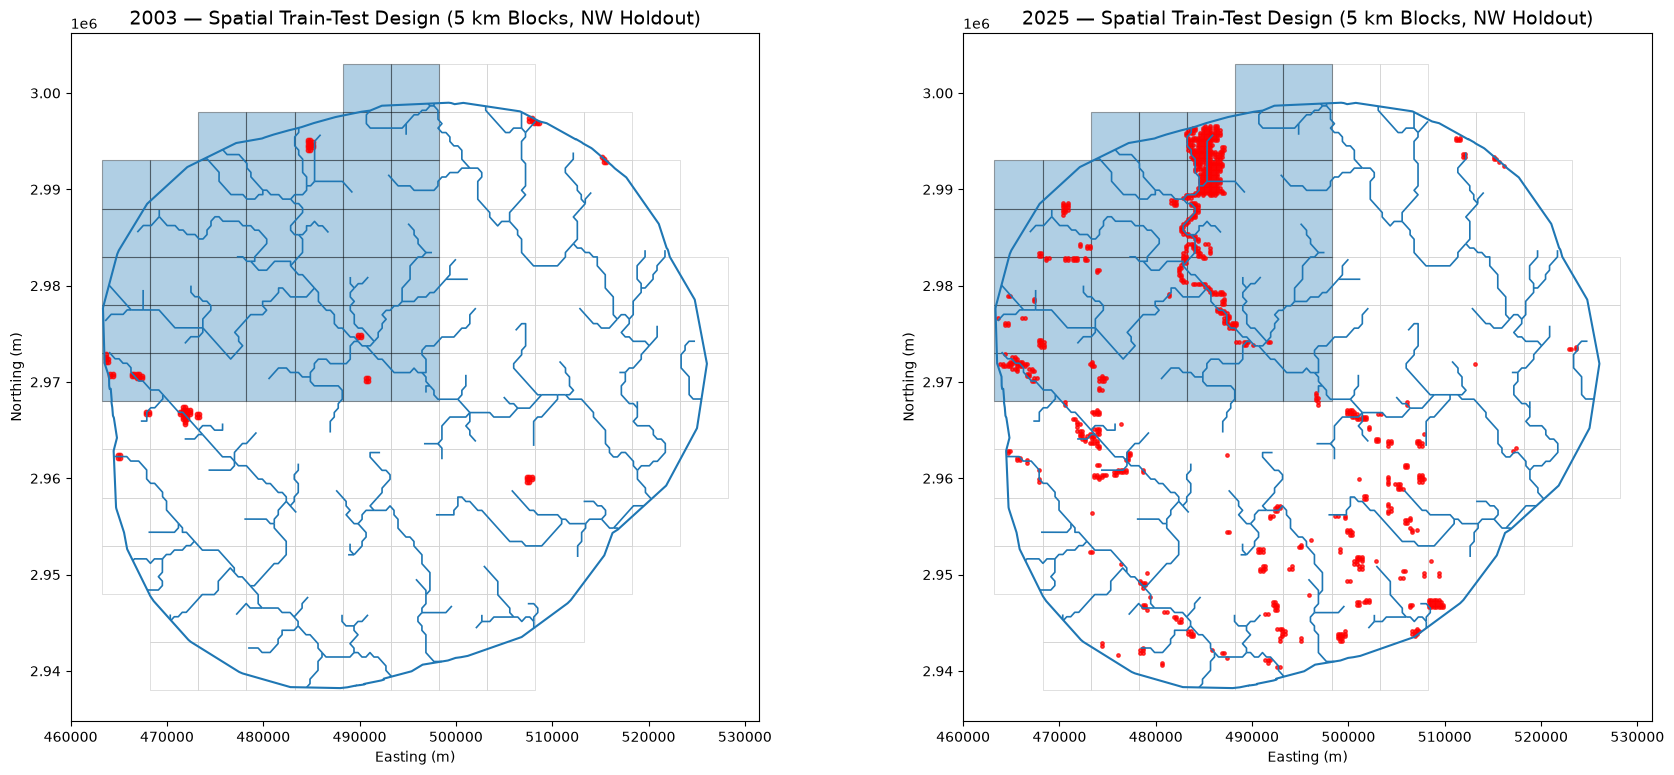

In [64]:
# ============================================================================
# Cell 12 — Final spatial train-test split map
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 8)
)

for ax, year in zip(
    axes,
    [2003, 2025]
):

    blocks = spatial_splits[year]

    # --------------------------------------------------------------
    # Training blocks
    # --------------------------------------------------------------

    blocks[
        blocks["dataset"] == "train"
    ].plot(
        ax=ax,
        facecolor="none",
        edgecolor="lightgray",
        linewidth=0.5
    )

    # --------------------------------------------------------------
    # Test blocks
    # --------------------------------------------------------------

    blocks[
        blocks["dataset"] == "test"
    ].plot(
        ax=ax,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.8
    )

    # --------------------------------------------------------------
    # Study area
    # --------------------------------------------------------------

    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

    # --------------------------------------------------------------
    # Gomti River
    # --------------------------------------------------------------

    river_08_7_2.plot(
        ax=ax,
        linewidth=1.2
    )

    # --------------------------------------------------------------
    # Flood-reference cells
    # --------------------------------------------------------------

    flood_points[year].plot(
        ax=ax,
        markersize=6 if year == 2025 else 10,
        color="red",
        alpha=0.75
    )

    ax.set_title(
        f"{year} — Spatial Train-Test Design "
        f"(5 km Blocks, {TEST_REGION} Holdout)",
        fontsize=14
    )

    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [65]:
# ============================================================================
# Cell 13 — Assign spatial train/test labels to modelling cells
# ============================================================================

print("=" * 75)
print("ASSIGNING SPATIAL SPLIT TO MODELLING CELLS")
print("=" * 75)


def assign_cell_split(df, spatial_blocks_df):
    """
    Assign each modelling cell to train or test according to
    the 5 km spatial block containing that cell.
    """

    temp = df.copy()

    # --------------------------------------------------------------
    # Recreate the same 5 km block identifiers used previously
    # --------------------------------------------------------------

    temp["block_x"] = np.floor(
        (temp["x_utm"] - GRID_LEFT) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    temp["block_y"] = np.floor(
        (temp["y_utm"] - GRID_BOTTOM) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    temp["block_id"] = (
        temp["block_x"].astype(str)
        + "_"
        + temp["block_y"].astype(str)
    )

    # --------------------------------------------------------------
    # Attach train/test assignment from the block table
    # --------------------------------------------------------------

    block_assignment = spatial_blocks_df[
        ["block_id", "dataset"]
    ].copy()

    temp = temp.merge(
        block_assignment,
        on="block_id",
        how="left",
        validate="many_to_one"
    )

    return temp


# --------------------------------------------------------------------------
# Apply split to both modelling years
# --------------------------------------------------------------------------

modelling_2003_split = assign_cell_split(
    modelling_2003_final,
    spatial_splits[2003]
)

modelling_2025_split = assign_cell_split(
    modelling_2025_final,
    spatial_splits[2025]
)


print("\n✓ Spatial train/test assignment transferred to modelling cells.")

ASSIGNING SPATIAL SPLIT TO MODELLING CELLS

✓ Spatial train/test assignment transferred to modelling cells.


In [66]:
# ============================================================================
# Cell 14 — Verify cell-level train/test composition
# ============================================================================

print("=" * 75)
print("CELL-LEVEL TRAIN-TEST VERIFICATION")
print("=" * 75)


for year, df in [
    (2003, modelling_2003_split),
    (2025, modelling_2025_split)
]:

    print(f"\nYEAR {year}")
    print("-" * 75)

    summary = (
        df
        .groupby("dataset")
        .agg(
            cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
    )

    summary["non_flood_cells"] = (
        summary["cells"] - summary["flood_cells"]
    )

    summary["flood_prevalence_%"] = (
        summary["flood_cells"]
        / summary["cells"]
        * 100
    )

    print(summary)

CELL-LEVEL TRAIN-TEST VERIFICATION

YEAR 2003
---------------------------------------------------------------------------
         cells  flood_cells  non_flood_cells  flood_prevalence_%
dataset                                                         
test     14541           43            14498            0.295716
train    32982           56            32926            0.169790

YEAR 2025
---------------------------------------------------------------------------
         cells  flood_cells  non_flood_cells  flood_prevalence_%
dataset                                                         
test     14099          599            13500            4.248528
train    28977          419            28558            1.445974


In [67]:
# ============================================================================
# Cell 15 — Final cell-level spatial leakage check
# ============================================================================

print("=" * 75)
print("FINAL CELL-LEVEL SPATIAL LEAKAGE CHECK")
print("=" * 75)


for year, df in [
    (2003, modelling_2003_split),
    (2025, modelling_2025_split)
]:

    train_blocks = set(
        df.loc[
            df["dataset"] == "train",
            "block_id"
        ]
    )

    test_blocks = set(
        df.loc[
            df["dataset"] == "test",
            "block_id"
        ]
    )

    overlapping_blocks = train_blocks & test_blocks

    train_cells = (
        df["dataset"] == "train"
    ).sum()

    test_cells = (
        df["dataset"] == "test"
    ).sum()

    print(f"\nYEAR {year}")
    print(f"Training cells       : {train_cells:,}")
    print(f"Testing cells        : {test_cells:,}")
    print(f"Shared spatial blocks: {len(overlapping_blocks):,}")

    if len(overlapping_blocks) == 0:
        print("✓ PASS — No spatial leakage detected.")
    else:
        print("✗ FAIL — Spatial leakage detected!")

FINAL CELL-LEVEL SPATIAL LEAKAGE CHECK

YEAR 2003
Training cells       : 32,982
Testing cells        : 14,541
Shared spatial blocks: 0
✓ PASS — No spatial leakage detected.

YEAR 2025
Training cells       : 28,977
Testing cells        : 14,099
Shared spatial blocks: 0
✓ PASS — No spatial leakage detected.


In [68]:
# ============================================================================
# Cell 16 — Verify flood totals before finalizing the spatial split
# ============================================================================

print("=" * 75)
print("VERIFYING FLOOD TOTALS IN FINAL MODELLING TABLES")
print("=" * 75)

for year, original_df, split_df in [
    (2003, modelling_2003_final, modelling_2003_split),
    (2025, modelling_2025_final, modelling_2025_split)
]:

    original_flood = int(
        original_df["Flood"].sum()
    )

    split_flood = int(
        split_df["Flood"].sum()
    )

    original_cells = len(original_df)
    split_cells = len(split_df)

    missing_assignments = split_df["dataset"].isna().sum()

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(f"Original modelling cells : {original_cells:,}")
    print(f"Split modelling cells    : {split_cells:,}")

    print(f"Original flood cells     : {original_flood:,}")
    print(f"Split flood cells        : {split_flood:,}")

    print(f"Unassigned cells         : {missing_assignments:,}")

    if original_flood == split_flood:
        print("✓ Flood totals preserved.")
    else:
        print(
            f"⚠ Flood-total difference: "
            f"{original_flood - split_flood}"
        )

    if missing_assignments == 0:
        print("✓ All modelling cells received a train/test assignment.")
    else:
        print("✗ Some modelling cells were not assigned.")

VERIFYING FLOOD TOTALS IN FINAL MODELLING TABLES

YEAR 2003
---------------------------------------------------------------------------
Original modelling cells : 47,523
Split modelling cells    : 47,523
Original flood cells     : 99
Split flood cells        : 99
Unassigned cells         : 0
✓ Flood totals preserved.
✓ All modelling cells received a train/test assignment.

YEAR 2025
---------------------------------------------------------------------------
Original modelling cells : 43,076
Split modelling cells    : 43,076
Original flood cells     : 1,018
Split flood cells        : 1,018
Unassigned cells         : 0
✓ Flood totals preserved.
✓ All modelling cells received a train/test assignment.


In [69]:
# ============================================================================
# Cell 17 — Verify complete cell assignment
# ============================================================================

print("=" * 75)
print("COMPLETE CELL ASSIGNMENT CHECK")
print("=" * 75)

for year, original_df, split_df in [
    (2003, modelling_2003_final, modelling_2003_split),
    (2025, modelling_2025_final, modelling_2025_split)
]:

    original_count = len(original_df)
    train_count = (
        split_df["dataset"] == "train"
    ).sum()
    test_count = (
        split_df["dataset"] == "test"
    ).sum()

    assigned_count = train_count + test_count

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(f"Original cells : {original_count:,}")
    print(f"Train cells    : {train_count:,}")
    print(f"Test cells     : {test_count:,}")
    print(f"Assigned cells : {assigned_count:,}")
    print(
        f"Difference     : "
        f"{original_count - assigned_count:,}"
    )

    if original_count == assigned_count:
        print("✓ Every modelling cell is assigned exactly once.")
    else:
        print("✗ Cell assignment is incomplete.")

COMPLETE CELL ASSIGNMENT CHECK

YEAR 2003
---------------------------------------------------------------------------
Original cells : 47,523
Train cells    : 32,982
Test cells     : 14,541
Assigned cells : 47,523
Difference     : 0
✓ Every modelling cell is assigned exactly once.

YEAR 2025
---------------------------------------------------------------------------
Original cells : 43,076
Train cells    : 28,977
Test cells     : 14,099
Assigned cells : 43,076
Difference     : 0
✓ Every modelling cell is assigned exactly once.


## 08.7.4 Modelling Dataset Preparation and Final Quality Check

Following the spatial train-test split established in Section 08.7.3, the modelling datasets are prepared for supervised flood-susceptibility modelling.

The spatial split is retained at the 5 km block level, with the northwestern (NW) spatial region held out for testing. Therefore, individual modelling cells are not randomly divided between training and testing; all cells belonging to a spatial block remain within the same dataset.

Before model training, the resulting datasets are subjected to a final quality-control procedure. The following properties are verified:

1. All predefined flood-conditioning predictors are present.
2. Predictor variables contain only numeric and finite values.
3. No missing predictor values are present.
4. The flood target variable contains only binary 0/1 values.
5. No duplicate modelling cells are present.
6. The training and testing datasets retain their intended spatial separation.
7. The number of flood and non-flood observations is reported separately for each year and dataset.

The predictor variables used for supervised modelling are:

- Elevation
- Slope
- Flow Accumulation
- River Distance
- Drainage Density
- Clay
- Sand
- Rainfall
- LULC

The resulting datasets will be used consistently for the subsequent Random Forest and XGBoost flood-susceptibility models.

No resampling or random cell-level reallocation is performed during this quality-control stage, because doing so could compromise the spatial independence established by the block-based validation design.

In [70]:
# ============================================================================
# 08.7.4 — MODELLING DATASET PREPARATION
# Cell 1 — Define modelling predictors
# ============================================================================

print("=" * 75)
print("08.7.4 — MODELLING DATASET PREPARATION")
print("=" * 75)

# --------------------------------------------------------------------------
# Predictor variables
# --------------------------------------------------------------------------

predictor_columns = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

target_column = "Flood"

print("\nPredictor variables:")
for i, column in enumerate(predictor_columns, start=1):
    print(f"{i:2d}. {column}")

print(f"\nTarget variable: {target_column}")

08.7.4 — MODELLING DATASET PREPARATION

Predictor variables:
 1. Elevation
 2. Slope
 3. Flow_Accumulation
 4. River_Distance
 5. Drainage_Density
 6. Clay
 7. Sand
 8. Rainfall
 9. LULC

Target variable: Flood


In [71]:
# ============================================================================
# Cell 2 — Check predictor availability
# ============================================================================

for year, df in [
    (2003, modelling_2003_split),
    (2025, modelling_2025_split)
]:

    print("\n" + "=" * 75)
    print(f"YEAR {year} — PREDICTOR AVAILABILITY")
    print("=" * 75)

    missing_columns = [
        column
        for column in predictor_columns + [target_column]
        if column not in df.columns
    ]

    if len(missing_columns) == 0:
        print("✓ All required modelling columns are present.")
    else:
        print("✗ Missing columns:")
        for column in missing_columns:
            print(f"  - {column}")


YEAR 2003 — PREDICTOR AVAILABILITY
✓ All required modelling columns are present.

YEAR 2025 — PREDICTOR AVAILABILITY
✓ All required modelling columns are present.


In [72]:
# ============================================================================
# Cell 3 — Create X/y train-test datasets
# ============================================================================

model_data = {}

for year, df in [
    (2003, modelling_2003_split),
    (2025, modelling_2025_split)
]:

    train_df = df[
        df["dataset"] == "train"
    ].copy()

    test_df = df[
        df["dataset"] == "test"
    ].copy()

    model_data[year] = {
        "train_df": train_df,
        "test_df": test_df,
        "X_train": train_df[predictor_columns].copy(),
        "X_test": test_df[predictor_columns].copy(),
        "y_train": train_df[target_column].copy(),
        "y_test": test_df[target_column].copy()
    }

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(f"X_train shape: {model_data[year]['X_train'].shape}")
    print(f"X_test shape : {model_data[year]['X_test'].shape}")
    print(f"y_train shape: {model_data[year]['y_train'].shape}")
    print(f"y_test shape : {model_data[year]['y_test'].shape}")


YEAR 2003
-------------------------------------------------------
X_train shape: (32982, 9)
X_test shape : (14541, 9)
y_train shape: (32982,)
y_test shape : (14541,)

YEAR 2025
-------------------------------------------------------
X_train shape: (28977, 9)
X_test shape : (14099, 9)
y_train shape: (28977,)
y_test shape : (14099,)


In [73]:
# ============================================================================
# Cell 4 — Check missing and infinite predictor values
# ============================================================================

print("=" * 75)
print("PREDICTOR DATA-QUALITY CHECK")
print("=" * 75)

for year in [2003, 2025]:

    X_train = model_data[year]["X_train"]
    X_test = model_data[year]["X_test"]

    print(f"\nYEAR {year}")
    print("-" * 75)

    train_missing = X_train.isna().sum().sum()
    test_missing = X_test.isna().sum().sum()

    train_inf = np.isinf(
        X_train.select_dtypes(include=np.number)
    ).sum().sum()

    test_inf = np.isinf(
        X_test.select_dtypes(include=np.number)
    ).sum().sum()

    print(f"Training missing values : {train_missing:,}")
    print(f"Testing missing values  : {test_missing:,}")
    print(f"Training infinite      : {train_inf:,}")
    print(f"Testing infinite       : {test_inf:,}")

    if (
        train_missing == 0
        and test_missing == 0
        and train_inf == 0
        and test_inf == 0
    ):
        print("✓ Predictor data quality check passed.")
    else:
        print("✗ Predictor data-quality problem detected.")

PREDICTOR DATA-QUALITY CHECK

YEAR 2003
---------------------------------------------------------------------------
Training missing values : 0
Testing missing values  : 0
Training infinite      : 0
Testing infinite       : 0
✓ Predictor data quality check passed.

YEAR 2025
---------------------------------------------------------------------------
Training missing values : 0
Testing missing values  : 0
Training infinite      : 0
Testing infinite       : 0
✓ Predictor data quality check passed.


In [74]:
# ============================================================================
# Cell 5 — Verify binary flood target
# ============================================================================

print("=" * 75)
print("FLOOD TARGET VALIDATION")
print("=" * 75)

for year in [2003, 2025]:

    y_train = model_data[year]["y_train"]
    y_test = model_data[year]["y_test"]

    train_values = sorted(y_train.unique())
    test_values = sorted(y_test.unique())

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(f"Training target values: {train_values}")
    print(f"Testing target values : {test_values}")

    if set(train_values).issubset({0, 1}) and \
       set(test_values).issubset({0, 1}):

        print("✓ Binary flood target confirmed.")

    else:
        print("✗ Unexpected target values detected.")

FLOOD TARGET VALIDATION

YEAR 2003
---------------------------------------------------------------------------
Training target values: [np.uint8(0), np.uint8(1)]
Testing target values : [np.uint8(0), np.uint8(1)]
✓ Binary flood target confirmed.

YEAR 2025
---------------------------------------------------------------------------
Training target values: [np.int64(0), np.int64(1)]
Testing target values : [np.int64(0), np.int64(1)]
✓ Binary flood target confirmed.


In [75]:
# ============================================================================
# Cell 6 — Final class distribution
# ============================================================================

print("=" * 75)
print("FINAL TRAIN-TEST CLASS DISTRIBUTION")
print("=" * 75)

for year in [2003, 2025]:

    print(f"\nYEAR {year}")
    print("-" * 75)

    for dataset_name in ["train_df", "test_df"]:

        df = model_data[year][dataset_name]

        flood = int(
            df["Flood"].sum()
        )

        total = len(df)

        non_flood = total - flood

        prevalence = (
            flood / total * 100
        )

        print(
            f"{dataset_name:<10} | "
            f"Total: {total:>6,} | "
            f"Flood: {flood:>4,} | "
            f"Non-flood: {non_flood:>6,} | "
            f"Prevalence: {prevalence:.3f}%"
        )

FINAL TRAIN-TEST CLASS DISTRIBUTION

YEAR 2003
---------------------------------------------------------------------------
train_df   | Total: 32,982 | Flood:   56 | Non-flood: 32,926 | Prevalence: 0.170%
test_df    | Total: 14,541 | Flood:   43 | Non-flood: 14,498 | Prevalence: 0.296%

YEAR 2025
---------------------------------------------------------------------------
train_df   | Total: 28,977 | Flood:  419 | Non-flood: 28,558 | Prevalence: 1.446%
test_df    | Total: 14,099 | Flood:  599 | Non-flood: 13,500 | Prevalence: 4.249%


In [76]:
# ============================================================================
# Cell 7 — Check duplicate modelling cells
# ============================================================================

print("=" * 75)
print("DUPLICATE CELL CHECK")
print("=" * 75)

for year, df in [
    (2003, modelling_2003_split),
    (2025, modelling_2025_split)
]:

    duplicates = df.duplicated(
        subset=["x_utm", "y_utm"]
    ).sum()

    print(f"\nYEAR {year}")
    print(f"Duplicate coordinate cells: {duplicates:,}")

    if duplicates == 0:
        print("✓ No duplicate modelling cells.")
    else:
        print("✗ Duplicate modelling cells detected.")

DUPLICATE CELL CHECK

YEAR 2003
Duplicate coordinate cells: 0
✓ No duplicate modelling cells.

YEAR 2025
Duplicate coordinate cells: 0
✓ No duplicate modelling cells.


In [77]:
# ============================================================================
# Cell 8 — Final spatial integrity check
# ============================================================================

print("=" * 75)
print("FINAL MODEL SPATIAL INTEGRITY CHECK")
print("=" * 75)

for year in [2003, 2025]:

    train_blocks = set(
        model_data[year]["train_df"]["block_id"]
    )

    test_blocks = set(
        model_data[year]["test_df"]["block_id"]
    )

    overlap = train_blocks.intersection(
        test_blocks
    )

    print(f"\nYEAR {year}")
    print(f"Training spatial blocks : {len(train_blocks):,}")
    print(f"Testing spatial blocks  : {len(test_blocks):,}")
    print(f"Shared spatial blocks   : {len(overlap):,}")

    if len(overlap) == 0:
        print("✓ Spatial independence preserved.")
    else:
        print("✗ Spatial overlap detected.")

FINAL MODEL SPATIAL INTEGRITY CHECK

YEAR 2003
Training spatial blocks : 100
Testing spatial blocks  : 42
Shared spatial blocks   : 0
✓ Spatial independence preserved.

YEAR 2025
Training spatial blocks : 99
Testing spatial blocks  : 42
Shared spatial blocks   : 0
✓ Spatial independence preserved.


## 08.8 Predictor Finalization and Class-Imbalance Strategy

Before supervised modelling, the predictor set and class-imbalance strategy are finalized.

### Predictor multicollinearity

Exploratory analysis in Notebook 07 identified a strong relationship between the Clay and Sand predictors (Pearson correlation approximately 0.894), with VIF values of approximately 7.05 for Clay and 6.94 for Sand.

Both variables are retained for the primary Random Forest and XGBoost models because they represent physically meaningful soil properties and tree-based models do not require the predictor independence assumed by conventional linear regression. However, the strong correlation is explicitly acknowledged because correlated predictors can share or redistribute feature importance.

Therefore, model performance is evaluated using the complete predefined predictor set, while interpretation of individual Clay and Sand importance is treated cautiously.

### Class imbalance

The flood-reference datasets contain substantially fewer flood cells than non-flood cells, particularly for 2003. This class imbalance is retained in the spatial test datasets because the test data must represent the actual spatial validation problem.

No oversampling, undersampling, synthetic sample generation, or random cell-level reallocation is applied to the spatial test sets.

Class imbalance is addressed only during model fitting using class-weighting strategies appropriate to the respective algorithms:

- Random Forest uses class weights to increase the contribution of flood observations during tree construction.
- XGBoost uses a positive-class weighting strategy to increase the influence of flood observations during boosting.

The spatially withheld test datasets remain completely untouched and are used only for final spatial performance evaluation.

This approach preserves the spatial independence established in Sections 08.7.2–08.7.4 while allowing the supervised models to learn from the highly imbalanced flood-reference data.

In [78]:
# ============================================================================
# 08.8 — PREDICTOR FINALIZATION
# Cell 1 — Define final predictor set
# ============================================================================

FINAL_PREDICTORS = [
    "Elevation",
    "Slope",
    "Flow_Accumulation",
    "River_Distance",
    "Drainage_Density",
    "Clay",
    "Sand",
    "Rainfall",
    "LULC"
]

TARGET = "Flood"

print("=" * 75)
print("FINAL PREDICTOR SET")
print("=" * 75)

for i, predictor in enumerate(FINAL_PREDICTORS, start=1):
    print(f"{i:2d}. {predictor}")

print(f"\nTarget: {TARGET}")
print(f"Number of predictors: {len(FINAL_PREDICTORS)}")

FINAL PREDICTOR SET
 1. Elevation
 2. Slope
 3. Flow_Accumulation
 4. River_Distance
 5. Drainage_Density
 6. Clay
 7. Sand
 8. Rainfall
 9. LULC

Target: Flood
Number of predictors: 9


In [79]:
# ============================================================================
# Cell 2 — Document Clay-Sand multicollinearity
# ============================================================================

CLAY_SAND_CORRELATION = 0.8936
CLAY_VIF = 7.05
SAND_VIF = 6.94

print("=" * 75)
print("CLAY-SAND MULTICOLLINEARITY")
print("=" * 75)

print(f"\nClay-Sand Pearson correlation : {CLAY_SAND_CORRELATION:.4f}")
print(f"Clay VIF                     : {CLAY_VIF:.2f}")
print(f"Sand VIF                     : {SAND_VIF:.2f}")

print(
    "\nDecision: retain both Clay and Sand "
    "for the primary tree-based models."
)

print(
    "Interpretation: individual importance values for these "
    "correlated predictors will be interpreted cautiously."
)

CLAY-SAND MULTICOLLINEARITY

Clay-Sand Pearson correlation : 0.8936
Clay VIF                     : 7.05
Sand VIF                     : 6.94

Decision: retain both Clay and Sand for the primary tree-based models.
Interpretation: individual importance values for these correlated predictors will be interpreted cautiously.


In [80]:
# ============================================================================
# Cell 3 — Calculate training class weights
# ============================================================================

print("=" * 75)
print("TRAINING CLASS-IMBALANCE WEIGHTS")
print("=" * 75)

class_weights = {}

for year in [2003, 2025]:

    y_train = model_data[year]["y_train"]

    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()

    # Balanced weighting:
    # weight_class = total_samples / (number_of_classes * class_count)

    total_samples = len(y_train)

    weight_negative = (
        total_samples /
        (2 * negative_count)
    )

    weight_positive = (
        total_samples /
        (2 * positive_count)
    )

    class_weights[year] = {
        0: weight_negative,
        1: weight_positive
    }

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(f"Non-flood training cells : {negative_count:,}")
    print(f"Flood training cells     : {positive_count:,}")

    print(f"\nClass weight — non-flood : {weight_negative:.4f}")
    print(f"Class weight — flood     : {weight_positive:.4f}")

TRAINING CLASS-IMBALANCE WEIGHTS

YEAR 2003
-------------------------------------------------------
Non-flood training cells : 32,926
Flood training cells     : 56

Class weight — non-flood : 0.5009
Class weight — flood     : 294.4821

YEAR 2025
-------------------------------------------------------
Non-flood training cells : 28,558
Flood training cells     : 419

Class weight — non-flood : 0.5073
Class weight — flood     : 34.5788


In [81]:
# ============================================================================
# Cell 4 — Verify untouched spatial test sets
# ============================================================================

print("=" * 75)
print("SPATIAL TEST-SET INTEGRITY")
print("=" * 75)

for year in [2003, 2025]:

    train_df = model_data[year]["train_df"]
    test_df = model_data[year]["test_df"]

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(
        f"Training cells : {len(train_df):,}"
    )

    print(
        f"Testing cells  : {len(test_df):,}"
    )

    print(
        f"Testing flood cells : "
        f"{int(test_df['Flood'].sum()):,}"
    )

    print(
        f"Testing non-flood cells : "
        f"{int((test_df['Flood'] == 0).sum()):,}"
    )

    print(
        "✓ Test set remains in its original spatial composition."
    )

SPATIAL TEST-SET INTEGRITY

YEAR 2003
---------------------------------------------------------------------------
Training cells : 32,982
Testing cells  : 14,541
Testing flood cells : 43
Testing non-flood cells : 14,498
✓ Test set remains in its original spatial composition.

YEAR 2025
---------------------------------------------------------------------------
Training cells : 28,977
Testing cells  : 14,099
Testing flood cells : 599
Testing non-flood cells : 13,500
✓ Test set remains in its original spatial composition.


## 08.9 Random Forest Flood Susceptibility Model

A Random Forest classifier is used as the first supervised machine-learning model for flood susceptibility prediction.

Random Forest is an ensemble learning method that constructs multiple decision trees using different subsets of observations and predictor variables. The individual trees are combined to produce the final classification.

The model is appropriate for this study because it can:

- model nonlinear relationships between environmental predictors and flood occurrence;
- capture interactions between flood-conditioning factors;
- accommodate predictors with different numerical ranges;
- provide measures of predictor importance; and
- operate without requiring the linearity or predictor-independence assumptions of conventional linear regression.

### Training and testing strategy

The model is trained separately for the 2003 and 2025 flood-reference datasets.

The spatial train-test split established in Section 08.7 is retained. Therefore:

- the training data consist only of cells belonging to the training spatial blocks;
- the test data consist only of cells belonging to the geographically withheld NW spatial region;
- no test observations are used during model fitting;
- no random cell-level train-test split is introduced.

Because flood observations are highly imbalanced, particularly for 2003, class weighting is used during model training. The class weights are calculated from the training data only.

The spatial test datasets remain untouched.

### Baseline model

A baseline Random Forest model is first fitted using a fixed set of reproducible parameters. This model provides a reference against which later model optimization can be evaluated.

The baseline model predicts the binary flood target:

- `0` — non-flood
- `1` — flood

The predicted probability of the flood class is retained because susceptibility modelling requires a continuous probability/susceptibility surface rather than only a binary classification.

In [82]:
# ============================================================================
# 08.9 — RANDOM FOREST FLOOD SUSCEPTIBILITY MODEL
# Cell 1 — Import model
# ============================================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 75)
print("08.9 — RANDOM FOREST FLOOD SUSCEPTIBILITY MODEL")
print("=" * 75)

print("\nRandom Forest classifier imported successfully.")

08.9 — RANDOM FOREST FLOOD SUSCEPTIBILITY MODEL

Random Forest classifier imported successfully.


In [83]:
# ============================================================================
# Cell 2 — Define baseline Random Forest parameters
# ============================================================================

RF_BASELINE_PARAMS = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1
}

print("Baseline Random Forest parameters:")
print("-" * 55)

for parameter, value in RF_BASELINE_PARAMS.items():
    print(f"{parameter:<20}: {value}")

Baseline Random Forest parameters:
-------------------------------------------------------
n_estimators        : 300
max_depth           : None
min_samples_split   : 2
min_samples_leaf    : 1
max_features        : sqrt
class_weight        : balanced
random_state        : 42
n_jobs              : -1


In [84]:
# ============================================================================
# Cell 3 — Train baseline Random Forest for 2003
# ============================================================================

X_train_2003 = model_data[2003]["X_train"]
y_train_2003 = model_data[2003]["y_train"]

rf_2003 = RandomForestClassifier(
    **RF_BASELINE_PARAMS
)

print("=" * 75)
print("TRAINING RANDOM FOREST — 2003")
print("=" * 75)

print(f"\nTraining observations : {len(X_train_2003):,}")
print(f"Training predictors   : {X_train_2003.shape[1]}")

rf_2003.fit(
    X_train_2003,
    y_train_2003
)

print("\n✓ 2003 Random Forest training completed.")

TRAINING RANDOM FOREST — 2003

Training observations : 32,982
Training predictors   : 9

✓ 2003 Random Forest training completed.


In [85]:
# ============================================================================
# Cell 4 — Train baseline Random Forest for 2025
# ============================================================================

X_train_2025 = model_data[2025]["X_train"]
y_train_2025 = model_data[2025]["y_train"]

rf_2025 = RandomForestClassifier(
    **RF_BASELINE_PARAMS
)

print("=" * 75)
print("TRAINING RANDOM FOREST — 2025")
print("=" * 75)

print(f"\nTraining observations : {len(X_train_2025):,}")
print(f"Training predictors   : {X_train_2025.shape[1]}")

rf_2025.fit(
    X_train_2025,
    y_train_2025
)

print("\n✓ 2025 Random Forest training completed.")

TRAINING RANDOM FOREST — 2025

Training observations : 28,977
Training predictors   : 9

✓ 2025 Random Forest training completed.


In [86]:
# ============================================================================
# Cell 5 — Generate spatial test predictions
# ============================================================================

rf_predictions = {}

for year, model in [
    (2003, rf_2003),
    (2025, rf_2025)
]:

    X_test = model_data[year]["X_test"]

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    rf_predictions[year] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print("\n" + "=" * 75)
    print(f"YEAR {year} — RANDOM FOREST TEST PREDICTIONS")
    print("=" * 75)

    print(f"Test observations       : {len(X_test):,}")
    print(f"Predicted flood cells   : {y_pred.sum():,}")
    print(f"Minimum flood probability: {y_prob.min():.6f}")
    print(f"Maximum flood probability: {y_prob.max():.6f}")
    print(f"Mean flood probability   : {y_prob.mean():.6f}")


YEAR 2003 — RANDOM FOREST TEST PREDICTIONS
Test observations       : 14,541
Predicted flood cells   : 0
Minimum flood probability: 0.000000
Maximum flood probability: 0.496667
Mean flood probability   : 0.004028

YEAR 2025 — RANDOM FOREST TEST PREDICTIONS
Test observations       : 14,099
Predicted flood cells   : 0
Minimum flood probability: 0.000000
Maximum flood probability: 0.496667
Mean flood probability   : 0.016300


In [87]:
# ============================================================================
# Cell 6 — Verify Random Forest predictions
# ============================================================================

print("=" * 75)
print("RANDOM FOREST PREDICTION SANITY CHECK")
print("=" * 75)

for year in [2003, 2025]:

    y_pred = rf_predictions[year]["y_pred"]
    y_prob = rf_predictions[year]["y_prob"]

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(
        f"Predicted classes: "
        f"{np.unique(y_pred, return_counts=True)}"
    )

    print(
        f"Probability values finite: "
        f"{np.isfinite(y_prob).all()}"
    )

    print(
        f"Probability range: "
        f"{y_prob.min():.6f} – {y_prob.max():.6f}"
    )

RANDOM FOREST PREDICTION SANITY CHECK

YEAR 2003
-------------------------------------------------------
Predicted classes: (array([0], dtype=uint8), array([14541]))
Probability values finite: True
Probability range: 0.000000 – 0.496667

YEAR 2025
-------------------------------------------------------
Predicted classes: (array([0]), array([14099]))
Probability values finite: True
Probability range: 0.000000 – 0.496667


## 08.9.1 Spatial Random Forest Evaluation

The baseline Random Forest predictions are evaluated using the spatially withheld NW test region for each flood-reference year.

Because the modelling datasets are strongly class-imbalanced, evaluation is performed using both threshold-independent probability-based metrics and threshold-dependent classification metrics.

The primary threshold-independent metrics are:

- Precision-Recall Area Under the Curve (PR-AUC / Average Precision)
- Receiver Operating Characteristic Area Under the Curve (ROC-AUC)

PR-AUC is given particular importance because it is more informative than accuracy for highly imbalanced flood and non-flood classes.

Threshold-dependent metrics are also reported using the model's default classification threshold of 0.5:

- Precision
- Recall
- F1-score
- Confusion matrix
- Accuracy

The withheld NW spatial region is used only for evaluation. No model parameters or classification thresholds are selected using test-set performance at this stage.

The predicted flood probabilities are retained because they provide a continuous measure of flood susceptibility and can be used for subsequent susceptibility mapping and threshold analysis.

In [88]:
# ============================================================================
# 08.9.1 — SPATIAL RANDOM FOREST EVALUATION
# ============================================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 75)
print("SPATIAL RANDOM FOREST EVALUATION")
print("=" * 75)

rf_evaluation = {}

for year in [2003, 2025]:

    y_test = model_data[year]["y_test"]
    y_pred = rf_predictions[year]["y_pred"]
    y_prob = rf_predictions[year]["y_prob"]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    rf_evaluation[year] = {
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy,
        "Confusion_Matrix": cm
    }

    print(f"\nYEAR {year}")
    print("-" * 55)
    print(f"ROC-AUC        : {roc_auc:.4f}")
    print(f"PR-AUC         : {pr_auc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"Accuracy       : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Non-Flood", "Flood"],
            zero_division=0
        )
    )

SPATIAL RANDOM FOREST EVALUATION

YEAR 2003
-------------------------------------------------------
ROC-AUC        : 0.6614
PR-AUC         : 0.0080
Precision      : 0.0000
Recall         : 0.0000
F1-score       : 0.0000
Accuracy       : 0.9970

Confusion Matrix
[[14498     0]
 [   43     0]]

Classification Report
              precision    recall  f1-score   support

   Non-Flood       1.00      1.00      1.00     14498
       Flood       0.00      0.00      0.00        43

    accuracy                           1.00     14541
   macro avg       0.50      0.50      0.50     14541
weighted avg       0.99      1.00      1.00     14541


YEAR 2025
-------------------------------------------------------
ROC-AUC        : 0.7744
PR-AUC         : 0.1376
Precision      : 0.0000
Recall         : 0.0000
F1-score       : 0.0000
Accuracy       : 0.9575

Confusion Matrix
[[13500     0]
 [  599     0]]

Classification Report
              precision    recall  f1-score   support

   Non-Flood       

## 08.9.2 Random Forest Probability Distribution

The baseline Random Forest produces continuous flood probabilities for each spatially withheld test cell. Because no test observation is classified as flood at the default probability threshold of 0.5, the probability distributions are examined separately for flood and non-flood reference cells.

This analysis is used to determine whether the model assigns systematically higher flood probabilities to observed flood cells, even when those probabilities remain below the default classification threshold.

The distributions are examined separately for 2003 and 2025.

The test data are used only for diagnostic evaluation. No probability threshold is selected from these distributions for the final model.

In [89]:
# ============================================================================
# 08.9.2 — RANDOM FOREST PROBABILITY DISTRIBUTION
# ============================================================================

print("=" * 75)
print("RANDOM FOREST PROBABILITY DISTRIBUTION")
print("=" * 75)

rf_probability_summary = {}

for year in [2003, 2025]:

    y_test = model_data[year]["y_test"]
    y_prob = rf_predictions[year]["y_prob"]

    flood_prob = y_prob[y_test == 1]
    non_flood_prob = y_prob[y_test == 0]

    summary = {
        "flood_count": len(flood_prob),
        "non_flood_count": len(non_flood_prob),

        "flood_min": np.min(flood_prob),
        "flood_median": np.median(flood_prob),
        "flood_mean": np.mean(flood_prob),
        "flood_max": np.max(flood_prob),

        "non_flood_min": np.min(non_flood_prob),
        "non_flood_median": np.median(non_flood_prob),
        "non_flood_mean": np.mean(non_flood_prob),
        "non_flood_max": np.max(non_flood_prob)
    }

    rf_probability_summary[year] = summary

    print(f"\nYEAR {year}")
    print("-" * 60)

    print("Flood-reference cells")
    print(f"  Count       : {summary['flood_count']:,}")
    print(f"  Minimum     : {summary['flood_min']:.6f}")
    print(f"  Median      : {summary['flood_median']:.6f}")
    print(f"  Mean        : {summary['flood_mean']:.6f}")
    print(f"  Maximum     : {summary['flood_max']:.6f}")

    print("\nNon-flood cells")
    print(f"  Count       : {summary['non_flood_count']:,}")
    print(f"  Minimum     : {summary['non_flood_min']:.6f}")
    print(f"  Median      : {summary['non_flood_median']:.6f}")
    print(f"  Mean        : {summary['non_flood_mean']:.6f}")
    print(f"  Maximum     : {summary['non_flood_max']:.6f}")

RANDOM FOREST PROBABILITY DISTRIBUTION

YEAR 2003
------------------------------------------------------------
Flood-reference cells
  Count       : 43
  Minimum     : 0.000000
  Median      : 0.000000
  Mean        : 0.014496
  Maximum     : 0.173333

Non-flood cells
  Count       : 14,498
  Minimum     : 0.000000
  Median      : 0.000000
  Mean        : 0.003997
  Maximum     : 0.496667

YEAR 2025
------------------------------------------------------------
Flood-reference cells
  Count       : 599
  Minimum     : 0.000000
  Median      : 0.026667
  Mean        : 0.058442
  Maximum     : 0.443333

Non-flood cells
  Count       : 13,500
  Minimum     : 0.000000
  Median      : 0.000000
  Mean        : 0.014430
  Maximum     : 0.496667


## 08.9.3 Random Forest Feature Importance

The predictor importance of the baseline Random Forest models is examined to identify which flood-conditioning variables contribute most strongly to the model's decision process.

Feature importance is extracted separately for the 2003 and 2025 Random Forest models and normalized to allow comparison among the nine predictors.

The analysis is used as a diagnostic of model behaviour rather than as definitive evidence of causal influence.

Particular caution is required when interpreting the relative importance of Clay and Sand because these predictors exhibit strong multicollinearity in the exploratory analysis. When predictors contain substantial shared information, tree-based importance can be distributed between correlated variables.

Therefore, the feature-importance results are interpreted in conjunction with the physical meaning of the predictors and the previously identified predictor correlation structure.

In [90]:
# ============================================================================
# 08.9.3 — RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================

print("=" * 75)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 75)

rf_feature_importance = {}

for year, model in [
    (2003, rf_2003),
    (2025, rf_2025)
]:

    importance = pd.Series(
        model.feature_importances_,
        index=FINAL_PREDICTORS
    ).sort_values(ascending=False)

    rf_feature_importance[year] = importance

    print(f"\nYEAR {year}")
    print("-" * 55)

    for rank, (feature, value) in enumerate(
        importance.items(),
        start=1
    ):
        print(
            f"{rank:2d}. "
            f"{feature:<22} : {value:.6f}"
        )

    print(
        f"\nImportance sum       : "
        f"{importance.sum():.6f}"
    )

RANDOM FOREST FEATURE IMPORTANCE

YEAR 2003
-------------------------------------------------------
 1. Clay                   : 0.271303
 2. Slope                  : 0.178617
 3. Rainfall               : 0.153409
 4. Sand                   : 0.120493
 5. Elevation              : 0.101133
 6. Drainage_Density       : 0.093044
 7. River_Distance         : 0.056233
 8. Flow_Accumulation      : 0.023835
 9. LULC                   : 0.001934

Importance sum       : 1.000000

YEAR 2025
-------------------------------------------------------
 1. Flow_Accumulation      : 0.201006
 2. Elevation              : 0.169819
 3. Rainfall               : 0.117095
 4. Slope                  : 0.108964
 5. Sand                   : 0.102740
 6. Clay                   : 0.100112
 7. Drainage_Density       : 0.095931
 8. River_Distance         : 0.089680
 9. LULC                   : 0.014651

Importance sum       : 1.000000


## 08.9.4 Spatial Cross-Validation Design

Hyperparameter tuning of the Random Forest requires validation data that are separate from the final spatial test region.

The northwestern (NW) region established in Section 08.7.3 is therefore retained exclusively as the final test region and is not used during model tuning.

Spatial cross-validation is performed within the remaining training blocks. The existing 5 km spatial blocks are used as the fundamental validation units so that all modelling cells belonging to the same spatial block remain within the same cross-validation fold.

This design reduces the risk of spatial information leakage that can occur when neighbouring cells are randomly distributed between training and validation folds.

Before constructing the cross-validation folds, the training blocks are examined separately for the 2003 and 2025 datasets. Particular attention is given to 2003 because only a small number of training blocks contain flood-reference cells.

The diagnostic checks include:

1. total number of training blocks;
2. number of flood-containing training blocks;
3. number of non-flood-only training blocks;
4. number of flood cells available within the training data; and
5. feasibility of assigning training blocks to multiple spatial validation folds while retaining flood observations in each fold.

The NW test region is not included in this cross-validation design.

No Random Forest hyperparameters are tuned until the spatial cross-validation structure has been verified.

In [93]:
# ============================================================================
# 08.9.4 — SPATIAL CROSS-VALIDATION DESIGN DIAGNOSTIC
# ============================================================================

print("=" * 75)
print("SPATIAL CROSS-VALIDATION DESIGN DIAGNOSTIC")
print("=" * 75)

cv_block_diagnostics = {}

for year in [2003, 2025]:

    # Use the existing training dataframe
    df = model_data[year]["train_df"].copy()

    # ------------------------------------------------------------------------
    # Reconstruct the 5 km spatial block ID
    # ------------------------------------------------------------------------

    df["block_x"] = np.floor(
        (df["x_utm"] - GRID_LEFT) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_y"] = np.floor(
        (df["y_utm"] - GRID_BOTTOM) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_id"] = (
        df["block_x"].astype(str)
        + "_"
        + df["block_y"].astype(str)
    )

    # ------------------------------------------------------------------------
    # Summarize training blocks
    # ------------------------------------------------------------------------

    block_summary = (
        df.groupby("block_id")
        .agg(
            total_cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
        .reset_index()
    )

    block_summary["block_class"] = np.where(
        block_summary["flood_cells"] > 0,
        "Flood-containing",
        "Non-flood-only"
    )

    total_blocks = len(block_summary)

    flood_blocks = (
        block_summary["flood_cells"] > 0
    ).sum()

    non_flood_blocks = (
        block_summary["flood_cells"] == 0
    ).sum()

    total_flood_cells = int(df["Flood"].sum())

    cv_block_diagnostics[year] = block_summary

    print(f"\nYEAR {year}")
    print("-" * 60)

    print(f"Training cells                 : {len(df):,}")
    print(f"Training flood cells           : {total_flood_cells:,}")
    print(
        f"Training non-flood cells       : "
        f"{(df['Flood'] == 0).sum():,}"
    )
    print(f"Training spatial blocks        : {total_blocks:,}")
    print(f"Flood-containing blocks        : {flood_blocks:,}")
    print(f"Non-flood-only blocks          : {non_flood_blocks:,}")

    print("\nFlood cells per flood-containing block")

    print(
        block_summary.loc[
            block_summary["flood_cells"] > 0,
            "flood_cells"
        ]
        .sort_values(ascending=False)
        .to_list()
    )

SPATIAL CROSS-VALIDATION DESIGN DIAGNOSTIC

YEAR 2003
------------------------------------------------------------
Training cells                 : 32,982
Training flood cells           : 56
Training non-flood cells       : 32,926
Training spatial blocks        : 100
Flood-containing blocks        : 9
Non-flood-only blocks          : 91

Flood cells per flood-containing block
[26, 8, 6, 4, 4, 2, 2, 2, 2]

YEAR 2025
------------------------------------------------------------
Training cells                 : 28,977
Training flood cells           : 419
Training non-flood cells       : 28,558
Training spatial blocks        : 99
Flood-containing blocks        : 44
Non-flood-only blocks          : 55

Flood cells per flood-containing block
[31, 29, 28, 25, 25, 23, 22, 20, 19, 16, 16, 14, 13, 13, 12, 12, 10, 9, 8, 7, 7, 6, 6, 5, 5, 4, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1]


## 08.9.5 Spatial Cross-Validation Fold Construction

Three spatial cross-validation folds are constructed within the training data for each flood-reference year.

The existing 5 km spatial blocks are used as the fundamental validation units. All modelling cells belonging to the same spatial block are assigned to the same fold, preventing individual cells from the same block from appearing in both the training and validation portions of a fold.

Three folds are selected because the 2003 training dataset contains only nine flood-containing spatial blocks. Using a larger number of folds would produce validation folds with very few flood-containing blocks and could result in unstable or undefined performance estimates.

The flood-containing blocks are distributed across the three folds as evenly as practical, while the remaining non-flood-only blocks are distributed spatially across the folds.

The resulting folds are validated before model tuning to ensure that:

1. every training block belongs to exactly one fold;
2. no spatial block occurs in both the training and validation portion of a fold;
3. every fold contains flood-reference observations;
4. the number of flood-containing blocks is reported for each fold; and
5. the NW spatial test region remains completely excluded from the cross-validation procedure.

The cross-validation folds are used only for hyperparameter selection. The final NW test region remains untouched until final model evaluation.

In [94]:
# ============================================================================
# 08.9.5 — SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION
# ============================================================================

N_SPATIAL_FOLDS = 3
CV_RANDOM_STATE = 42

spatial_cv_blocks = {}
spatial_cv_data = {}

rng = np.random.RandomState(CV_RANDOM_STATE)

print("=" * 75)
print("SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION")
print("=" * 75)

for year in [2003, 2025]:

    df = model_data[year]["train_df"].copy()

    # ------------------------------------------------------------------------
    # Reconstruct 5 km spatial block IDs
    # ------------------------------------------------------------------------

    df["block_x"] = np.floor(
        (df["x_utm"] - GRID_LEFT) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_y"] = np.floor(
        (df["y_utm"] - GRID_BOTTOM) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_id"] = (
        df["block_x"].astype(str)
        + "_"
        + df["block_y"].astype(str)
    )

    # ------------------------------------------------------------------------
    # Summarize blocks
    # ------------------------------------------------------------------------

    blocks = (
        df.groupby("block_id")
        .agg(
            total_cells=("Flood", "size"),
            flood_cells=("Flood", "sum"),
            centroid_x=("x_utm", "mean"),
            centroid_y=("y_utm", "mean")
        )
        .reset_index()
    )

    blocks["contains_flood"] = blocks["flood_cells"] > 0

    # ------------------------------------------------------------------------
    # Separate positive and negative-only blocks
    # ------------------------------------------------------------------------

    positive_blocks = blocks[
        blocks["contains_flood"]
    ].copy()

    negative_blocks = blocks[
        ~blocks["contains_flood"]
    ].copy()

    # Deterministic shuffle
    positive_blocks = positive_blocks.sample(
        frac=1,
        random_state=CV_RANDOM_STATE
    ).reset_index(drop=True)

    negative_blocks = negative_blocks.sample(
        frac=1,
        random_state=CV_RANDOM_STATE
    ).reset_index(drop=True)

    # ------------------------------------------------------------------------
    # Assign positive blocks as evenly as possible
    # ------------------------------------------------------------------------

    positive_blocks["cv_fold"] = (
        np.arange(len(positive_blocks))
        % N_SPATIAL_FOLDS
    ) + 1

    # ------------------------------------------------------------------------
    # Assign negative-only blocks evenly
    # ------------------------------------------------------------------------

    negative_blocks["cv_fold"] = (
        np.arange(len(negative_blocks))
        % N_SPATIAL_FOLDS
    ) + 1

    # ------------------------------------------------------------------------
    # Combine assignments
    # ------------------------------------------------------------------------

    fold_blocks = pd.concat(
        [
            positive_blocks,
            negative_blocks
        ],
        ignore_index=True
    )

    spatial_cv_blocks[year] = fold_blocks

    # ------------------------------------------------------------------------
    # Transfer fold assignments to cells
    # ------------------------------------------------------------------------

    df = df.merge(
        fold_blocks[
            ["block_id", "cv_fold"]
        ],
        on="block_id",
        how="left",
        validate="many_to_one"
    )

    spatial_cv_data[year] = df

    # ------------------------------------------------------------------------
    # Print diagnostics
    # ------------------------------------------------------------------------

    print(f"\nYEAR {year}")
    print("-" * 60)

    for fold in range(1, N_SPATIAL_FOLDS + 1):

        fold_df = df[
            df["cv_fold"] == fold
        ]

        fold_blocks_df = fold_blocks[
            fold_blocks["cv_fold"] == fold
        ]

        flood_cells = int(
            fold_df["Flood"].sum()
        )

        flood_blocks = int(
            (fold_blocks_df["flood_cells"] > 0).sum()
        )

        print(
            f"Fold {fold}: "
            f"{len(fold_blocks_df):3d} blocks | "
            f"{len(fold_df):6,d} cells | "
            f"{flood_blocks:2d} flood blocks | "
            f"{flood_cells:3d} flood cells"
        )

SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION

YEAR 2003
------------------------------------------------------------
Fold 1:  34 blocks | 11,736 cells |  3 flood blocks |  38 flood cells
Fold 2:  33 blocks |  9,998 cells |  3 flood blocks |   8 flood cells
Fold 3:  33 blocks | 11,248 cells |  3 flood blocks |  10 flood cells

YEAR 2025
------------------------------------------------------------
Fold 1:  34 blocks | 10,229 cells | 15 flood blocks | 126 flood cells
Fold 2:  33 blocks |  9,205 cells | 15 flood blocks | 160 flood cells
Fold 3:  32 blocks |  9,543 cells | 14 flood blocks | 133 flood cells


In [95]:
# ============================================================================
# 08.9.5 — SPATIAL CV FOLD VERIFICATION
# ============================================================================

print("=" * 75)
print("SPATIAL CV FOLD VERIFICATION")
print("=" * 75)

for year in [2003, 2025]:

    df = spatial_cv_data[year]
    blocks = spatial_cv_blocks[year]

    print(f"\nYEAR {year}")
    print("-" * 60)

    # ------------------------------------------------------------------------
    # Every block must have exactly one fold
    # ------------------------------------------------------------------------

    block_fold_counts = (
        blocks.groupby("block_id")["cv_fold"]
        .nunique()
    )

    unique_fold_assignment = (
        (block_fold_counts == 1).all()
    )

    # ------------------------------------------------------------------------
    # Every cell must have exactly one fold
    # ------------------------------------------------------------------------

    missing_fold = df["cv_fold"].isna().sum()

    # ------------------------------------------------------------------------
    # Fold summary
    # ------------------------------------------------------------------------

    fold_summary = (
        df.groupby("cv_fold")
        .agg(
            cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
        .reset_index()
    )

    fold_summary["non_flood_cells"] = (
        fold_summary["cells"]
        - fold_summary["flood_cells"]
    )

    print(
        fold_summary.to_string(index=False)
    )

    print(
        f"\nEvery block assigned exactly once : "
        f"{unique_fold_assignment}"
    )

    print(
        f"Cells with missing fold           : "
        f"{missing_fold}"
    )

    print(
        f"Every fold contains flood cells   : "
        f"{(fold_summary['flood_cells'] > 0).all()}"
    )

    print(
        f"Total flood cells preserved       : "
        f"{int(fold_summary['flood_cells'].sum())}"
    )

SPATIAL CV FOLD VERIFICATION

YEAR 2003
------------------------------------------------------------
 cv_fold  cells  flood_cells  non_flood_cells
       1  11736           38            11698
       2   9998            8             9990
       3  11248           10            11238

Every block assigned exactly once : True
Cells with missing fold           : 0
Every fold contains flood cells   : True
Total flood cells preserved       : 56

YEAR 2025
------------------------------------------------------------
 cv_fold  cells  flood_cells  non_flood_cells
       1  10229          126            10103
       2   9205          160             9045
       3   9543          133             9410

Every block assigned exactly once : True
Cells with missing fold           : 0
Every fold contains flood cells   : True
Total flood cells preserved       : 419


In [96]:
# ============================================================================
# 08.9.5 — REVISED SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION
# ============================================================================

N_SPATIAL_FOLDS = 3

spatial_cv_blocks = {}
spatial_cv_data = {}

print("=" * 75)
print("REVISED SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION")
print("=" * 75)

for year in [2003, 2025]:

    df = model_data[year]["train_df"].copy()

    # ------------------------------------------------------------------------
    # Reconstruct 5 km spatial block IDs
    # ------------------------------------------------------------------------

    df["block_x"] = np.floor(
        (df["x_utm"] - GRID_LEFT) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_y"] = np.floor(
        (df["y_utm"] - GRID_BOTTOM) / VALIDATION_BLOCK_SIZE
    ).astype(int)

    df["block_id"] = (
        df["block_x"].astype(str)
        + "_"
        + df["block_y"].astype(str)
    )

    # ------------------------------------------------------------------------
    # Summarize blocks
    # ------------------------------------------------------------------------

    blocks = (
        df.groupby("block_id")
        .agg(
            total_cells=("Flood", "size"),
            flood_cells=("Flood", "sum"),
            centroid_x=("x_utm", "mean"),
            centroid_y=("y_utm", "mean")
        )
        .reset_index()
    )

    blocks["contains_flood"] = blocks["flood_cells"] > 0

    # ------------------------------------------------------------------------
    # Separate positive and negative-only blocks
    # ------------------------------------------------------------------------

    positive_blocks = blocks[
        blocks["contains_flood"]
    ].copy()

    negative_blocks = blocks[
        ~blocks["contains_flood"]
    ].copy()

    # ------------------------------------------------------------------------
    # Initialize folds
    # ------------------------------------------------------------------------

    positive_blocks["cv_fold"] = np.nan
    negative_blocks["cv_fold"] = np.nan

    # ------------------------------------------------------------------------
    # Balance flood cells across folds
    #
    # Largest flood-containing blocks are assigned first to the fold
    # currently containing the fewest flood cells.
    # ------------------------------------------------------------------------

    positive_blocks = positive_blocks.sort_values(
        by="flood_cells",
        ascending=False
    ).reset_index(drop=True)

    fold_flood_totals = {
        fold: 0
        for fold in range(1, N_SPATIAL_FOLDS + 1)
    }

    for idx, row in positive_blocks.iterrows():

        target_fold = min(
            fold_flood_totals,
            key=fold_flood_totals.get
        )

        positive_blocks.loc[idx, "cv_fold"] = target_fold

        fold_flood_totals[target_fold] += int(
            row["flood_cells"]
        )

    # ------------------------------------------------------------------------
    # Distribute negative-only blocks approximately evenly
    # ------------------------------------------------------------------------

    negative_blocks = negative_blocks.sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)

    negative_blocks["cv_fold"] = (
        np.arange(len(negative_blocks))
        % N_SPATIAL_FOLDS
    ) + 1

    # ------------------------------------------------------------------------
    # Combine block assignments
    # ------------------------------------------------------------------------

    fold_blocks = pd.concat(
        [
            positive_blocks,
            negative_blocks
        ],
        ignore_index=True
    )

    fold_blocks["cv_fold"] = (
        fold_blocks["cv_fold"]
        .astype(int)
    )

    spatial_cv_blocks[year] = fold_blocks

    # ------------------------------------------------------------------------
    # Transfer fold assignment to modelling cells
    # ------------------------------------------------------------------------

    df = df.merge(
        fold_blocks[
            ["block_id", "cv_fold"]
        ],
        on="block_id",
        how="left",
        validate="many_to_one"
    )

    spatial_cv_data[year] = df

    # ------------------------------------------------------------------------
    # Report fold distribution
    # ------------------------------------------------------------------------

    print(f"\nYEAR {year}")
    print("-" * 60)

    for fold in range(1, N_SPATIAL_FOLDS + 1):

        fold_df = df[
            df["cv_fold"] == fold
        ]

        fold_blocks_df = fold_blocks[
            fold_blocks["cv_fold"] == fold
        ]

        flood_cells = int(
            fold_df["Flood"].sum()
        )

        flood_blocks = int(
            (fold_blocks_df["flood_cells"] > 0).sum()
        )

        print(
            f"Fold {fold}: "
            f"{len(fold_blocks_df):3d} blocks | "
            f"{len(fold_df):6,d} cells | "
            f"{flood_blocks:2d} flood blocks | "
            f"{flood_cells:3d} flood cells"
        )

REVISED SPATIAL CROSS-VALIDATION FOLD CONSTRUCTION

YEAR 2003
------------------------------------------------------------
Fold 1:  32 blocks | 11,048 cells |  1 flood blocks |  26 flood cells
Fold 2:  34 blocks | 10,398 cells |  4 flood blocks |  16 flood cells
Fold 3:  34 blocks | 11,536 cells |  4 flood blocks |  14 flood cells

YEAR 2025
------------------------------------------------------------
Fold 1:  34 blocks |  9,724 cells | 15 flood blocks | 140 flood cells
Fold 2:  33 blocks |  9,919 cells | 15 flood blocks | 140 flood cells
Fold 3:  32 blocks |  9,334 cells | 14 flood blocks | 139 flood cells


In [97]:
# ============================================================================
# 08.9.5 — SPATIAL CV FOLD VERIFICATION
# ============================================================================

print("=" * 75)
print("SPATIAL CV FOLD VERIFICATION")
print("=" * 75)

for year in [2003, 2025]:

    df = spatial_cv_data[year]
    blocks = spatial_cv_blocks[year]

    print(f"\nYEAR {year}")
    print("-" * 60)

    block_fold_counts = (
        blocks.groupby("block_id")["cv_fold"]
        .nunique()
    )

    unique_fold_assignment = (
        (block_fold_counts == 1).all()
    )

    missing_fold = df["cv_fold"].isna().sum()

    fold_summary = (
        df.groupby("cv_fold")
        .agg(
            cells=("Flood", "size"),
            flood_cells=("Flood", "sum")
        )
        .reset_index()
    )

    fold_summary["non_flood_cells"] = (
        fold_summary["cells"]
        - fold_summary["flood_cells"]
    )

    print(
        fold_summary.to_string(index=False)
    )

    print(
        f"\nEvery block assigned exactly once : "
        f"{unique_fold_assignment}"
    )

    print(
        f"Cells with missing fold           : "
        f"{missing_fold}"
    )

    print(
        f"Every fold contains flood cells   : "
        f"{(fold_summary['flood_cells'] > 0).all()}"
    )

    print(
        f"Total flood cells preserved       : "
        f"{int(fold_summary['flood_cells'].sum())}"
    )

SPATIAL CV FOLD VERIFICATION

YEAR 2003
------------------------------------------------------------
 cv_fold  cells  flood_cells  non_flood_cells
       1  11048           26            11022
       2  10398           16            10382
       3  11536           14            11522

Every block assigned exactly once : True
Cells with missing fold           : 0
Every fold contains flood cells   : True
Total flood cells preserved       : 56

YEAR 2025
------------------------------------------------------------
 cv_fold  cells  flood_cells  non_flood_cells
       1   9724          140             9584
       2   9919          140             9779
       3   9334          139             9195

Every block assigned exactly once : True
Cells with missing fold           : 0
Every fold contains flood cells   : True
Total flood cells preserved       : 419


## 08.9.6 Random Forest Hyperparameter Tuning

The baseline Random Forest demonstrated useful discriminatory ability, particularly for the 2025 flood-reference dataset, but its default classification threshold produced no predicted flood cells in the withheld NW test region.

Hyperparameter tuning is therefore performed to determine whether the predictive ranking of flood susceptibility can be improved.

The tuning procedure uses only the training data. The NW spatial test region established in Section 08.7.3 remains completely excluded from hyperparameter selection.

The 5 km spatial cross-validation folds constructed in Section 08.9.5 are used for model selection. For each candidate Random Forest configuration, the model is trained using two spatial folds and evaluated on the remaining spatial fold. This process is repeated so that each fold serves once as the validation fold.

Average Precision (PR-AUC) is used as the primary model-selection metric because the flood-reference classes are strongly imbalanced. ROC-AUC is also recorded as a secondary discrimination metric.

The following Random Forest hyperparameters are evaluated:

- Number of trees (`n_estimators`)
- Maximum tree depth (`max_depth`)
- Minimum samples required in a terminal leaf (`min_samples_leaf`)
- Number of predictors considered at each split (`max_features`)

Class weighting is retained during training to account for the severe flood/non-flood imbalance. No resampling or synthetic observations are introduced.

The selected configuration is based exclusively on spatial cross-validation performance. The withheld NW region is reserved for final evaluation after the final model is trained using all available training data.

In [98]:
# ============================================================================
# 08.9.6 — RANDOM FOREST HYPERPARAMETER GRID
# ============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)
from itertools import product

RF_PARAM_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5]
}

# Generate all combinations
RF_PARAM_COMBINATIONS = [
    dict(zip(
        RF_PARAM_GRID.keys(),
        values
    ))
    for values in product(
        *RF_PARAM_GRID.values()
    )
]

print("=" * 75)
print("RANDOM FOREST HYPERPARAMETER GRID")
print("=" * 75)

print(
    f"Total parameter combinations : "
    f"{len(RF_PARAM_COMBINATIONS)}"
)

for i, params in enumerate(
    RF_PARAM_COMBINATIONS,
    start=1
):
    print(f"{i:2d}. {params}")

RANDOM FOREST HYPERPARAMETER GRID
Total parameter combinations : 54
 1. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
 2. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5}
 3. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
 4. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 0.5}
 5. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
 6. {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'max_features': 0.5}
 7. {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
 8. {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 0.5}
 9. {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
10. {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 0.5}
11. {'n_estimators': 200, 'max_dept

In [100]:
# ============================================================================
# 08.9.6 — SPATIAL RF HYPERPARAMETER TUNING
# ============================================================================

rf_tuning_results = {}

for year in [2003, 2025]:

    print("\n" + "=" * 75)
    print(f"RF HYPERPARAMETER TUNING — YEAR {year}")
    print("=" * 75)

    df = spatial_cv_data[year].copy()

    X = df[FINAL_PREDICTORS]
    y = df[TARGET]

    year_results = []

    for param_number, params in enumerate(
        RF_PARAM_COMBINATIONS,
        start=1
    ):

        fold_pr_auc = []
        fold_roc_auc = []

        for validation_fold in range(
            1,
            N_SPATIAL_FOLDS + 1
        ):

            train_mask = (
                df["cv_fold"] != validation_fold
            )

            validation_mask = (
                df["cv_fold"] == validation_fold
            )

            X_cv_train = X.loc[train_mask]
            y_cv_train = y.loc[train_mask]

            X_cv_valid = X.loc[validation_mask]
            y_cv_valid = y.loc[validation_mask]

            model = RandomForestClassifier(
                **params,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

            model.fit(
                X_cv_train,
                y_cv_train
            )

            y_valid_prob = model.predict_proba(
                X_cv_valid
            )[:, 1]

            pr_auc = average_precision_score(
                y_cv_valid,
                y_valid_prob
            )

            roc_auc = roc_auc_score(
                y_cv_valid,
                y_valid_prob
            )

            fold_pr_auc.append(pr_auc)
            fold_roc_auc.append(roc_auc)

        year_results.append({
            **params,
            "Mean_PR_AUC": np.mean(fold_pr_auc),
            "Std_PR_AUC": np.std(fold_pr_auc),
            "Mean_ROC_AUC": np.mean(fold_roc_auc),
            "Std_ROC_AUC": np.std(fold_roc_auc)
        })

        print(
            f"[{param_number:02d}/{len(RF_PARAM_COMBINATIONS)}] "
            f"PR-AUC = {np.mean(fold_pr_auc):.4f} ± "
            f"{np.std(fold_pr_auc):.4f} | "
            f"ROC-AUC = {np.mean(fold_roc_auc):.4f} ± "
            f"{np.std(fold_roc_auc):.4f}"
        )

    rf_tuning_results[year] = pd.DataFrame(
        year_results
    )

print("\nRF spatial tuning completed.")


RF HYPERPARAMETER TUNING — YEAR 2003
[01/54] PR-AUC = 0.1155 ± 0.0347 | ROC-AUC = 0.8378 ± 0.1124
[02/54] PR-AUC = 0.1009 ± 0.0468 | ROC-AUC = 0.8149 ± 0.1037
[03/54] PR-AUC = 0.1073 ± 0.0254 | ROC-AUC = 0.8395 ± 0.0952
[04/54] PR-AUC = 0.0960 ± 0.0412 | ROC-AUC = 0.8244 ± 0.0886
[05/54] PR-AUC = 0.1130 ± 0.0156 | ROC-AUC = 0.8645 ± 0.1070
[06/54] PR-AUC = 0.0920 ± 0.0251 | ROC-AUC = 0.8622 ± 0.1057
[07/54] PR-AUC = 0.0764 ± 0.0282 | ROC-AUC = 0.8512 ± 0.1163
[08/54] PR-AUC = 0.0618 ± 0.0357 | ROC-AUC = 0.8280 ± 0.1039
[09/54] PR-AUC = 0.0841 ± 0.0261 | ROC-AUC = 0.8280 ± 0.1073
[10/54] PR-AUC = 0.0653 ± 0.0348 | ROC-AUC = 0.8303 ± 0.1079
[11/54] PR-AUC = 0.0962 ± 0.0231 | ROC-AUC = 0.8551 ± 0.1075
[12/54] PR-AUC = 0.0785 ± 0.0246 | ROC-AUC = 0.8556 ± 0.1019
[13/54] PR-AUC = 0.1155 ± 0.0351 | ROC-AUC = 0.8378 ± 0.1123
[14/54] PR-AUC = 0.1002 ± 0.0474 | ROC-AUC = 0.8145 ± 0.1039
[15/54] PR-AUC = 0.1071 ± 0.0257 | ROC-AUC = 0.8395 ± 0.0953
[16/54] PR-AUC = 0.0960 ± 0.0412 | ROC-AUC = 0.

In [101]:
# ============================================================================
# 08.9.6 — RF TUNING RESULTS
# ============================================================================

print("=" * 75)
print("RANDOM FOREST TUNING RESULTS")
print("=" * 75)

rf_best_params = {}

for year in [2003, 2025]:

    results = rf_tuning_results[year].copy()

    results = results.sort_values(
        by=[
            "Mean_PR_AUC",
            "Mean_ROC_AUC"
        ],
        ascending=False
    ).reset_index(drop=True)

    rf_tuning_results[year] = results

    best = results.iloc[0]

    rf_best_params[year] = {
        "n_estimators": int(best["n_estimators"]),
        "max_depth": (
            None
            if pd.isna(best["max_depth"])
            else int(best["max_depth"])
        ),
        "min_samples_leaf": int(
            best["min_samples_leaf"]
        ),
        "max_features": best["max_features"]
    }

    print(f"\nYEAR {year}")
    print("-" * 60)

    print("Best parameters:")
    print(
        f"  n_estimators     : "
        f"{rf_best_params[year]['n_estimators']}"
    )
    print(
        f"  max_depth        : "
        f"{rf_best_params[year]['max_depth']}"
    )
    print(
        f"  min_samples_leaf : "
        f"{rf_best_params[year]['min_samples_leaf']}"
    )
    print(
        f"  max_features     : "
        f"{rf_best_params[year]['max_features']}"
    )

    print(
        f"\nMean PR-AUC       : "
        f"{best['Mean_PR_AUC']:.4f}"
    )

    print(
        f"PR-AUC Std        : "
        f"{best['Std_PR_AUC']:.4f}"
    )

    print(
        f"Mean ROC-AUC      : "
        f"{best['Mean_ROC_AUC']:.4f}"
    )

    print(
        f"ROC-AUC Std       : "
        f"{best['Std_ROC_AUC']:.4f}"
    )

    print("\nTop 5 configurations:")

    display(
        results.head(5)
    )

RANDOM FOREST TUNING RESULTS

YEAR 2003
------------------------------------------------------------
Best parameters:
  n_estimators     : 400
  max_depth        : 20
  min_samples_leaf : 5
  max_features     : sqrt

Mean PR-AUC       : 0.1223
PR-AUC Std        : 0.0155
Mean ROC-AUC      : 0.8821
ROC-AUC Std       : 0.1235

Top 5 configurations:


,n_estimators,max_depth,min_samples_leaf,max_features,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,400,20.0,5,sqrt,0.122261,0.015537,0.882054,0.123512
1,400,NaN,5,sqrt,0.122245,0.015558,0.882062,0.123518
2,600,NaN,5,sqrt,0.120222,0.013243,0.880240,0.127012
3,600,20.0,5,sqrt,0.120220,0.013246,0.880234,0.127008
4,400,20.0,1,sqrt,0.117310,0.036872,0.845061,0.113446



YEAR 2025
------------------------------------------------------------
Best parameters:
  n_estimators     : 600
  max_depth        : None
  min_samples_leaf : 5
  max_features     : sqrt

Mean PR-AUC       : 0.0603
PR-AUC Std        : 0.0067
Mean ROC-AUC      : 0.7737
ROC-AUC Std       : 0.0180

Top 5 configurations:


,n_estimators,max_depth,min_samples_leaf,max_features,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,600,NaN,5,sqrt,0.060300,0.006705,0.773695,0.018010
1,600,20.0,5,sqrt,0.060204,0.006866,0.773807,0.018233
2,400,NaN,5,sqrt,0.059654,0.006363,0.772656,0.018584
3,400,20.0,5,sqrt,0.059161,0.006959,0.774220,0.018200
4,200,20.0,5,sqrt,0.059025,0.008545,0.767814,0.022788


In [102]:
# ============================================================================
# 08.9.6 — FINAL RF TUNING SUMMARY
# ============================================================================

print("=" * 75)
print("FINAL RF TUNING SUMMARY")
print("=" * 75)

for year in [2003, 2025]:

    results = rf_tuning_results[year].copy()

    results = results.sort_values(
        by=["Mean_PR_AUC", "Mean_ROC_AUC"],
        ascending=False
    ).reset_index(drop=True)

    rf_tuning_results[year] = results

    print(f"\nYEAR {year}")
    print("-" * 75)

    display(
        results.head(5)
    )

FINAL RF TUNING SUMMARY

YEAR 2003
---------------------------------------------------------------------------


,n_estimators,max_depth,min_samples_leaf,max_features,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,400,20.0,5,sqrt,0.122261,0.015537,0.882054,0.123512
1,400,NaN,5,sqrt,0.122245,0.015558,0.882062,0.123518
2,600,NaN,5,sqrt,0.120222,0.013243,0.880240,0.127012
3,600,20.0,5,sqrt,0.120220,0.013246,0.880234,0.127008
4,400,20.0,1,sqrt,0.117310,0.036872,0.845061,0.113446



YEAR 2025
---------------------------------------------------------------------------


,n_estimators,max_depth,min_samples_leaf,max_features,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,600,NaN,5,sqrt,0.060300,0.006705,0.773695,0.018010
1,600,20.0,5,sqrt,0.060204,0.006866,0.773807,0.018233
2,400,NaN,5,sqrt,0.059654,0.006363,0.772656,0.018584
3,400,20.0,5,sqrt,0.059161,0.006959,0.774220,0.018200
4,200,20.0,5,sqrt,0.059025,0.008545,0.767814,0.022788


## 08.9.7 Final Tuned Random Forest

The final Random Forest models are trained separately for the 2003 and 2025 flood-reference datasets using the hyperparameter configurations selected through spatial cross-validation in Section 08.9.6.

The selected configurations are:

### 2003
- n_estimators = 400
- max_depth = 20
- min_samples_leaf = 5
- max_features = sqrt

### 2025
- n_estimators = 600
- max_depth = None
- min_samples_leaf = 5
- max_features = sqrt

Class weighting is retained using `balanced` class weights.

After hyperparameter selection, each final model is retrained using all available training observations for its respective year.

The northwestern (NW) spatial test region remains completely excluded from model fitting and hyperparameter selection. It is used only for final evaluation of the tuned models.

Predicted flood probabilities are retained as the primary continuous model output for subsequent susceptibility mapping.

In [103]:
# ============================================================================
# 08.9.7 — FINAL TUNED RANDOM FOREST TRAINING
# ============================================================================

print("=" * 75)
print("FINAL TUNED RANDOM FOREST TRAINING")
print("=" * 75)

rf_final_models = {}

for year in [2003, 2025]:

    params = rf_best_params[year]

    X_train = model_data[year]["X_train"]
    y_train = model_data[year]["y_train"]

    final_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(
        X_train,
        y_train
    )

    rf_final_models[year] = final_model

    print(f"\nYEAR {year}")
    print("-" * 60)

    print(f"Training observations : {len(X_train):,}")
    print(f"Flood observations    : {int(y_train.sum()):,}")
    print(f"Non-flood observations: {int((y_train == 0).sum()):,}")

    print("\nSelected parameters:")

    for parameter, value in params.items():
        print(f"  {parameter:<18}: {value}")

    print("\nModel training completed.")

FINAL TUNED RANDOM FOREST TRAINING

YEAR 2003
------------------------------------------------------------
Training observations : 32,982
Flood observations    : 56
Non-flood observations: 32,926

Selected parameters:
  n_estimators      : 400
  max_depth         : 20
  min_samples_leaf  : 5
  max_features      : sqrt

Model training completed.

YEAR 2025
------------------------------------------------------------
Training observations : 28,977
Flood observations    : 419
Non-flood observations: 28,558

Selected parameters:
  n_estimators      : 600
  max_depth         : None
  min_samples_leaf  : 5
  max_features      : sqrt

Model training completed.


In [104]:
# ============================================================================
# 08.9.7 — FINAL TUNED RF TEST PREDICTIONS
# ============================================================================

rf_final_predictions = {}

print("=" * 75)
print("FINAL TUNED RANDOM FOREST TEST PREDICTIONS")
print("=" * 75)

for year in [2003, 2025]:

    model = rf_final_models[year]

    X_test = model_data[year]["X_test"]

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    rf_final_predictions[year] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print(f"\nYEAR {year}")
    print("-" * 60)

    print(
        f"Test observations       : "
        f"{len(X_test):,}"
    )

    print(
        f"Predicted flood cells   : "
        f"{int(y_pred.sum()):,}"
    )

    print(
        f"Minimum flood probability: "
        f"{y_prob.min():.6f}"
    )

    print(
        f"Maximum flood probability: "
        f"{y_prob.max():.6f}"
    )

    print(
        f"Mean flood probability   : "
        f"{y_prob.mean():.6f}"
    )

FINAL TUNED RANDOM FOREST TEST PREDICTIONS

YEAR 2003
------------------------------------------------------------
Test observations       : 14,541
Predicted flood cells   : 13
Minimum flood probability: 0.000000
Maximum flood probability: 0.588418
Mean flood probability   : 0.012095

YEAR 2025
------------------------------------------------------------
Test observations       : 14,099
Predicted flood cells   : 136
Minimum flood probability: 0.000000
Maximum flood probability: 0.802524
Mean flood probability   : 0.045923


In [105]:
# ============================================================================
# 08.9.7 — FINAL TUNED RF PREDICTION SANITY CHECK
# ============================================================================

print("=" * 75)
print("FINAL TUNED RF PREDICTION SANITY CHECK")
print("=" * 75)

for year in [2003, 2025]:

    y_pred = rf_final_predictions[year]["y_pred"]
    y_prob = rf_final_predictions[year]["y_prob"]

    print(f"\nYEAR {year}")
    print("-" * 55)

    print(
        "Predicted classes:",
        np.unique(
            y_pred,
            return_counts=True
        )
    )

    print(
        f"Probability values finite: "
        f"{np.isfinite(y_prob).all()}"
    )

    print(
        f"Probability range: "
        f"{y_prob.min():.6f} – "
        f"{y_prob.max():.6f}"
    )

FINAL TUNED RF PREDICTION SANITY CHECK

YEAR 2003
-------------------------------------------------------
Predicted classes: (array([0, 1], dtype=uint8), array([14528,    13]))
Probability values finite: True
Probability range: 0.000000 – 0.588418

YEAR 2025
-------------------------------------------------------
Predicted classes: (array([0, 1]), array([13963,   136]))
Probability values finite: True
Probability range: 0.000000 – 0.802524


## 08.9.8 Baseline versus Tuned Random Forest Evaluation

The final tuned Random Forest models are evaluated on the same withheld NW spatial test regions used for evaluation of the baseline models.

The purpose of this comparison is to determine whether hyperparameter tuning improved spatial generalization to the geographically withheld test region.

The baseline and tuned models are evaluated using identical test observations and identical evaluation metrics:

- PR-AUC (Average Precision)
- ROC-AUC
- Precision
- Recall
- F1-score
- Accuracy
- Confusion matrix

PR-AUC is treated as the primary comparison metric because of the strong flood/non-flood class imbalance.

The NW test region was not used during hyperparameter selection and remains independent of the tuning process.

No classification threshold is optimized in this section. Threshold-dependent metrics are reported using the default probability threshold of 0.5.

The continuous flood probabilities are retained for subsequent susceptibility mapping and threshold analysis.

In [106]:
# ============================================================================
# 08.9.8 — BASELINE VS TUNED RANDOM FOREST EVALUATION
# ============================================================================

print("=" * 75)
print("BASELINE VS TUNED RANDOM FOREST EVALUATION")
print("=" * 75)

rf_comparison_results = {}

for year in [2003, 2025]:

    y_test = model_data[year]["y_test"]

    # ------------------------------------------------------------------------
    # Baseline predictions
    # ------------------------------------------------------------------------

    baseline_pred = rf_predictions[year]["y_pred"]
    baseline_prob = rf_predictions[year]["y_prob"]

    # ------------------------------------------------------------------------
    # Tuned predictions
    # ------------------------------------------------------------------------

    tuned_pred = rf_final_predictions[year]["y_pred"]
    tuned_prob = rf_final_predictions[year]["y_prob"]

    # ------------------------------------------------------------------------
    # Calculate metrics
    # ------------------------------------------------------------------------

    baseline_metrics = {
        "PR_AUC": average_precision_score(
            y_test,
            baseline_prob
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            baseline_prob
        ),
        "Precision": precision_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            baseline_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            baseline_pred
        )
    }

    tuned_metrics = {
        "PR_AUC": average_precision_score(
            y_test,
            tuned_prob
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            tuned_prob
        ),
        "Precision": precision_score(
            y_test,
            tuned_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            tuned_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            tuned_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            tuned_pred
        )
    }

    rf_comparison_results[year] = {
        "Baseline": baseline_metrics,
        "Tuned": tuned_metrics,
        "Baseline_CM": confusion_matrix(
            y_test,
            baseline_pred
        ),
        "Tuned_CM": confusion_matrix(
            y_test,
            tuned_pred
        )
    }

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(
        f"{'Metric':<15}"
        f"{'Baseline':>15}"
        f"{'Tuned':>15}"
        f"{'Change':>15}"
    )

    print("-" * 60)

    for metric in [
        "PR_AUC",
        "ROC_AUC",
        "Precision",
        "Recall",
        "F1",
        "Accuracy"
    ]:

        baseline_value = baseline_metrics[metric]
        tuned_value = tuned_metrics[metric]
        change = tuned_value - baseline_value

        print(
            f"{metric:<15}"
            f"{baseline_value:>15.4f}"
            f"{tuned_value:>15.4f}"
            f"{change:>+15.4f}"
        )

    print("\nBaseline Confusion Matrix")
    print(
        rf_comparison_results[year]["Baseline_CM"]
    )

    print("\nTuned Confusion Matrix")
    print(
        rf_comparison_results[year]["Tuned_CM"]
    )

BASELINE VS TUNED RANDOM FOREST EVALUATION

YEAR 2003
---------------------------------------------------------------------------
Metric                Baseline          Tuned         Change
------------------------------------------------------------
PR_AUC                  0.0080         0.0131        +0.0051
ROC_AUC                 0.6614         0.6466        -0.0149
Precision               0.0000         0.0000        +0.0000
Recall                  0.0000         0.0000        +0.0000
F1                      0.0000         0.0000        +0.0000
Accuracy                0.9970         0.9961        -0.0009

Baseline Confusion Matrix
[[14498     0]
 [   43     0]]

Tuned Confusion Matrix
[[14485    13]
 [   43     0]]

YEAR 2025
---------------------------------------------------------------------------
Metric                Baseline          Tuned         Change
------------------------------------------------------------
PR_AUC                  0.1376         0.1429        +0.0052

## 08.9.9 Tuned Random Forest Feature Importance

Feature importance is extracted from the final tuned Random Forest models to examine whether the predictor contributions differ from those of the baseline models.

The importance values are reported separately for 2003 and 2025.

These values are interpreted as model-based predictive importance rather than causal influence.

Particular caution is applied to Clay and Sand because their strong correlation can cause predictive importance to be distributed between the two variables.

The tuned-model importance is compared with the baseline importance to determine whether hyperparameter optimization substantially changes the predictor structure learned by the Random Forest.

In [107]:
# ============================================================================
# 08.9.9 — TUNED RANDOM FOREST FEATURE IMPORTANCE
# ============================================================================

print("=" * 75)
print("TUNED RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 75)

rf_tuned_feature_importance = {}

for year in [2003, 2025]:

    model = rf_final_models[year]

    importance = pd.Series(
        model.feature_importances_,
        index=FINAL_PREDICTORS
    ).sort_values(
        ascending=False
    )

    rf_tuned_feature_importance[year] = importance

    print(f"\nYEAR {year}")
    print("-" * 60)

    for rank, (feature, value) in enumerate(
        importance.items(),
        start=1
    ):
        print(
            f"{rank:2d}. "
            f"{feature:<22} : {value:.6f}"
        )

    print(
        f"\nImportance sum : "
        f"{importance.sum():.6f}"
    )

TUNED RANDOM FOREST FEATURE IMPORTANCE

YEAR 2003
------------------------------------------------------------
 1. Clay                   : 0.274531
 2. Slope                  : 0.174357
 3. Rainfall               : 0.157954
 4. Sand                   : 0.122569
 5. Elevation              : 0.099734
 6. Drainage_Density       : 0.084864
 7. River_Distance         : 0.060945
 8. Flow_Accumulation      : 0.023334
 9. LULC                   : 0.001712

Importance sum : 1.000000

YEAR 2025
------------------------------------------------------------
 1. Flow_Accumulation      : 0.209536
 2. Elevation              : 0.171485
 3. Rainfall               : 0.116280
 4. Slope                  : 0.108880
 5. Sand                   : 0.100973
 6. Clay                   : 0.099430
 7. Drainage_Density       : 0.095006
 8. River_Distance         : 0.085313
 9. LULC                   : 0.013097

Importance sum : 1.000000


## 08.10.1 XGBoost Baseline Model

XGBoost (Extreme Gradient Boosting) is used as a second nonlinear tree-based model for flood susceptibility prediction.

Unlike Random Forest, which builds trees independently and aggregates their predictions, XGBoost builds trees sequentially, with each subsequent tree attempting to reduce the errors of the existing ensemble.

Separate models are trained for 2003 and 2025.

The same predictor variables, spatial train-test split, and training datasets used for the Random Forest are retained to ensure a fair model comparison.

Because the flood class is highly imbalanced, `scale_pos_weight` is calculated separately from the training data for each year. The spatial test data are not resampled or reweighted.

The baseline model is evaluated before hyperparameter tuning using PR-AUC and ROC-AUC as the primary ranking metrics, with threshold-based classification metrics reported at the default 0.5 threshold.

In [109]:
# ============================================================================
# 08.10.1 — XGBOOST BASELINE MODEL
# ============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

print("=" * 75)
print("XGBOOST BASELINE MODEL")
print("=" * 75)

xgb_baseline_models = {}
xgb_predictions = {}
xgb_baseline_results = {}

# Baseline parameters
XGB_BASELINE_PARAMS = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1
}

for year in [2003, 2025]:

    print(f"\n{'=' * 75}")
    print(f"YEAR {year}")
    print(f"{'=' * 75}")

    # ------------------------------------------------------------------------
    # Training and test data
    # ------------------------------------------------------------------------

    X_train = model_data[year]["X_train"]
    X_test = model_data[year]["X_test"]

    y_train = model_data[year]["y_train"]
    y_test = model_data[year]["y_test"]

    # ------------------------------------------------------------------------
    # Calculate class imbalance weight from TRAINING DATA ONLY
    # ------------------------------------------------------------------------

    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()

    scale_pos_weight = negative_count / positive_count

    print(f"Training samples      : {len(y_train):,}")
    print(f"Training flood cells  : {positive_count:,}")
    print(f"Training non-flood    : {negative_count:,}")
    print(f"scale_pos_weight      : {scale_pos_weight:.4f}")

    # ------------------------------------------------------------------------
    # Create baseline XGBoost model
    # ------------------------------------------------------------------------

    params = XGB_BASELINE_PARAMS.copy()
    params["scale_pos_weight"] = scale_pos_weight

    model = XGBClassifier(**params)

    # ------------------------------------------------------------------------
    # Train
    # ------------------------------------------------------------------------

    model.fit(
        X_train,
        y_train
    )

    # ------------------------------------------------------------------------
    # Predict probabilities on UNTOUCHED NW TEST REGION
    # ------------------------------------------------------------------------

    y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    # ------------------------------------------------------------------------
    # Store model and predictions
    # ------------------------------------------------------------------------

    xgb_baseline_models[year] = model

    xgb_predictions[year] = {
        "y_prob": y_prob,
        "y_pred": y_pred,
        "y_test": y_test
    }

    # ------------------------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------------------------

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    xgb_baseline_results[year] = {
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy,
        "Confusion_Matrix": cm
    }

    # ------------------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------------------

    print("\nTest-set performance")
    print("-" * 60)

    print(f"PR-AUC       : {pr_auc:.4f}")
    print(f"ROC-AUC      : {roc_auc:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1           : {f1:.4f}")
    print(f"Accuracy     : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nProbability diagnostics")
    print("-" * 60)

    print(f"Min probability : {y_prob.min():.6f}")
    print(f"Max probability : {y_prob.max():.6f}")
    print(f"Mean probability: {y_prob.mean():.6f}")

    print(
        f"Predicted flood cells @ 0.5: "
        f"{y_pred.sum():,}"
    )

XGBOOST BASELINE MODEL

YEAR 2003
Training samples      : 32,982
Training flood cells  : 56
Training non-flood    : 32,926
scale_pos_weight      : 587.9643

Test-set performance
------------------------------------------------------------
PR-AUC       : 0.0144
ROC-AUC      : 0.7285
Precision    : 0.0000
Recall       : 0.0000
F1           : 0.0000
Accuracy     : 0.9962

Confusion Matrix
[[14486    12]
 [   43     0]]

Probability diagnostics
------------------------------------------------------------
Min probability : 0.000001
Max probability : 0.960750
Mean probability: 0.001712
Predicted flood cells @ 0.5: 12

YEAR 2025
Training samples      : 28,977
Training flood cells  : 419
Training non-flood    : 28,558
scale_pos_weight      : 68.1575

Test-set performance
------------------------------------------------------------
PR-AUC       : 0.1340
ROC-AUC      : 0.7658
Precision    : 0.1919
Recall       : 0.0634
F1           : 0.0954
Accuracy     : 0.9489

Confusion Matrix
[[13340   160]


## 08.10.2 XGBoost Spatial Hyperparameter Tuning

The baseline XGBoost model established initial predictive performance using the same spatial train-test design as the Random Forest model.

Hyperparameter tuning is now performed using the training data only.

The previously established 5-km spatial blocks and three-fold spatial cross-validation design are retained. All cells belonging to a spatial block remain in the same fold to reduce spatial leakage between training and validation data.

The withheld NW spatial region is not used during hyperparameter tuning and remains reserved for final model evaluation.

Because flood cells are highly underrepresented relative to non-flood cells, `scale_pos_weight` is calculated separately for each year using the corresponding training data.

The primary tuning metric is Average Precision (PR-AUC), because it is more informative than accuracy for the highly imbalanced flood/non-flood classification problem. ROC-AUC is retained as a secondary metric.

A moderate hyperparameter grid is used to balance model exploration with computational cost and the limited number of positive flood blocks, particularly for 2003.

For each hyperparameter combination, the XGBoost model is trained independently within each spatial fold and evaluated on the spatially withheld fold.

The best configuration for each year is selected using the highest mean spatial-CV PR-AUC.

In [113]:
# ============================================================================
# 08.10.2 — XGBOOST SPATIAL HYPERPARAMETER TUNING
# ============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from itertools import product
import numpy as np
import pandas as pd
import time

print("=" * 75)
print("XGBOOST SPATIAL HYPERPARAMETER TUNING")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Hyperparameter grid
# ----------------------------------------------------------------------------

XGB_PARAM_GRID = {
    "n_estimators": [200, 400],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.03, 0.05, 0.10],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}


# ----------------------------------------------------------------------------
# 2. Generate combinations
# ----------------------------------------------------------------------------

param_names = list(XGB_PARAM_GRID.keys())

param_combinations = list(
    product(
        *[
            XGB_PARAM_GRID[name]
            for name in param_names
        ]
    )
)

print("\nHyperparameter search space")
print("-" * 60)

for name, values in XGB_PARAM_GRID.items():
    print(f"{name:<20}: {values}")

print(f"\nTotal combinations: {len(param_combinations)}")
print(f"Spatial folds     : {N_SPATIAL_FOLDS}")
print(
    f"Total model fits  : "
    f"{len(param_combinations) * N_SPATIAL_FOLDS * 2}"
)


# ----------------------------------------------------------------------------
# 3. Storage
# ----------------------------------------------------------------------------

xgb_tuning_results = {}


# ----------------------------------------------------------------------------
# 4. Tune separately for each year
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    print("\n")
    print("=" * 75)
    print(f"YEAR {year}")
    print("=" * 75)

    # ------------------------------------------------------------------------
    # Get spatial CV data
    # ------------------------------------------------------------------------

    cv_df = spatial_cv_data[year].copy()

    X = cv_df[FINAL_PREDICTORS].copy()
    y = cv_df["Flood"].astype(int).copy()

    fold_ids = cv_df["cv_fold"].values

    # ------------------------------------------------------------------------
    # Overall training distribution
    # ------------------------------------------------------------------------

    negative_count = int((y == 0).sum())
    positive_count = int((y == 1).sum())

    scale_pos_weight = (
        negative_count / positive_count
    )

    print(f"Training samples     : {len(y):,}")
    print(f"Training flood cells : {positive_count:,}")
    print(f"Training non-flood   : {negative_count:,}")
    print(
        f"scale_pos_weight     : "
        f"{scale_pos_weight:.4f}"
    )

    # ------------------------------------------------------------------------
    # Verify spatial folds
    #
    # IMPORTANT:
    # cv_fold values are 1, 2, 3.
    # ------------------------------------------------------------------------

    print("\nSpatial fold class distribution")
    print("-" * 60)

    for fold in range(1, N_SPATIAL_FOLDS + 1):

        valid_mask = fold_ids == fold
        train_mask = fold_ids != fold

        fold_y_valid = y.loc[valid_mask]
        fold_y_train = y.loc[train_mask]

        print(
            f"Fold {fold}: "
            f"train flood={int((fold_y_train == 1).sum()):>3}, "
            f"train non-flood={int((fold_y_train == 0).sum()):>6} | "
            f"valid flood={int((fold_y_valid == 1).sum()):>3}, "
            f"valid non-flood={int((fold_y_valid == 0).sum()):>6}"
        )

        if fold_y_train.nunique() < 2:
            raise ValueError(
                f"Fold {fold} training set for {year} "
                f"does not contain both classes."
            )

        if fold_y_valid.nunique() < 2:
            raise ValueError(
                f"Fold {fold} validation set for {year} "
                f"does not contain both classes."
            )

    year_results = []

    # ------------------------------------------------------------------------
    # Hyperparameter combinations
    # ------------------------------------------------------------------------

    for combo_number, values in enumerate(
        param_combinations,
        start=1
    ):

        params = dict(
            zip(
                param_names,
                values
            )
        )

        fold_pr_auc = []
        fold_roc_auc = []

        start_time = time.time()

        # --------------------------------------------------------------------
        # Spatial cross-validation
        # --------------------------------------------------------------------

        for fold in range(1, N_SPATIAL_FOLDS + 1):

            train_mask = fold_ids != fold
            valid_mask = fold_ids == fold

            X_train_fold = X.loc[train_mask]
            X_valid_fold = X.loc[valid_mask]

            y_train_fold = y.loc[train_mask]
            y_valid_fold = y.loc[valid_mask]

            # ---------------------------------------------------------------
            # Calculate class weight from current training folds
            # ---------------------------------------------------------------

            fold_negative = int(
                (y_train_fold == 0).sum()
            )

            fold_positive = int(
                (y_train_fold == 1).sum()
            )

            fold_scale_pos_weight = (
                fold_negative / fold_positive
            )

            # ---------------------------------------------------------------
            # Create XGBoost model
            # ---------------------------------------------------------------

            model = XGBClassifier(
                **params,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=fold_scale_pos_weight,
                random_state=42,
                n_jobs=-1
            )

            # ---------------------------------------------------------------
            # Train
            # ---------------------------------------------------------------

            model.fit(
                X_train_fold,
                y_train_fold
            )

            # ---------------------------------------------------------------
            # Predict probabilities
            #
            # binary:logistic -> predict() returns probabilities
            # ---------------------------------------------------------------

            y_valid_prob = model.predict(
                X_valid_fold
            )

            y_valid_prob = np.asarray(
                y_valid_prob,
                dtype=float
            )

            # ---------------------------------------------------------------
            # Sanity checks
            # ---------------------------------------------------------------

            if len(y_valid_prob) != len(y_valid_fold):
                raise ValueError(
                    f"Prediction length mismatch in {year}, "
                    f"fold {fold}."
                )

            if not np.all(
                np.isfinite(y_valid_prob)
            ):
                raise ValueError(
                    f"Non-finite predictions in {year}, "
                    f"fold {fold}."
                )

            if (
                y_valid_prob.min() < 0
                or y_valid_prob.max() > 1
            ):
                raise ValueError(
                    f"Predictions outside [0, 1] in {year}, "
                    f"fold {fold}."
                )

            # ---------------------------------------------------------------
            # Metrics
            # ---------------------------------------------------------------

            pr_auc = average_precision_score(
                y_valid_fold,
                y_valid_prob
            )

            roc_auc = roc_auc_score(
                y_valid_fold,
                y_valid_prob
            )

            fold_pr_auc.append(pr_auc)
            fold_roc_auc.append(roc_auc)

        # --------------------------------------------------------------------
        # Aggregate results
        # --------------------------------------------------------------------

        elapsed = time.time() - start_time

        result = params.copy()

        result["Mean_PR_AUC"] = np.mean(
            fold_pr_auc
        )

        result["Std_PR_AUC"] = np.std(
            fold_pr_auc
        )

        result["Mean_ROC_AUC"] = np.mean(
            fold_roc_auc
        )

        result["Std_ROC_AUC"] = np.std(
            fold_roc_auc
        )

        result["Fold1_PR_AUC"] = fold_pr_auc[0]
        result["Fold2_PR_AUC"] = fold_pr_auc[1]
        result["Fold3_PR_AUC"] = fold_pr_auc[2]

        result["Fold1_ROC_AUC"] = fold_roc_auc[0]
        result["Fold2_ROC_AUC"] = fold_roc_auc[1]
        result["Fold3_ROC_AUC"] = fold_roc_auc[2]

        result["Elapsed_seconds"] = elapsed

        year_results.append(result)

        # --------------------------------------------------------------------
        # Progress
        # --------------------------------------------------------------------

        print(
            f"[{combo_number:02d}/{len(param_combinations)}] "
            f"PR-AUC={result['Mean_PR_AUC']:.4f} | "
            f"ROC-AUC={result['Mean_ROC_AUC']:.4f} | "
            f"time={elapsed:.1f}s"
        )

    # ------------------------------------------------------------------------
    # Results DataFrame
    # ------------------------------------------------------------------------

    results_df = pd.DataFrame(
        year_results
    )

    results_df = results_df.sort_values(
        by=[
            "Mean_PR_AUC",
            "Mean_ROC_AUC"
        ],
        ascending=[
            False,
            False
        ]
    ).reset_index(
        drop=True
    )

    xgb_tuning_results[year] = results_df

    # ------------------------------------------------------------------------
    # Top 10 configurations
    # ------------------------------------------------------------------------

    print("\n")
    print("-" * 75)
    print(f"TOP XGBOOST CONFIGURATIONS — {year}")
    print("-" * 75)

    display(
        results_df[
            [
                "n_estimators",
                "max_depth",
                "learning_rate",
                "min_child_weight",
                "subsample",
                "colsample_bytree",
                "Mean_PR_AUC",
                "Std_PR_AUC",
                "Mean_ROC_AUC",
                "Std_ROC_AUC"
            ]
        ].head(10)
    )


print("\n")
print("=" * 75)
print("XGBOOST SPATIAL TUNING COMPLETE")
print("=" * 75)

XGBOOST SPATIAL HYPERPARAMETER TUNING

Hyperparameter search space
------------------------------------------------------------
n_estimators        : [200, 400]
max_depth           : [3, 6, 9]
learning_rate       : [0.03, 0.05, 0.1]
min_child_weight    : [1, 5]
subsample           : [0.8]
colsample_bytree    : [0.8]

Total combinations: 36
Spatial folds     : 3
Total model fits  : 216


YEAR 2003
Training samples     : 32,982
Training flood cells : 56
Training non-flood   : 32,926
scale_pos_weight     : 587.9643

Spatial fold class distribution
------------------------------------------------------------
Fold 1: train flood= 30, train non-flood= 21904 | valid flood= 26, valid non-flood= 11022
Fold 2: train flood= 40, train non-flood= 22544 | valid flood= 16, valid non-flood= 10382
Fold 3: train flood= 42, train non-flood= 21404 | valid flood= 14, valid non-flood= 11522
[01/36] PR-AUC=0.0300 | ROC-AUC=0.6489 | time=1.6s
[02/36] PR-AUC=0.0293 | ROC-AUC=0.6488 | time=1.7s
[03/36] PR-AUC=0

,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,400,9,0.03,5,0.8,0.8,0.108720,0.053095,0.599395,0.055841
1,400,3,0.05,5,0.8,0.8,0.099322,0.051483,0.623985,0.065009
2,200,6,0.10,5,0.8,0.8,0.084584,0.043770,0.599320,0.055834
3,200,6,0.05,5,0.8,0.8,0.081313,0.039836,0.599306,0.055813
4,200,3,0.10,5,0.8,0.8,0.079057,0.011109,0.618403,0.047225
5,400,6,0.05,1,0.8,0.8,0.076792,0.061760,0.577086,0.047625
6,200,9,0.05,5,0.8,0.8,0.071474,0.039734,0.575527,0.022180
7,400,6,0.03,1,0.8,0.8,0.071038,0.051423,0.577087,0.047599
8,400,3,0.05,1,0.8,0.8,0.070783,0.008331,0.600176,0.032821
9,400,6,0.10,5,0.8,0.8,0.069115,0.052762,0.577056,0.047611




YEAR 2025
Training samples     : 28,977
Training flood cells : 419
Training non-flood   : 28,558
scale_pos_weight     : 68.1575

Spatial fold class distribution
------------------------------------------------------------
Fold 1: train flood=279, train non-flood= 18974 | valid flood=140, valid non-flood=  9584
Fold 2: train flood=279, train non-flood= 18779 | valid flood=140, valid non-flood=  9779
Fold 3: train flood=280, train non-flood= 19363 | valid flood=139, valid non-flood=  9195
[01/36] PR-AUC=0.0275 | ROC-AUC=0.6592 | time=0.7s
[02/36] PR-AUC=0.0270 | ROC-AUC=0.6561 | time=0.6s
[03/36] PR-AUC=0.0264 | ROC-AUC=0.6330 | time=0.6s
[04/36] PR-AUC=0.0284 | ROC-AUC=0.6451 | time=0.6s
[05/36] PR-AUC=0.0244 | ROC-AUC=0.5967 | time=0.7s
[06/36] PR-AUC=0.0234 | ROC-AUC=0.5941 | time=0.8s
[07/36] PR-AUC=0.0213 | ROC-AUC=0.5631 | time=1.1s
[08/36] PR-AUC=0.0218 | ROC-AUC=0.5684 | time=1.0s
[09/36] PR-AUC=0.0175 | ROC-AUC=0.5290 | time=1.0s
[10/36] PR-AUC=0.0168 | ROC-AUC=0.5254 | time=0

,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,Mean_PR_AUC,Std_PR_AUC,Mean_ROC_AUC,Std_ROC_AUC
0,200,3,0.05,5,0.8,0.8,0.028355,0.007873,0.645135,0.054590
1,200,3,0.03,1,0.8,0.8,0.027483,0.007104,0.659223,0.057740
2,400,3,0.03,1,0.8,0.8,0.027386,0.008093,0.633165,0.055065
3,400,3,0.03,5,0.8,0.8,0.027382,0.007279,0.633730,0.049795
4,200,3,0.03,5,0.8,0.8,0.027001,0.006280,0.656120,0.052450
5,200,3,0.05,1,0.8,0.8,0.026435,0.006608,0.633029,0.050182
6,400,3,0.05,5,0.8,0.8,0.025197,0.006093,0.599861,0.040049
7,200,3,0.10,1,0.8,0.8,0.024445,0.005117,0.596720,0.035040
8,400,3,0.05,1,0.8,0.8,0.024249,0.005034,0.594218,0.032565
9,200,3,0.10,5,0.8,0.8,0.023449,0.004619,0.594072,0.033682




XGBOOST SPATIAL TUNING COMPLETE


## 08.10.3 Final Tuned XGBoost Model

The final XGBoost models are trained using the hyperparameter configurations selected through three-fold 5-km spatial cross-validation.

The withheld NW spatial region is not used during hyperparameter selection and is evaluated only after the final models have been trained on all available training cells.

Separate final models are trained for the 2003 and 2025 flood datasets.

Class imbalance is handled using `scale_pos_weight`, calculated from the complete training dataset for each year. No resampling or modification of the withheld NW test region is performed.

The selected configurations are:

2003:
- n_estimators = 400
- max_depth = 9
- learning_rate = 0.03
- min_child_weight = 5
- subsample = 0.8
- colsample_bytree = 0.8

2025:
- n_estimators = 200
- max_depth = 3
- learning_rate = 0.05
- min_child_weight = 5
- subsample = 0.8
- colsample_bytree = 0.8

The final models are evaluated using PR-AUC and ROC-AUC as ranking metrics. Precision, recall, F1-score, accuracy, and the confusion matrix are additionally reported at the default probability threshold of 0.5.

The continuous model scores are retained for subsequent flood susceptibility mapping.

In [114]:
# ============================================================================
# 08.10.3 — FINAL TUNED XGBOOST MODEL
# ============================================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import numpy as np

print("=" * 75)
print("FINAL TUNED XGBOOST MODEL")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Selected hyperparameters from spatial CV
# ----------------------------------------------------------------------------

XGB_BEST_PARAMS = {
    2003: {
        "n_estimators": 400,
        "max_depth": 9,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    2025: {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
}


# ----------------------------------------------------------------------------
# 2. Storage
# ----------------------------------------------------------------------------

xgb_final_models = {}
xgb_final_predictions = {}
xgb_final_results = {}


# ----------------------------------------------------------------------------
# 3. Train final model separately for each year
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    print("\n")
    print("=" * 75)
    print(f"YEAR {year}")
    print("=" * 75)

    # ------------------------------------------------------------------------
    # Get original train/test split
    # ------------------------------------------------------------------------

    X_train = model_data[year]["X_train"]
    X_test = model_data[year]["X_test"]

    y_train = model_data[year]["y_train"]
    y_test = model_data[year]["y_test"]

    # ------------------------------------------------------------------------
    # Class imbalance
    #
    # Calculated from ALL TRAINING CELLS ONLY.
    # ------------------------------------------------------------------------

    negative_count = int(
        (y_train == 0).sum()
    )

    positive_count = int(
        (y_train == 1).sum()
    )

    scale_pos_weight = (
        negative_count / positive_count
    )

    print(f"Training samples      : {len(y_train):,}")
    print(f"Training flood cells  : {positive_count:,}")
    print(f"Training non-flood    : {negative_count:,}")
    print(
        f"scale_pos_weight      : "
        f"{scale_pos_weight:.4f}"
    )

    # ------------------------------------------------------------------------
    # Selected parameters
    # ------------------------------------------------------------------------

    params = XGB_BEST_PARAMS[year].copy()

    print("\nSelected parameters")
    print("-" * 60)

    for key, value in params.items():
        print(f"{key:<20}: {value}")

    # ------------------------------------------------------------------------
    # Create final XGBoost model
    # ------------------------------------------------------------------------

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    # ------------------------------------------------------------------------
    # Train on ALL training cells
    # ------------------------------------------------------------------------

    model.fit(
        X_train,
        y_train
    )

    # ------------------------------------------------------------------------
    # Predict probabilities on untouched NW test region
    # ------------------------------------------------------------------------

    y_prob = model.predict(
        X_test
    )

    y_prob = np.asarray(
        y_prob,
        dtype=float
    )

    # ------------------------------------------------------------------------
    # Default threshold = 0.5
    # ------------------------------------------------------------------------

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    # ------------------------------------------------------------------------
    # Sanity checks
    # ------------------------------------------------------------------------

    assert len(y_prob) == len(y_test)

    assert np.all(
        np.isfinite(y_prob)
    )

    assert (
        y_prob.min() >= 0
        and y_prob.max() <= 1
    )

    # ------------------------------------------------------------------------
    # Ranking metrics
    # ------------------------------------------------------------------------

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # ------------------------------------------------------------------------
    # Threshold-based metrics
    # ------------------------------------------------------------------------

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    # ------------------------------------------------------------------------
    # Store
    # ------------------------------------------------------------------------

    xgb_final_models[year] = model

    xgb_final_predictions[year] = {
        "y_prob": y_prob,
        "y_pred": y_pred,
        "y_test": y_test
    }

    xgb_final_results[year] = {
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy,
        "Confusion_Matrix": cm
    }

    # ------------------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------------------

    print("\nFinal NW test-set performance")
    print("-" * 60)

    print(f"PR-AUC       : {pr_auc:.4f}")
    print(f"ROC-AUC      : {roc_auc:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"F1           : {f1:.4f}")
    print(f"Accuracy     : {accuracy:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nProbability diagnostics")
    print("-" * 60)

    print(f"Min probability : {y_prob.min():.6f}")
    print(f"Max probability : {y_prob.max():.6f}")
    print(f"Mean probability: {y_prob.mean():.6f}")

    print(
        f"Predicted flood cells @ 0.5: "
        f"{int(y_pred.sum()):,}"
    )


print("\n")
print("=" * 75)
print("FINAL TUNED XGBOOST TRAINING COMPLETE")
print("=" * 75)

FINAL TUNED XGBOOST MODEL


YEAR 2003
Training samples      : 32,982
Training flood cells  : 56
Training non-flood    : 32,926
scale_pos_weight      : 587.9643

Selected parameters
------------------------------------------------------------
n_estimators        : 400
max_depth           : 9
learning_rate       : 0.03
min_child_weight    : 5
subsample           : 0.8
colsample_bytree    : 0.8

Final NW test-set performance
------------------------------------------------------------
PR-AUC       : 0.0064
ROC-AUC      : 0.5224
Precision    : 0.0769
Recall       : 0.0465
F1           : 0.0580
Accuracy     : 0.9955

Confusion Matrix
[[14474    24]
 [   41     2]]

Probability diagnostics
------------------------------------------------------------
Min probability : 0.000000
Max probability : 1.000000
Mean probability: 0.001788
Predicted flood cells @ 0.5: 26


YEAR 2025
Training samples      : 28,977
Training flood cells  : 419
Training non-flood    : 28,558
scale_pos_weight      : 68.1575

## 08.10.4 Final Random Forest vs XGBoost Comparison

The final tuned Random Forest and XGBoost models are compared using the same withheld NW spatial test region for each study year.

Both models were trained using the same predictor variables, spatial train-test partition, class-imbalance strategy, and spatial cross-validation framework.

The comparison focuses primarily on PR-AUC because the flood/non-flood datasets are highly imbalanced. ROC-AUC is used as a secondary ranking metric.

Precision, recall, F1-score, and accuracy at the default 0.5 threshold are also reported to characterize binary classification behavior, but these threshold-dependent metrics are not used as the primary criterion for selecting the susceptibility model.

No hyperparameter selection or threshold optimization is performed using the NW test region.

The comparison is used to determine which model provides the more reliable spatial discrimination for subsequent continuous flood susceptibility mapping.

In [115]:
# ============================================================================
# 08.10.4 — FINAL RANDOM FOREST VS XGBOOST COMPARISON
# ============================================================================

print("=" * 75)
print("FINAL RANDOM FOREST VS XGBOOST COMPARISON")
print("=" * 75)

rf_xgb_comparison = {}

for year in [2003, 2025]:

    # ------------------------------------------------------------------------
    # Test observations
    # ------------------------------------------------------------------------

    y_test = model_data[year]["y_test"]

    # ------------------------------------------------------------------------
    # Final tuned RF
    # ------------------------------------------------------------------------

    rf_prob = rf_final_predictions[year]["y_prob"]
    rf_pred = rf_final_predictions[year]["y_pred"]

    # ------------------------------------------------------------------------
    # Final tuned XGBoost
    # ------------------------------------------------------------------------

    xgb_prob = xgb_final_predictions[year]["y_prob"]
    xgb_pred = xgb_final_predictions[year]["y_pred"]

    # ------------------------------------------------------------------------
    # Verify that both models use the SAME test observations
    # ------------------------------------------------------------------------

    assert len(rf_prob) == len(y_test)
    assert len(xgb_prob) == len(y_test)

    # ------------------------------------------------------------------------
    # RF metrics
    # ------------------------------------------------------------------------

    rf_pr_auc = average_precision_score(
        y_test,
        rf_prob
    )

    rf_roc_auc = roc_auc_score(
        y_test,
        rf_prob
    )

    rf_precision = precision_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_recall = recall_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_f1 = f1_score(
        y_test,
        rf_pred,
        zero_division=0
    )

    rf_accuracy = accuracy_score(
        y_test,
        rf_pred
    )

    # ------------------------------------------------------------------------
    # XGBoost metrics
    # ------------------------------------------------------------------------

    xgb_pr_auc = average_precision_score(
        y_test,
        xgb_prob
    )

    xgb_roc_auc = roc_auc_score(
        y_test,
        xgb_prob
    )

    xgb_precision = precision_score(
        y_test,
        xgb_pred,
        zero_division=0
    )

    xgb_recall = recall_score(
        y_test,
        xgb_pred,
        zero_division=0
    )

    xgb_f1 = f1_score(
        y_test,
        xgb_pred,
        zero_division=0
    )

    xgb_accuracy = accuracy_score(
        y_test,
        xgb_pred
    )

    # ------------------------------------------------------------------------
    # Store
    # ------------------------------------------------------------------------

    rf_xgb_comparison[year] = {
        "RF_PR_AUC": rf_pr_auc,
        "XGB_PR_AUC": xgb_pr_auc,

        "RF_ROC_AUC": rf_roc_auc,
        "XGB_ROC_AUC": xgb_roc_auc,

        "RF_Precision": rf_precision,
        "XGB_Precision": xgb_precision,

        "RF_Recall": rf_recall,
        "XGB_Recall": xgb_recall,

        "RF_F1": rf_f1,
        "XGB_F1": xgb_f1,

        "RF_Accuracy": rf_accuracy,
        "XGB_Accuracy": xgb_accuracy
    }

    # ------------------------------------------------------------------------
    # Determine ranking winner
    # ------------------------------------------------------------------------

    if rf_pr_auc > xgb_pr_auc:
        pr_winner = "Random Forest"
    elif xgb_pr_auc > rf_pr_auc:
        pr_winner = "XGBoost"
    else:
        pr_winner = "Tie"

    if rf_roc_auc > xgb_roc_auc:
        roc_winner = "Random Forest"
    elif xgb_roc_auc > rf_roc_auc:
        roc_winner = "XGBoost"
    else:
        roc_winner = "Tie"

    # ------------------------------------------------------------------------
    # Print
    # ------------------------------------------------------------------------

    print(f"\nYEAR {year}")
    print("-" * 75)

    print(
        f"{'Metric':<20}"
        f"{'Random Forest':>18}"
        f"{'XGBoost':>18}"
    )

    print("-" * 60)

    print(
        f"{'PR-AUC':<20}"
        f"{rf_pr_auc:>18.4f}"
        f"{xgb_pr_auc:>18.4f}"
    )

    print(
        f"{'ROC-AUC':<20}"
        f"{rf_roc_auc:>18.4f}"
        f"{xgb_roc_auc:>18.4f}"
    )

    print(
        f"{'Precision':<20}"
        f"{rf_precision:>18.4f}"
        f"{xgb_precision:>18.4f}"
    )

    print(
        f"{'Recall':<20}"
        f"{rf_recall:>18.4f}"
        f"{xgb_recall:>18.4f}"
    )

    print(
        f"{'F1':<20}"
        f"{rf_f1:>18.4f}"
        f"{xgb_f1:>18.4f}"
    )

    print(
        f"{'Accuracy':<20}"
        f"{rf_accuracy:>18.4f}"
        f"{xgb_accuracy:>18.4f}"
    )

    print("\nPrimary ranking metric winner:")
    print(f"PR-AUC  → {pr_winner}")

    print("\nSecondary ranking metric winner:")
    print(f"ROC-AUC → {roc_winner}")

    print("\nRF confusion matrix:")
    print(confusion_matrix(y_test, rf_pred))

    print("\nXGBoost confusion matrix:")
    print(confusion_matrix(y_test, xgb_pred))


print("\n")
print("=" * 75)
print("RF VS XGBOOST COMPARISON COMPLETE")
print("=" * 75)

FINAL RANDOM FOREST VS XGBOOST COMPARISON

YEAR 2003
---------------------------------------------------------------------------
Metric                   Random Forest           XGBoost
------------------------------------------------------------
PR-AUC                          0.0131            0.0064
ROC-AUC                         0.6466            0.5224
Precision                       0.0000            0.0769
Recall                          0.0000            0.0465
F1                              0.0000            0.0580
Accuracy                        0.9961            0.9955

Primary ranking metric winner:
PR-AUC  → Random Forest

Secondary ranking metric winner:
ROC-AUC → Random Forest

RF confusion matrix:
[[14485    13]
 [   43     0]]

XGBoost confusion matrix:
[[14474    24]
 [   41     2]]

YEAR 2025
---------------------------------------------------------------------------
Metric                   Random Forest           XGBoost
------------------------------------------

## 08.10.5 Final Model Selection

The tuned Random Forest and tuned XGBoost models were compared using the same withheld NW spatial test region for 2003 and 2025.

PR-AUC was used as the primary model-selection metric because of the severe imbalance between flood and non-flood cells, while ROC-AUC was used as a secondary ranking metric.

The tuned Random Forest achieved higher PR-AUC and ROC-AUC than XGBoost for both study years on the withheld spatial test region.

For 2003, both models showed weak spatial generalization, with Random Forest performing better than XGBoost but still achieving low PR-AUC.

For 2025, Random Forest demonstrated substantially stronger spatial ranking performance than XGBoost, although XGBoost produced higher recall and F1-score at the default 0.5 threshold.

Because the primary objective is continuous flood susceptibility ranking rather than binary flood classification at an arbitrary threshold, the tuned Random Forest is selected as the primary model for subsequent susceptibility mapping.

The withheld NW test results are retained as the independent spatial evaluation of model performance. They are not used for further hyperparameter or threshold optimization.

In [120]:
# ============================================================================
# 08.10.5 — FINAL RANDOM FOREST MAPPING MODEL
#              & CONTINUOUS SUSCEPTIBILITY PREDICTION
# ============================================================================

from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

print("=" * 75)
print("08.10.5 — FINAL RANDOM FOREST MAPPING MODEL")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Selected hyperparameters from spatial cross-validation
# ----------------------------------------------------------------------------

RF_MAPPING_PARAMS = {
    2003: {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    },

    2025: {
        "n_estimators": 600,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 5,
        "max_features": "sqrt"
    }
}


# ----------------------------------------------------------------------------
# 2. Use the final labelled modelling tables
# ----------------------------------------------------------------------------

final_mapping_tables = {
    2003: modelling_2003_final.copy(),
    2025: modelling_2025_final.copy()
}


# ----------------------------------------------------------------------------
# 3. Storage
# ----------------------------------------------------------------------------

rf_mapping_models = {}
rf_mapping_data = {}


# ----------------------------------------------------------------------------
# 4. Train final mapping RF for each year
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    print("\n" + "=" * 75)
    print(f"YEAR {year}")
    print("=" * 75)

    # ------------------------------------------------------------------------
    # Load final labelled dataset
    # ------------------------------------------------------------------------

    df = final_mapping_tables[year].copy()

    # ------------------------------------------------------------------------
    # Check required columns
    # ------------------------------------------------------------------------

    required_columns = FINAL_PREDICTORS + ["Flood"]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Missing columns for {year}: {missing_columns}"
        )

    # ------------------------------------------------------------------------
    # Check missing values
    # ------------------------------------------------------------------------

    missing_counts = df[
        required_columns
    ].isna().sum()

    if missing_counts.sum() > 0:
        raise ValueError(
            f"Missing values found for {year}:\n"
            f"{missing_counts[missing_counts > 0]}"
        )

    # ------------------------------------------------------------------------
    # Predictor matrix and target
    # ------------------------------------------------------------------------

    X = df[FINAL_PREDICTORS].copy()
    y = df["Flood"].astype(int).copy()

    # ------------------------------------------------------------------------
    # Check target
    # ------------------------------------------------------------------------

    unique_target = sorted(y.unique().tolist())

    if unique_target != [0, 1]:
        raise ValueError(
            f"Flood target for {year} is not binary: "
            f"{unique_target}"
        )

    # ------------------------------------------------------------------------
    # Check finite predictor values
    # ------------------------------------------------------------------------

    if not np.all(
        np.isfinite(X.to_numpy(dtype=float))
    ):
        raise ValueError(
            f"Non-finite predictor values found for {year}."
        )

    # ------------------------------------------------------------------------
    # Class counts
    # ------------------------------------------------------------------------

    negative_count = int((y == 0).sum())
    positive_count = int((y == 1).sum())

    print(f"Total labelled cells : {len(df):,}")
    print(f"Flood cells           : {positive_count:,}")
    print(f"Non-flood cells       : {negative_count:,}")

    # ------------------------------------------------------------------------
    # Class weight
    #
    # sklearn's "balanced" weighting is:
    #
    # weight_i = n_samples / (n_classes * n_i)
    # ------------------------------------------------------------------------

    class_weight = "balanced"

    # Display equivalent weights for transparency
    negative_weight = len(y) / (2 * negative_count)
    positive_weight = len(y) / (2 * positive_count)

    print("\nClass weights")
    print(f"Non-flood weight      : {negative_weight:.6f}")
    print(f"Flood weight          : {positive_weight:.6f}")

    # ------------------------------------------------------------------------
    # Selected RF parameters
    # ------------------------------------------------------------------------

    params = RF_MAPPING_PARAMS[year].copy()

    print("\nSelected RF parameters")

    for key, value in params.items():
        print(f"{key:<22}: {value}")

    # ------------------------------------------------------------------------
    # Create final RF
    # ------------------------------------------------------------------------

    rf_model = RandomForestClassifier(
        **params,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    # ------------------------------------------------------------------------
    # Train using ALL labelled observations
    # ------------------------------------------------------------------------

    print("\nTraining final RF...")

    rf_model.fit(X, y)

    print("Training complete.")

    # ------------------------------------------------------------------------
    # Generate continuous susceptibility score
    #
    # Column 1 corresponds to the Flood = 1 class.
    # ------------------------------------------------------------------------

    susceptibility = rf_model.predict_proba(X)[:, 1]

    susceptibility = np.asarray(
        susceptibility,
        dtype=float
    )

    # ------------------------------------------------------------------------
    # Sanity checks
    # ------------------------------------------------------------------------

    if not np.all(np.isfinite(susceptibility)):
        raise ValueError(
            f"Non-finite susceptibility scores for {year}."
        )

    if susceptibility.min() < 0 or susceptibility.max() > 1:
        raise ValueError(
            f"Susceptibility scores outside [0, 1] for {year}."
        )

    # ------------------------------------------------------------------------
    # Store model
    # ------------------------------------------------------------------------

    rf_mapping_models[year] = rf_model

    # ------------------------------------------------------------------------
    # Add continuous susceptibility score
    # ------------------------------------------------------------------------

    df["RF_Susceptibility"] = susceptibility

    rf_mapping_data[year] = df

    # ------------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------------

    print("\nContinuous susceptibility diagnostics")
    print("-" * 60)

    print(
        f"Minimum score         : {susceptibility.min():.6f}"
    )

    print(
        f"Maximum score         : {susceptibility.max():.6f}"
    )

    print(
        f"Mean score            : {susceptibility.mean():.6f}"
    )

    print(
        f"Median score          : {np.median(susceptibility):.6f}"
    )

    print(
        f"Standard deviation    : {susceptibility.std():.6f}"
    )

    print(
        f"Unique score values   : {len(np.unique(susceptibility)):,}"
    )

    # ------------------------------------------------------------------------
    # Quantile diagnostics
    # ------------------------------------------------------------------------

    print("\nSusceptibility quantiles")
    print("-" * 60)

    quantiles = [
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]

    for q in quantiles:

        value = np.quantile(
            susceptibility,
            q
        )

        print(
            f"{q:>5.0%} percentile       : {value:.6f}"
        )


print("\n" + "=" * 75)
print("FINAL RF MAPPING MODELS COMPLETE")
print("=" * 75)

08.10.5 — FINAL RANDOM FOREST MAPPING MODEL

YEAR 2003
Total labelled cells : 47,523
Flood cells           : 99
Non-flood cells       : 47,424

Class weights
Non-flood weight      : 0.501044
Flood weight          : 240.015152

Selected RF parameters
n_estimators          : 400
max_depth             : 20
min_samples_split     : 2
min_samples_leaf      : 5
max_features          : sqrt

Training final RF...
Training complete.

Continuous susceptibility diagnostics
------------------------------------------------------------
Minimum score         : 0.000000
Maximum score         : 0.999513
Mean score            : 0.006963
Median score          : 0.000000
Standard deviation    : 0.056504
Unique score values   : 6,326

Susceptibility quantiles
------------------------------------------------------------
   1% percentile       : 0.000000
   5% percentile       : 0.000000
  10% percentile       : 0.000000
  25% percentile       : 0.000000
  50% percentile       : 0.000000
  75% percentile     

In [125]:
# ============================================================================
# 08.10.6 — SAVE FINAL RF AND XGBOOST MODELS
# ============================================================================

import os
import joblib

print("=" * 75)
print("SAVING FINAL RF AND XGBOOST MODELS")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Create model output directory
# ----------------------------------------------------------------------------

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models"
os.makedirs(
    MODEL_OUTPUT_DIR,
    exist_ok=True
)

print("\nModel directory:")
print(os.path.abspath(MODEL_OUTPUT_DIR))


# ----------------------------------------------------------------------------
# 2. Save final Random Forest mapping models
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    model = rf_mapping_models[year]

    path = os.path.join(
        MODEL_OUTPUT_DIR,
        f"rf_final_mapping_{year}.joblib"
    )

    joblib.dump(
        model,
        path
    )

    print(
        f"\nRF {year} saved:"
    )
    print(
        f"  {os.path.abspath(path)}"
    )


# ----------------------------------------------------------------------------
# 3. Save final XGBoost models
#
# These are the tuned XGBoost models selected through spatial CV.
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    model = xgb_final_models[year]

    path = os.path.join(
        MODEL_OUTPUT_DIR,
        f"xgb_final_mapping_{year}.joblib"
    )

    joblib.dump(
        model,
        path
    )

    print(
        f"\nXGBoost {year} saved:"
    )
    print(
        f"  {os.path.abspath(path)}"
    )


# ----------------------------------------------------------------------------
# 4. Verify all files
# ----------------------------------------------------------------------------

print("\n" + "-" * 75)
print("MODEL FILE VERIFICATION")
print("-" * 75)

expected_files = [
    "rf_final_mapping_2003.joblib",
    "rf_final_mapping_2025.joblib",
    "xgb_final_mapping_2003.joblib",
    "xgb_final_mapping_2025.joblib"
]

all_saved = True

for filename in expected_files:

    path = os.path.join(
        MODEL_OUTPUT_DIR,
        filename
    )

    if os.path.exists(path):

        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"OK   {filename:<35} "
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"ERROR {filename:<35} NOT FOUND"
        )

        all_saved = False


print("\n" + "=" * 75)

if all_saved:
    print("ALL FINAL MODELS SAVED SUCCESSFULLY")
else:
    print("WARNING: ONE OR MORE MODEL FILES ARE MISSING")

print("=" * 75)

SAVING FINAL RF AND XGBOOST MODELS

Model directory:
D:\Projects\GeoAI-Flood-Susceptibility\models

RF 2003 saved:
  D:\Projects\GeoAI-Flood-Susceptibility\models\rf_final_mapping_2003.joblib

RF 2025 saved:
  D:\Projects\GeoAI-Flood-Susceptibility\models\rf_final_mapping_2025.joblib

XGBoost 2003 saved:
  D:\Projects\GeoAI-Flood-Susceptibility\models\xgb_final_mapping_2003.joblib

XGBoost 2025 saved:
  D:\Projects\GeoAI-Flood-Susceptibility\models\xgb_final_mapping_2025.joblib

---------------------------------------------------------------------------
MODEL FILE VERIFICATION
---------------------------------------------------------------------------
OK   rf_final_mapping_2003.joblib        4.99 MB
OK   rf_final_mapping_2025.joblib        51.52 MB
OK   xgb_final_mapping_2003.joblib       0.70 MB
OK   xgb_final_mapping_2025.joblib       0.23 MB

ALL FINAL MODELS SAVED SUCCESSFULLY


In [127]:
# ============================================================================
# 08.10.6 — SAVE MODEL METADATA
#              RANDOM FOREST + XGBOOST
# ============================================================================

import os
import json

print("=" * 75)
print("08.10.6 — SAVING RF + XGBOOST MODEL METADATA")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Metadata output directory
# ----------------------------------------------------------------------------

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models"

os.makedirs(
    MODEL_OUTPUT_DIR,
    exist_ok=True
)


# ----------------------------------------------------------------------------
# 2. Selected RF hyperparameters
# ----------------------------------------------------------------------------

rf_parameters = {
    "2003": {
        "n_estimators": 400,
        "max_depth": 20,
        "min_samples_split": 2,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced",
        "random_state": 42
    },

    "2025": {
        "n_estimators": 600,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced",
        "random_state": 42
    }
}


# ----------------------------------------------------------------------------
# 3. Selected XGBoost hyperparameters
#
# These are the parameters selected during the previous spatial-CV tuning.
# ----------------------------------------------------------------------------

xgb_parameters = {
    "2003": {
        "n_estimators": 400,
        "max_depth": 9,
        "learning_rate": 0.03,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    "2025": {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
}


# ----------------------------------------------------------------------------
# 4. Training dataset information
# ----------------------------------------------------------------------------

training_information = {
    "2003": {
        "total_labelled_cells": 47523,
        "flood_cells": 99,
        "non_flood_cells": 47424,
        "class_ratio_nonflood_to_flood": 47424 / 99
    },

    "2025": {
        "total_labelled_cells": 43076,
        "flood_cells": 1018,
        "non_flood_cells": 42058,
        "class_ratio_nonflood_to_flood": 42058 / 1018
    }
}


# ----------------------------------------------------------------------------
# 5. Spatial validation information
# ----------------------------------------------------------------------------

spatial_validation = {
    "validation_block_size_m": 5000,
    "spatial_cv_folds": 3,
    "test_region": "NW",
    "split_method": "5 km spatial blocks",
    "test_region_selection": (
        "NW region selected as a geographically contiguous region "
        "containing approximately 30% of the spatial blocks and "
        "multiple positive blocks in 2003."
    )
}


# ----------------------------------------------------------------------------
# 6. Predictor information
# ----------------------------------------------------------------------------

predictor_information = {
    "predictors": FINAL_PREDICTORS,

    "predictor_count": len(FINAL_PREDICTORS),

    "predictors": [
        "Elevation",
        "Slope",
        "Flow_Accumulation",
        "River_Distance",
        "Drainage_Density",
        "Clay",
        "Sand",
        "Rainfall",
        "LULC"
    ],

    "target": "Flood",

    "target_encoding": {
        "0": "Non-flood",
        "1": "Flood"
    }
}


# ----------------------------------------------------------------------------
# 7. Multicollinearity information
# ----------------------------------------------------------------------------

multicollinearity = {
    "clay_sand_pearson_r": 0.8936,
    "clay_vif": 7.05,
    "sand_vif": 6.94,
    "decision": (
        "Clay and Sand retained in the primary tree-based models "
        "because both are physically meaningful predictors. "
        "Their correlated nature should be considered when interpreting "
        "individual feature importance."
    )
}


# ----------------------------------------------------------------------------
# 8. Model selection information
# ----------------------------------------------------------------------------

model_selection = {
    "primary_model": "Random Forest",

    "secondary_model": "XGBoost",

    "selection_basis": (
        "Random Forest achieved higher PR-AUC and ROC-AUC than XGBoost "
        "on the same withheld NW spatial test region for both 2003 and 2025."
    ),

    "primary_metric": "PR-AUC",

    "secondary_metric": "ROC-AUC",

    "threshold_optimization_on_test": False,

    "continuous_susceptibility": True
}


# ----------------------------------------------------------------------------
# 9. Evaluation results from withheld NW test region
# ----------------------------------------------------------------------------

evaluation_results = {

    "2003": {

        "random_forest": {
            "PR_AUC": 0.0131,
            "ROC_AUC": 0.6466,
            "precision": 0.0,
            "recall": 0.0,
            "F1": 0.0,
            "accuracy": 0.9961
        },

        "xgboost": {
            "PR_AUC": 0.0064,
            "ROC_AUC": 0.5224,
            "precision": 0.0769,
            "recall": 0.0465,
            "F1": 0.0580,
            "accuracy": 0.9955
        }
    },

    "2025": {

        "random_forest": {
            "PR_AUC": 0.1429,
            "ROC_AUC": 0.7968,
            "precision": 0.0956,
            "recall": 0.0217,
            "F1": 0.0354,
            "accuracy": 0.9497
        },

        "xgboost": {
            "PR_AUC": 0.0926,
            "ROC_AUC": 0.6396,
            "precision": 0.1875,
            "recall": 0.3456,
            "F1": 0.2431,
            "accuracy": 0.9086
        }
    }
}


# ----------------------------------------------------------------------------
# 10. Susceptibility-score interpretation
# ----------------------------------------------------------------------------

susceptibility_information = {

    "output_type": "Continuous model-derived susceptibility score",

    "range": "[0, 1]",

    "calibrated_probability": False,

    "thresholding_applied": False,

    "classification_applied": False,

    "interpretation_note": (
        "Random Forest scores are retained as continuous susceptibility "
        "scores. Because class weighting is used, these scores should not "
        "be interpreted as calibrated real-world flood probabilities."
    )
}


# ----------------------------------------------------------------------------
# 11. Final mapping RF diagnostics
# ----------------------------------------------------------------------------

final_rf_diagnostics = {

    "2003": {
        "minimum": 0.000000,
        "maximum": 0.999513,
        "mean": 0.006963,
        "median": 0.000000,
        "std": 0.056504,
        "unique_scores": 6326
    },

    "2025": {
        "minimum": 0.000000,
        "maximum": 0.999718,
        "mean": 0.078679,
        "median": 0.024074,
        "std": 0.168257,
        "unique_scores": 37590
    }
}


# ----------------------------------------------------------------------------
# 12. Assemble complete metadata
# ----------------------------------------------------------------------------

MODEL_METADATA = {

    "project": "GeoAI Flood Susceptibility",

    "study_area": "Lucknow and 20 km study region, Gomti River focus",

    "modelling_years": [
        2003,
        2025
    ],

    "models": {

        "random_forest": {
            "role": "Primary susceptibility model",
            "algorithm": "sklearn RandomForestClassifier",
            "selected_parameters": rf_parameters
        },

        "xgboost": {
            "role": "Secondary comparison model",
            "algorithm": "XGBoost",
            "selected_parameters": xgb_parameters
        }
    },

    "predictor_information": predictor_information,

    "training_information": training_information,

    "spatial_validation": spatial_validation,

    "multicollinearity": multicollinearity,

    "model_selection": model_selection,

    "evaluation_results": evaluation_results,

    "susceptibility_information": susceptibility_information,

    "final_rf_mapping_diagnostics": final_rf_diagnostics,

    "software_notes": {
        "random_state": 42,
        "RF_parallel_processing": "n_jobs=-1",
        "XGBoost_class_imbalance": (
            "scale_pos_weight was calculated from the training data"
        ),
        "test_data_used_for_training": False,
        "test_data_used_for_threshold_tuning": False
    }
}


# ----------------------------------------------------------------------------
# 13. Save metadata
# ----------------------------------------------------------------------------

metadata_path = os.path.join(
    MODEL_OUTPUT_DIR,
    "model_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        MODEL_METADATA,
        f,
        indent=4
    )


# ----------------------------------------------------------------------------
# 14. Verify
# ----------------------------------------------------------------------------

print("\nMetadata saved successfully:")
print(
    os.path.abspath(metadata_path)
)

print("\nFile size:")
print(
    f"{os.path.getsize(metadata_path) / 1024:.2f} KB"
)

print("\n" + "=" * 75)
print("RF + XGBOOST METADATA SAVED")
print("=" * 75)

08.10.6 — SAVING RF + XGBOOST MODEL METADATA

Metadata saved successfully:
D:\Projects\GeoAI-Flood-Susceptibility\models\model_metadata.json

File size:
6.23 KB

RF + XGBOOST METADATA SAVED


In [129]:
# ============================================================================
# 08.10.7 — SUSCEPTIBILITY MAP OUTPUT DIRECTORIES
# ============================================================================

import os

SUSCEPTIBILITY_ROOT = PROJECT_ROOT / "outputs" / "susceptibility_output"

RASTER_OUTPUT_DIR = SUSCEPTIBILITY_ROOT / "rasters"

FIGURE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures" / "notebook_08" /"susceptibility_figures"

os.makedirs(RASTER_OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_OUTPUT_DIR, exist_ok=True)

print("Raster output directory:")
print(os.path.abspath(RASTER_OUTPUT_DIR))

print("\nFigure output directory:")
print(os.path.abspath(FIGURE_OUTPUT_DIR))

Raster output directory:
D:\Projects\GeoAI-Flood-Susceptibility\outputs\susceptibility_output\rasters

Figure output directory:
D:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\susceptibility_figures


In [130]:
# ============================================================================
# CHECK GRID INDICES
# ============================================================================

for year in [2003, 2025]:

    df = rf_mapping_data[year]

    print("\n" + "=" * 60)
    print(year)
    print("=" * 60)

    print("Rows:", df["row"].min(), "to", df["row"].max())
    print("Cols:", df["col"].min(), "to", df["col"].max())

    print("Unique rows:", df["row"].nunique())
    print("Unique cols:", df["col"].nunique())

    print("Duplicate row/col pairs:",
          df.duplicated(["row", "col"]).sum())

    print("Missing susceptibility:",
          df["RF_Susceptibility"].isna().sum())


2003
Rows: 0 to 242
Cols: 0 to 250
Unique rows: 243
Unique cols: 251
Duplicate row/col pairs: 0
Missing susceptibility: 0

2025
Rows: 0 to 242
Cols: 0 to 250
Unique rows: 243
Unique cols: 251
Duplicate row/col pairs: 0
Missing susceptibility: 0


In [133]:
# ============================================================================
# 08.10.7 — CREATE AND SAVE RF SUSCEPTIBILITY RASTERS
#              USING ACTUAL GRID DIMENSIONS
# ============================================================================

import numpy as np
import rasterio
from rasterio.transform import from_origin
import os


print("=" * 75)
print("08.10.7 — CREATING RF SUSCEPTIBILITY RASTERS")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Derive grid dimensions from the actual modelling tables
# ----------------------------------------------------------------------------

GRID_HEIGHT = int(
    max(
        rf_mapping_data[2003]["row"].max(),
        rf_mapping_data[2025]["row"].max()
    ) + 1
)

GRID_WIDTH = int(
    max(
        rf_mapping_data[2003]["col"].max(),
        rf_mapping_data[2025]["col"].max()
    ) + 1
)

CELL_SIZE = 250
GRID_CRS = "EPSG:32644"


print("\nActual grid dimensions")
print("-" * 60)
print(f"Rows       : {GRID_HEIGHT}")
print(f"Columns    : {GRID_WIDTH}")
print(f"Cell size  : {CELL_SIZE} m")
print(f"CRS        : {GRID_CRS}")


# ----------------------------------------------------------------------------
# 2. Use the existing project grid origin
# ----------------------------------------------------------------------------

print("\nGrid origin")
print("-" * 60)
print(f"GRID_LEFT   : {GRID_LEFT}")
print(f"GRID_BOTTOM : {GRID_BOTTOM}")


# ----------------------------------------------------------------------------
# 3. Calculate raster bounds
# ----------------------------------------------------------------------------

GRID_RIGHT = (
    GRID_LEFT
    + GRID_WIDTH * CELL_SIZE
)

GRID_TOP = (
    GRID_BOTTOM
    + GRID_HEIGHT * CELL_SIZE
)

print("\nGrid bounds")
print("-" * 60)
print(f"Left   : {GRID_LEFT}")
print(f"Right  : {GRID_RIGHT}")
print(f"Bottom : {GRID_BOTTOM}")
print(f"Top    : {GRID_TOP}")


# ----------------------------------------------------------------------------
# 4. Create raster transform
#
# Rasterio uses the upper-left corner as the origin.
# ----------------------------------------------------------------------------

transform = from_origin(
    GRID_LEFT,
    GRID_TOP,
    CELL_SIZE,
    CELL_SIZE
)


# ----------------------------------------------------------------------------
# 5. Storage
# ----------------------------------------------------------------------------

susceptibility_rasters = {}
susceptibility_raster_paths = {}


# ----------------------------------------------------------------------------
# 6. Create raster for each year
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    print("\n" + "=" * 75)
    print(f"CREATING RASTER — {year}")
    print("=" * 75)

    df = rf_mapping_data[year].copy()

    # ------------------------------------------------------------------------
    # Verify row/column indices
    # ------------------------------------------------------------------------

    if df["row"].min() < 0 or df["col"].min() < 0:
        raise ValueError(
            f"Negative row/column indices found for {year}."
        )

    if df["row"].max() >= GRID_HEIGHT:
        raise ValueError(
            f"Row index exceeds raster height for {year}."
        )

    if df["col"].max() >= GRID_WIDTH:
        raise ValueError(
            f"Column index exceeds raster width for {year}."
        )

    # ------------------------------------------------------------------------
    # Create empty raster
    # ------------------------------------------------------------------------

    raster = np.full(
        (GRID_HEIGHT, GRID_WIDTH),
        np.nan,
        dtype="float32"
    )

    # ------------------------------------------------------------------------
    # Insert susceptibility values
    # ------------------------------------------------------------------------

    rows = df["row"].astype(int).to_numpy()
    cols = df["col"].astype(int).to_numpy()
    scores = df["RF_Susceptibility"].astype(float).to_numpy()

    raster[
        rows,
        cols
    ] = scores

    # ------------------------------------------------------------------------
    # Verify raster population
    # ------------------------------------------------------------------------

    populated_cells = int(
        np.isfinite(raster).sum()
    )

    expected_cells = len(df)

    print(f"Expected cells       : {expected_cells:,}")
    print(f"Raster populated     : {populated_cells:,}")
    print(
        f"Raster NoData cells  : "
        f"{GRID_HEIGHT * GRID_WIDTH - populated_cells:,}"
    )

    if populated_cells != expected_cells:
        raise ValueError(
            f"Raster population mismatch for {year}: "
            f"{populated_cells:,} vs {expected_cells:,}"
        )

    # ------------------------------------------------------------------------
    # Save GeoTIFF
    # ------------------------------------------------------------------------

    raster_path = os.path.join(
        RASTER_OUTPUT_DIR,
        f"RF_Susceptibility_{year}.tif"
    )

    with rasterio.open(
        raster_path,
        "w",
        driver="GTiff",
        height=GRID_HEIGHT,
        width=GRID_WIDTH,
        count=1,
        dtype="float32",
        crs=GRID_CRS,
        transform=transform,
        nodata=np.nan,
        compress="lzw"
    ) as dst:

        dst.write(
            raster,
            1
        )

        dst.set_band_description(
            1,
            f"RF flood susceptibility score {year}"
        )

    # ------------------------------------------------------------------------
    # Store
    # ------------------------------------------------------------------------

    susceptibility_rasters[year] = raster
    susceptibility_raster_paths[year] = raster_path

    print(
        f"Saved: {os.path.abspath(raster_path)}"
    )


print("\n" + "=" * 75)
print("ALL SUSCEPTIBILITY RASTERS CREATED")
print("=" * 75)

08.10.7 — CREATING RF SUSCEPTIBILITY RASTERS

Actual grid dimensions
------------------------------------------------------------
Rows       : 243
Columns    : 251
Cell size  : 250 m
CRS        : EPSG:32644

Grid origin
------------------------------------------------------------
GRID_LEFT   : 463250.0
GRID_BOTTOM : 2938000.0

Grid bounds
------------------------------------------------------------
Left   : 463250.0
Right  : 526000.0
Bottom : 2938000.0
Top    : 2998750.0

CREATING RASTER — 2003
Expected cells       : 47,523
Raster populated     : 47,523
Raster NoData cells  : 13,470
Saved: D:\Projects\GeoAI-Flood-Susceptibility\outputs\susceptibility_output\rasters\RF_Susceptibility_2003.tif

CREATING RASTER — 2025
Expected cells       : 43,076
Raster populated     : 43,076
Raster NoData cells  : 17,917
Saved: D:\Projects\GeoAI-Flood-Susceptibility\outputs\susceptibility_output\rasters\RF_Susceptibility_2025.tif

ALL SUSCEPTIBILITY RASTERS CREATED


08.10.8 — RF SUSCEPTIBILITY MAP VISUALIZATION

Spatial objects:
------------------------------------------------------------
study_area_map: (1, 2)
river_08_7_2 : (160, 15)

CRS:
Study area: EPSG:32644
River     : EPSG:32644

CREATING MAP — 2003


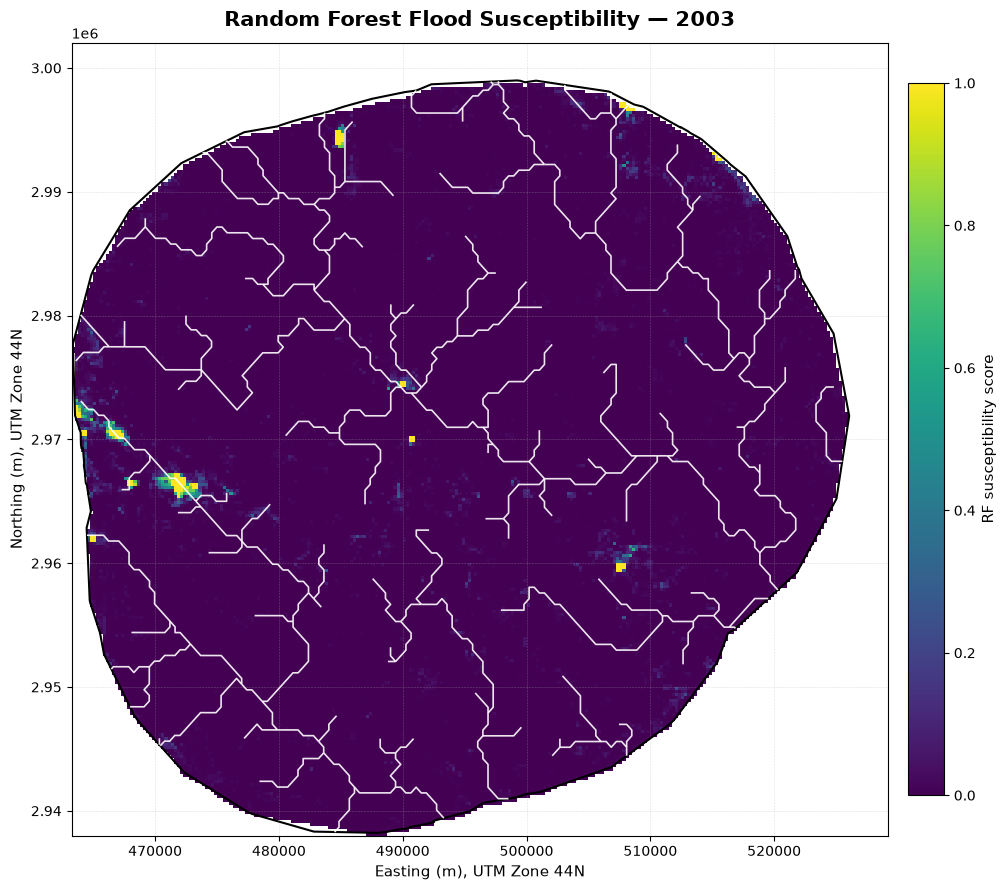

Saved: D:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\susceptibility_figures\RF_Susceptibility_Map_2003.png

CREATING MAP — 2025


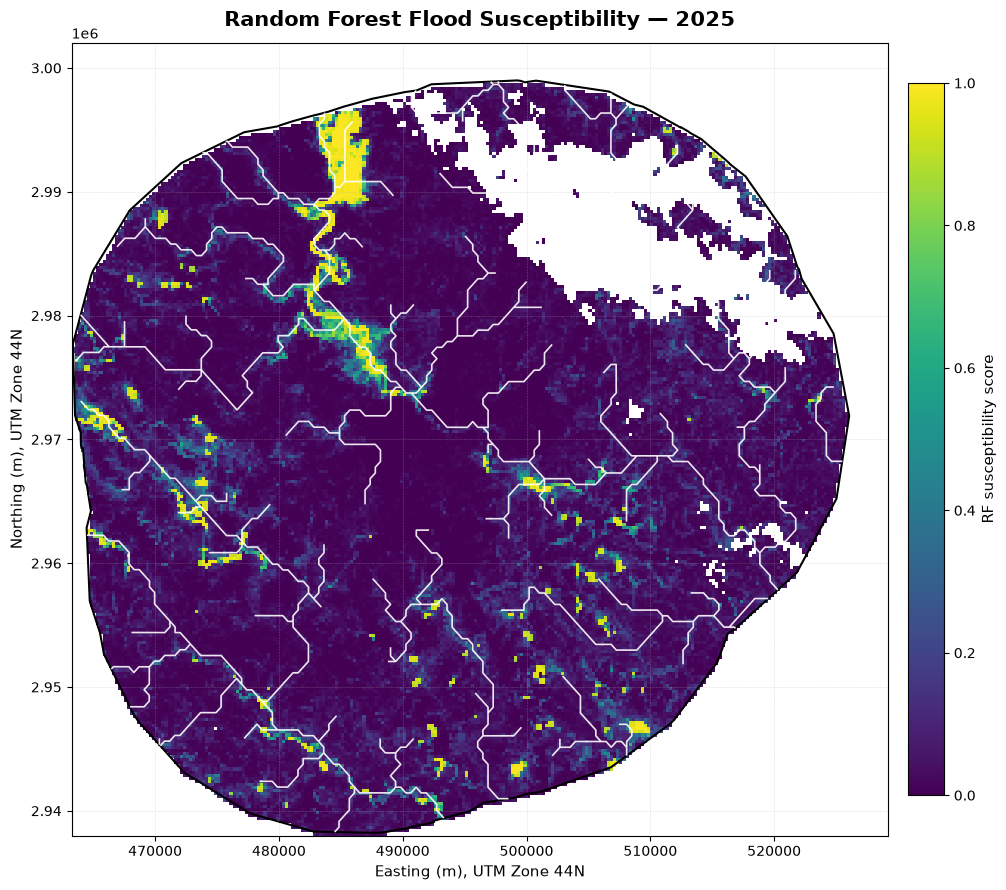

Saved: D:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\susceptibility_figures\RF_Susceptibility_Map_2025.png

RF SUSCEPTIBILITY MAPS SAVED


In [134]:
# ============================================================================
# 08.10.8 — VISUALIZE AND SAVE RF SUSCEPTIBILITY MAPS
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os

print("=" * 75)
print("08.10.8 — RF SUSCEPTIBILITY MAP VISUALIZATION")
print("=" * 75)


# ----------------------------------------------------------------------------
# 1. Verify required spatial objects
# ----------------------------------------------------------------------------

print("\nSpatial objects:")
print("-" * 60)

print("study_area_map:", study_area_map.shape)
print("river_08_7_2 :", river_08_7_2.shape)

print("\nCRS:")
print("Study area:", study_area_map.crs)
print("River     :", river_08_7_2.crs)


# ----------------------------------------------------------------------------
# 2. Create a common normalization
#
# IMPORTANT:
# We use the same 0–1 scale for both years so that the colors have
# the same numerical meaning in the two maps.
# ----------------------------------------------------------------------------

norm = mcolors.Normalize(
    vmin=0,
    vmax=1
)


# ----------------------------------------------------------------------------
# 3. Generate map for each year
# ----------------------------------------------------------------------------

for year in [2003, 2025]:

    print("\n" + "=" * 75)
    print(f"CREATING MAP — {year}")
    print("=" * 75)

    raster = susceptibility_rasters[year]

    # ------------------------------------------------------------------------
    # Mask NoData cells
    # ------------------------------------------------------------------------

    raster_masked = np.ma.masked_invalid(
        raster
    )

    # ------------------------------------------------------------------------
    # Calculate geographic extent from the raster transform
    # ------------------------------------------------------------------------

    left = transform.c
    top = transform.f

    right = (
        left
        + GRID_WIDTH * CELL_SIZE
    )

    bottom = (
        top
        - GRID_HEIGHT * CELL_SIZE
    )

    extent = [
        left,
        right,
        bottom,
        top
    ]

    # ------------------------------------------------------------------------
    # Create figure
    # ------------------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    # ------------------------------------------------------------------------
    # Plot susceptibility raster
    # ------------------------------------------------------------------------

    image = ax.imshow(
        raster_masked,
        extent=extent,
        origin="upper",
        cmap="viridis",
        norm=norm,
        interpolation="nearest"
    )

    # ------------------------------------------------------------------------
    # Overlay study-area boundary
    # ------------------------------------------------------------------------

    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.5,
        edgecolor="black"
    )

    # ------------------------------------------------------------------------
    # Overlay Gomti River
    # ------------------------------------------------------------------------

    river_08_7_2.plot(
        ax=ax,
        linewidth=1.2,
        color="white",
        alpha=0.9
    )

    # ------------------------------------------------------------------------
    # Colorbar
    # ------------------------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    cbar.set_label(
        "RF susceptibility score",
        fontsize=11
    )

    # ------------------------------------------------------------------------
    # Title
    # ------------------------------------------------------------------------

    ax.set_title(
        f"Random Forest Flood Susceptibility — {year}",
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    # ------------------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------------------

    ax.set_xlabel(
        "Easting (m), UTM Zone 44N",
        fontsize=11
    )

    ax.set_ylabel(
        "Northing (m), UTM Zone 44N",
        fontsize=11
    )

    # ------------------------------------------------------------------------
    # Grid
    # ------------------------------------------------------------------------

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.4,
        alpha=0.4
    )

    # ------------------------------------------------------------------------
    # Equal aspect ratio
    # ------------------------------------------------------------------------

    ax.set_aspect(
        "equal"
    )

    # ------------------------------------------------------------------------
    # Tight layout
    # ------------------------------------------------------------------------

    plt.tight_layout()

    # ------------------------------------------------------------------------
    # Save high-resolution figure
    # ------------------------------------------------------------------------

    figure_path = os.path.join(
        FIGURE_OUTPUT_DIR,
        f"RF_Susceptibility_Map_{year}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

    print(
        f"Saved: {os.path.abspath(figure_path)}"
    )


print("\n" + "=" * 75)
print("RF SUSCEPTIBILITY MAPS SAVED")
print("=" * 75)

C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_13468\2283490517.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


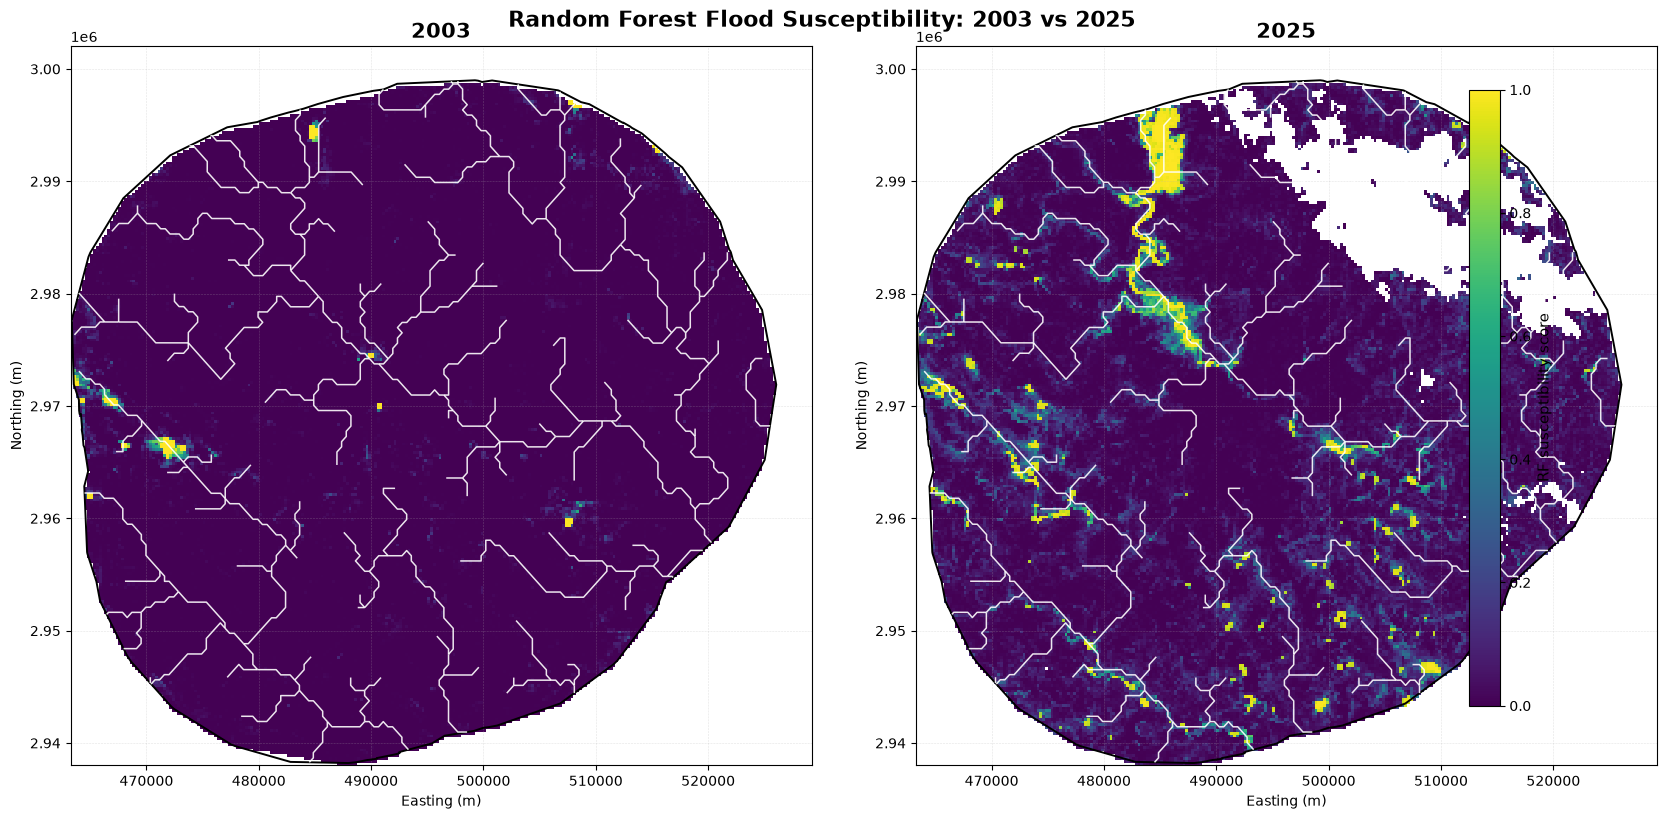

Saved comparison map: D:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_08\susceptibility_figures\RF_Susceptibility_2003_vs_2025.png


In [135]:
# ============================================================================
# 08.10.8 — SIDE-BY-SIDE 2003 vs 2025 RF SUSCEPTIBILITY
# ============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 8)
)

for ax, year in zip(
    axes,
    [2003, 2025]
):

    raster = np.ma.masked_invalid(
        susceptibility_rasters[year]
    )

    image = ax.imshow(
        raster,
        extent=extent,
        origin="upper",
        cmap="viridis",
        norm=norm,
        interpolation="nearest"
    )

    # Study boundary
    study_area_map.boundary.plot(
        ax=ax,
        linewidth=1.4,
        edgecolor="black"
    )

    # Gomti River
    river_08_7_2.plot(
        ax=ax,
        linewidth=1.1,
        color="white",
        alpha=0.9
    )

    ax.set_title(
        str(year),
        fontsize=15,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.4,
        alpha=0.35
    )

    ax.set_aspect("equal")


# ----------------------------------------------------------------------------
# Common colorbar
# ----------------------------------------------------------------------------

cbar = fig.colorbar(
    image,
    ax=axes,
    fraction=0.025,
    pad=0.02
)

cbar.set_label(
    "RF susceptibility score",
    fontsize=11
)


fig.suptitle(
    "Random Forest Flood Susceptibility: 2003 vs 2025",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()


comparison_path = os.path.join(
    FIGURE_OUTPUT_DIR,
    "RF_Susceptibility_2003_vs_2025.png"
)

fig.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

print(
    f"Saved comparison map: "
    f"{os.path.abspath(comparison_path)}"
)

## 08.10.9 Final Model Comparison and Selection

Random Forest (RF) and XGBoost (XGB) were evaluated using the same withheld northwest (NW) spatial test region for both modelling years. The spatial test region was not used during model training, hyperparameter tuning, or threshold selection.

Because the flood classes are highly imbalanced, Precision-Recall Area Under the Curve (PR-AUC) was defined as the primary model-selection metric. ROC-AUC was used as a secondary ranking metric, while threshold-dependent metrics were treated as supplementary diagnostics.

| Year | Model | PR-AUC | ROC-AUC | Precision | Recall | F1-score | Accuracy |
|------|-------|--------:|--------:|----------:|-------:|---------:|---------:|
| 2003 | Random Forest | 0.0131 | 0.6466 | 0.0000 | 0.0000 | 0.0000 | 0.9961 |
| 2003 | XGBoost | 0.0064 | 0.5224 | 0.0769 | 0.0465 | 0.0580 | 0.9955 |
| 2025 | Random Forest | 0.1429 | 0.7968 | 0.0956 | 0.0217 | 0.0354 | 0.9497 |
| 2025 | XGBoost | 0.0926 | 0.6396 | 0.1875 | 0.3456 | 0.2431 | 0.9086 |

Random Forest achieved higher PR-AUC and ROC-AUC than XGBoost for both 2003 and 2025 on the same withheld spatial test region. Since the objective of the susceptibility model is to provide a continuous spatial ranking of flood susceptibility rather than to optimize a single binary classification threshold, the ranking-based metrics were given priority.

Therefore, Random Forest was selected as the primary flood susceptibility model for subsequent susceptibility mapping. XGBoost was retained as a secondary comparative model.

The final Random Forest configurations selected through spatial cross-validation were:

- **2003:** 400 trees, maximum depth = 20, minimum samples per leaf = 5, and `max_features = sqrt`.
- **2025:** 600 trees, unlimited maximum depth, minimum samples per leaf = 5, and `max_features = sqrt`.

Class weighting was used to address the severe imbalance between flood and non-flood observations. No oversampling or undersampling was applied to the spatial test data.

The final mapping Random Forest models were subsequently retrained using all available labelled modelling cells for their respective years. Continuous Random Forest susceptibility scores were generated for the available modelling grid and exported as GeoTIFF rasters.

The susceptibility scores represent continuous model-derived susceptibility values and should not be interpreted as calibrated flood probabilities.

In [137]:
# ============================================================================
# 08.10.10 — FINAL MODEL AND OUTPUT SUMMARY
# ============================================================================

import os

print("=" * 80)
print("FINAL FLOOD SUSCEPTIBILITY MODEL — OUTPUT SUMMARY")
print("=" * 80)


# ----------------------------------------------------------------------------
# 1. Final selected model
# ----------------------------------------------------------------------------

print("\nPRIMARY MODEL")
print("-" * 60)

print("Model      : Random Forest")
print("Role       : Primary flood susceptibility model")
print("Secondary  : XGBoost")


# ----------------------------------------------------------------------------
# 2. Final RF configurations
# ----------------------------------------------------------------------------

print("\nFINAL RF CONFIGURATIONS")
print("-" * 60)

for year in [2003, 2025]:

    print(f"\n{year}")

    for key, value in RF_MAPPING_PARAMS[year].items():
        print(f"{key:<22}: {value}")


# ----------------------------------------------------------------------------
# 3. Final mapping dataset sizes
# ----------------------------------------------------------------------------

print("\nFINAL MAPPING DATA")
print("-" * 60)

for year in [2003, 2025]:

    df = rf_mapping_data[year]

    flood_count = int(
        (df["Flood"] == 1).sum()
    )

    non_flood_count = int(
        (df["Flood"] == 0).sum()
    )

    print(
        f"{year}: "
        f"{len(df):,} total | "
        f"{flood_count:,} flood | "
        f"{non_flood_count:,} non-flood"
    )


# ----------------------------------------------------------------------------
# 4. Output files
# ----------------------------------------------------------------------------

MODEL_OUTPUT_DIR = PROJECT_ROOT / "models"

RF_MODEL_PATHS = {
    2003: MODEL_OUTPUT_DIR / "rf_final_mapping_2003.joblib",
    2025: MODEL_OUTPUT_DIR / "rf_final_mapping_2025.joblib",
}

METADATA_PATH = MODEL_OUTPUT_DIR / "model_metadata.json"

for year in [2003, 2025]:

    print(
        f"\nRF {year} model file:"
    )
    print(
        f"  {os.path.abspath(RF_MODEL_PATHS[year])}"
    )


# ----------------------------------------------------------------------------
# 5. Final score diagnostics
# ----------------------------------------------------------------------------

print("\nSUSCEPTIBILITY SCORE SUMMARY")
print("-" * 60)

for year in [2003, 2025]:

    scores = rf_mapping_data[
        year
    ]["RF_Susceptibility"].to_numpy()

    print(
        f"{year}: "
        f"min={scores.min():.6f}, "
        f"max={scores.max():.6f}, "
        f"mean={scores.mean():.6f}, "
        f"median={np.median(scores):.6f}"
    )


print("\n" + "=" * 80)
print("NOTEBOOK 08 — FLOOD SUSCEPTIBILITY MODEL COMPLETE")
print("=" * 80)

FINAL FLOOD SUSCEPTIBILITY MODEL — OUTPUT SUMMARY

PRIMARY MODEL
------------------------------------------------------------
Model      : Random Forest
Role       : Primary flood susceptibility model
Secondary  : XGBoost

FINAL RF CONFIGURATIONS
------------------------------------------------------------

2003
n_estimators          : 400
max_depth             : 20
min_samples_split     : 2
min_samples_leaf      : 5
max_features          : sqrt

2025
n_estimators          : 600
max_depth             : None
min_samples_split     : 2
min_samples_leaf      : 5
max_features          : sqrt

FINAL MAPPING DATA
------------------------------------------------------------
2003: 47,523 total | 99 flood | 47,424 non-flood
2025: 43,076 total | 1,018 flood | 42,058 non-flood

RF 2003 model file:
  D:\Projects\GeoAI-Flood-Susceptibility\models\rf_final_mapping_2003.joblib

RF 2025 model file:
  D:\Projects\GeoAI-Flood-Susceptibility\models\rf_final_mapping_2025.joblib

SUSCEPTIBILITY SCORE SUMMAR

# 08. Notebook Summary — Flood Susceptibility Modelling

## Overview

This notebook developed and finalized the supervised flood susceptibility modelling framework for the Lucknow–Gomti River study area using spatially structured training and testing data for the **2003** and **2025** flood-reference years.

The modelling framework used nine predictor variables:

- Elevation
- Slope
- Flow Accumulation
- River Distance
- Drainage Density
- Clay
- Sand
- Rainfall
- LULC

The 2014 flood reference was assessed but excluded from supervised modelling because a sufficiently defensible flood reference could not be established for that year.

## Spatial Modelling Design

To reduce the risk of spatial leakage between training and evaluation data, a **5 km spatial block-based train–test design** was adopted.

The **NW spatial region** was reserved as the withheld test region for both modelling years. The remaining spatial blocks were used for model training.

Spatial cross-validation was performed using **3 spatial folds**, selected because the 2003 flood reference contained a relatively small number of positive spatial blocks. The spatial folds preserved block membership and were constructed to maintain a more balanced distribution of flood cells across folds.

No test-set resampling was applied. Class imbalance was addressed during model training through class weighting for Random Forest and the corresponding positive-class weighting strategy for XGBoost.

## Predictor Quality Assessment

Exploratory analysis identified a strong relationship between the soil predictors **Clay** and **Sand** (Pearson correlation ≈ 0.894), with VIF values of approximately 7 for both variables.

Both predictors were retained because they have physical relevance to flood susceptibility and the final models are tree-based methods. Their individual feature importance values are therefore interpreted cautiously rather than as independent causal effects.

## Models Evaluated

Two tree-based machine-learning approaches were evaluated:

1. **Random Forest (RF)**
2. **XGBoost (XGB)**

Both models were first evaluated using baseline configurations and subsequently tuned using spatial cross-validation.

Hyperparameter selection primarily considered **PR-AUC**, with ROC-AUC used as a secondary ranking metric. PR-AUC was emphasized because the flood classes are strongly imbalanced, particularly for the 2003 dataset.

## Final Model Selection

Random Forest was selected as the **primary flood susceptibility model**.

The final comparison on the withheld NW test region showed that Random Forest provided stronger ranking performance than XGBoost for both modelling years:

| Year | Model | PR-AUC | ROC-AUC |
|------|-------|--------|---------|
| 2003 | Random Forest | 0.0131 | 0.6466 |
| 2003 | XGBoost | 0.0064 | 0.5224 |
| 2025 | Random Forest | 0.1429 | 0.7968 |
| 2025 | XGBoost | 0.0926 | 0.6396 |

Although XGBoost produced different threshold-based precision, recall, and F1 behaviour, model selection was based primarily on the continuous susceptibility ranking performance rather than a fixed probability threshold of 0.5.

Therefore, **Random Forest was retained as the final susceptibility-mapping model**, while XGBoost was retained as the secondary comparison model.

## Final Random Forest Configurations

### 2003

- `n_estimators = 400`
- `max_depth = 20`
- `min_samples_split = 2`
- `min_samples_leaf = 5`
- `max_features = "sqrt"`
- `class_weight = "balanced"`

### 2025

- `n_estimators = 600`
- `max_depth = None`
- `min_samples_split = 2`
- `min_samples_leaf = 5`
- `max_features = "sqrt"`
- `class_weight = "balanced"`

## Final Mapping Datasets

The final Random Forest mapping models were trained using all available labelled modelling cells for their respective years:

- **2003:** 47,523 cells  
  - 99 flood cells
  - 47,424 non-flood cells

- **2025:** 43,076 cells  
  - 1,018 flood cells
  - 42,058 non-flood cells

The resulting models were saved as:

- `models/rf_final_mapping_2003.joblib`
- `models/rf_final_mapping_2025.joblib`

## Final Susceptibility Outputs

The final Random Forest models generated continuous susceptibility scores for the study area.

### 2003

- Minimum: 0.000000
- Maximum: 0.999513
- Mean: 0.006963
- Median: 0.000000

### 2025

- Minimum: 0.000000
- Maximum: 0.999718
- Mean: 0.078679
- Median: 0.024074

These values represent **continuous model-derived flood susceptibility scores**. They are not interpreted as calibrated real-world flood probabilities.

The final susceptibility rasters were generated for both years, together with individual susceptibility maps and a 2003–2025 comparison map.

## Notebook Outputs

The principal outputs produced by this notebook are:

- Final Random Forest model for 2003
- Final Random Forest model for 2025
- 2003 continuous flood susceptibility raster
- 2025 continuous flood susceptibility raster
- 2003 susceptibility map
- 2025 susceptibility map
- 2003–2025 susceptibility comparison map

## Conclusion

Notebook 08 establishes the final supervised flood susceptibility modelling framework and produces the continuous susceptibility surfaces for **2003 and 2025**.

The **Random Forest model is selected as the primary model** because it demonstrated stronger PR-AUC and ROC-AUC ranking performance than XGBoost on the same withheld spatial test region for both years.

The resulting susceptibility rasters and maps are therefore carried forward to **Notebook 09 for spatial validation** and subsequently to **Notebook 10 for temporal and spatial interpretation of flood susceptibility changes**.

**Notebook 08 — Flood Susceptibility Modelling: COMPLETE**